# Proyecto: Valorización energética de biomasa de palma - Magdalena
## Modelo Python/Pyomo basado en Capítulo 5 de tesis doctoral

> **Notebook reorganizado** — se eliminaron celdas de intentos intermedios/superados que existían en la versión anterior, para dejar solo la version final y correcta de cada bloque. Ver resumen de cambios que Claude explicó en el chat.

## 0. Imports generales
**Ejecutar siempre esta celda primero después de reiniciar el kernel.**

In [67]:
import pandas as pd
import numpy as np
from iapws import IAPWS97
import pyomo.environ as pyo


## 1. Limpieza — Datos_Base
Parámetros de línea base por planta, organizados por etapa de proceso. Incluye corrección de espacios invisibles (`\xa0`) que causaban valores tipo texto en Presión/Temperatura de vapor.

In [68]:
# ==========================================================
# Limpieza completa de Datos_Base (con corrección de texto/nbsp)
# ==========================================================
raw = pd.read_excel('Escenarios.xlsx', sheet_name='Datos_Base', header=None, usecols='A:H')
plantas = raw.iloc[1, 2:8].tolist()

df_datos = raw.iloc[2:].copy()
df_datos.columns = ['Parametro', 'Unidad'] + plantas
df_datos = df_datos.reset_index(drop=True)

# Identificar encabezados de etapa (sin unidad y sin ningún valor en las 6 plantas)
is_header = df_datos['Parametro'].notna() & df_datos['Unidad'].isna() & df_datos[plantas].isna().all(axis=1)
df_datos['Etapa'] = df_datos['Parametro'].where(is_header).ffill()
df_datos = df_datos[~is_header].reset_index(drop=True)

# Rellenar nombre de parámetro para las filas "huérfanas" (valor específico por tRFF)
df_datos['Parametro'] = df_datos['Parametro'].ffill()
dup_mask = df_datos.duplicated(subset=['Etapa', 'Parametro'], keep='first')
df_datos.loc[dup_mask, 'Parametro'] = df_datos.loc[dup_mask, 'Parametro'] + ' (específico por tRFF)'
df_datos.loc[dup_mask, 'Unidad'] = df_datos.loc[dup_mask, 'Unidad'].fillna('por tRFF procesado')

# Formato tidy
df_tidy = df_datos.melt(id_vars=['Parametro', 'Unidad', 'Etapa'], var_name='Planta', value_name='Valor')
df_tidy['Etapa'] = df_tidy['Etapa'].fillna('General')

# --- CORRECCIÓN: limpiar espacios invisibles (\xa0) y forzar tipo numérico ---
df_tidy['Valor'] = df_tidy['Valor'].apply(lambda v: str(v).replace('\xa0', '').strip() if isinstance(v, str) else v)
df_tidy['Valor'] = pd.to_numeric(df_tidy['Valor'], errors='coerce')

# Separar filas con dato realmente faltante (para no perderlas silenciosamente)
faltantes = df_tidy[df_tidy['Valor'].isna() & (df_tidy['Etapa'] != 'General')]
df_tidy = df_tidy.dropna(subset=['Valor']).reset_index(drop=True)

print("Filas con dato faltante en el Excel original:")
print(faltantes[['Parametro', 'Unidad', 'Etapa']].drop_duplicates())

# Corregir unidad de "Humedad de secado" (error de tecleo en el Excel original: °C -> %)
df_tidy.loc[df_tidy['Parametro'] == 'Humedad de secado', 'Unidad'] = '%'

# Agregar de vuelta "Flujo de aire de secado" como dato pendiente explícito (NaN documentado)
fila_pendiente = pd.DataFrame({
    'Parametro': ['Flujo de aire de secado'] * len(plantas),
    'Unidad': ['kgaire seco∙h-1'] * len(plantas),
    'Etapa': ['Secado de nueces'] * len(plantas),
    'Planta': plantas,
    'Valor': [np.nan] * len(plantas)
})

# Separar eficiencias reportadas (no se usan como dato de entrada - se recalculan desde cero)
es_eficiencia = df_tidy['Parametro'].str.contains('Eficiencia', case=False, na=False)
df_datos_base = df_tidy[~es_eficiencia].reset_index(drop=True)
df_datos_base = pd.concat([df_datos_base, fila_pendiente], ignore_index=True)

print("\ndf_datos_base listo:", df_datos_base.shape)

# Verificación específica: Presión/Temperatura/Flujo de vapor de Planta A (deben ser números)
verificacion = df_datos_base[
    (df_datos_base['Parametro'].isin(['Presión de vapor', 'Temperatura de vapor',
                                        'Temperatura agua de alimentación', 'Flujo de vapor'])) &
    (df_datos_base['Planta'] == 'Planta A')
]
print("\nVerificación Planta A:")
print(verificacion)


Filas con dato faltante en el Excel original:
                                            Parametro              Unidad  \
15       Eficiencia energpetica (específico por tRFF)  por tRFF procesado   
41                            Flujo de aire de secado     kgaire seco∙h-1   
55  Temperatura agua de alimentación (específico p...  por tRFF procesado   
76                                        Humedad MPD                   %   

               Etapa  
15    Esterilización  
41  Secado de nueces  
55           Caldera  
76        Desfrutado  

df_datos_base listo: (313, 5)

Verificación Planta A:
                           Parametro       Unidad    Etapa    Planta    Valor
48                    Flujo de vapor  kgvapor∙h-1  Caldera  Planta A  71984.0
49                  Presión de vapor          bar  Caldera  Planta A      3.0
50              Temperatura de vapor           °C  Caldera  Planta A    300.0
51  Temperatura agua de alimentación           °C  Caldera  Planta A     90.0


In [69]:
df_datos_base.to_csv('datos_base_limpio.csv', index=False)

## 2. Limpieza — Biomass
Propiedades fisicoquímicas, capacidad calorífica, correlación HHV ("Present study", sin término de Ash) y validación cruzada.

In [70]:
# ==========================================================
# PASO 1: Limpiar la tabla de propiedades (filas 5-15)
# ==========================================================
raw = pd.read_excel('Escenarios.xlsx', sheet_name='Biomass', header=None)

materiales = raw.iloc[4, 2:12:2].tolist()
propiedades = raw.iloc[7:15, 0].tolist()
unidades = raw.iloc[7:15, 1].ffill().tolist()

registros = []
for i, mat in enumerate(materiales):
    col_avg = 2 + i*2
    col_std = 3 + i*2
    for j, fila_excel in enumerate(range(7, 15)):
        registros.append({
            'Material': mat,
            'Propiedad': propiedades[j],
            'Unidad': unidades[j],
            'Promedio': raw.iloc[fila_excel, col_avg],
            'Desviacion_std': raw.iloc[fila_excel, col_std]
        })

df_biomasa = pd.DataFrame(registros)
print("df_biomasa listo:", df_biomasa.shape)

# ==========================================================
# PASO 2: Tabla de capacidad calorífica (de la imagen)
# ==========================================================
df_calor_especifico = pd.DataFrame({
    'Material': ['Water', 'Nut shell', 'Kernel', 'Palm oil', 'Fiber', 'EFB', 'Mud, etc.'],
    'Peso_pct': [15, 6.8, 5.2, 23.5, 14.0, 22.0, 12],
    'Cp_kJ_kgK': [4.18, 1.88, 1.59, 1.46, 1.80, 1.67, 2.22]
})

# ==========================================================
# PASO 3: Función de correlación HHV "Present study" (Eq. 7)
# ==========================================================
def hhv_present_study(C, H, O, N, S):
    """C, H, O, N, S en % base seca (dry basis). Retorna HHV en MJ/kg."""
    return 0.3443*C + 1.192*H - 0.113*O - 0.024*N + 0.093*S

# ==========================================================
# PASO 4: Validación cruzada (usa df_biomasa del Paso 1)
# ==========================================================
df_wide = df_biomasa.pivot_table(index='Material', columns='Propiedad', values='Promedio').reset_index()

df_wide['HHV_calculado_MJkg'] = df_wide.apply(
    lambda row: hhv_present_study(row['C']*100, row['H']*100, row['O']*100, row['N']*100, row['S']*100),
    axis=1
)
df_wide['HHV_reportado_MJkg'] = df_wide['HHV'] / 1000

df_wide[['Material', 'HHV_calculado_MJkg', 'HHV_reportado_MJkg']]

# ==========================================================
# PASO 5: Corrección del LHV (error de unidades detectado en el Excel original)
# El LHV reportado resta el calor latente de vaporización con un factor
# ~1000x menor al valor físico (2.44 en vez de 2,440 kJ/kg) — el error crece
# con la humedad. Se recalcula con la fórmula estándar de ingeniería de biomasa:
#   LHV_húmedo = HHV_seco·(1-w) − L·[w + 9·H_seco·(1-w)]
# ==========================================================
L_VAPORIZACION_AGUA = 2440  # kJ/kg, calor latente de vaporización del agua (25°C, valor estándar)

def lhv_corregido_kJkg(material):
    fila = df_wide[df_wide['Material'] == material].iloc[0]
    hhv_seco = fila['HHV']
    H_seco = fila['H']
    w = fila['Moisture']
    return hhv_seco * (1 - w) - L_VAPORIZACION_AGUA * (w + 9 * H_seco * (1 - w))

print("Comparación LHV original (Excel) vs. corregido:")
for material in df_biomasa['Material'].unique():
    original = df_biomasa[(df_biomasa['Material'] == material) & (df_biomasa['Propiedad'] == 'LHV')]['Promedio'].iloc[0]
    corregido = lhv_corregido_kJkg(material)
    print(f"{material}: original={original:,.1f} kJ/kg | corregido={corregido:,.1f} kJ/kg | diferencia={100*(original-corregido)/corregido:.1f}%")
    df_biomasa.loc[(df_biomasa['Material'] == material) & (df_biomasa['Propiedad'] == 'LHV'), 'Promedio'] = corregido

df_biomasa listo: (40, 5)
Comparación LHV original (Excel) vs. corregido:
EFB: original=6,425.1 kJ/kg | corregido=4,373.9 kJ/kg | diferencia=46.9%
Fiber: original=12,496.6 kJ/kg | corregido=10,772.2 kJ/kg | diferencia=16.0%
PKS: original=16,240.6 kJ/kg | corregido=14,821.4 kJ/kg | diferencia=9.6%
Pressed EFB: original=9,179.8 kJ/kg | corregido=7,294.1 kJ/kg | diferencia=25.9%
Dry EFB: original=16,525.6 kJ/kg | corregido=15,081.4 kJ/kg | diferencia=9.6%


In [71]:
df_biomasa.to_csv('biomasa_propiedades.csv', index=False)
df_calor_especifico.to_csv('biomasa_calor_especifico.csv', index=False)

## 3. Limpieza — CAPEX
Costos por área, curva de cogeneración (Malico et al. 2019), ajuste CEPCI a 2026, escalamiento de pretratamiento térmico (regla 6/10).

*(Usa `df_datos_base` de la Sección 1 — asegúrate de haber corrido esa celda primero.)*

In [72]:
# ==========================================================
# PASO 1: Limpiar el resumen por área (CAPEX, filas 14-38 = índices 13-37)
# ==========================================================
raw_capex = pd.read_excel('Escenarios.xlsx', sheet_name='CAPEX', header=None)

registros_capex = []
for r in range(13, 38):
    area = raw_capex.iloc[r, 6]         # columna G
    total = raw_capex.iloc[r, 9]        # columna J
    especifico = raw_capex.iloc[r, 10]  # columna K
    unidad = raw_capex.iloc[r, 11]      # columna L
    if pd.notna(area):
        registros_capex.append({
            'Area': area,
            'Total_USD_ref': pd.to_numeric(total, errors='coerce'),
            'Valor_especifico': pd.to_numeric(especifico, errors='coerce'),
            'Unidad_especifico': unidad
        })

df_capex = pd.DataFrame(registros_capex)
print("df_capex:")
print(df_capex)

# ==========================================================
# PASO 2: Ajuste de todos los valores a USD 2026 (CEPCI)
# ==========================================================
CEPCI_2019 = 607.5
CEPCI_2021 = 708.8
CEPCI_2026 = 873.8  # estimado, ver nota metodológica

factor_cepci_2019 = CEPCI_2026 / CEPCI_2019
factor_cepci_2021 = CEPCI_2026 / CEPCI_2021

df_capex['Total_USD_2026'] = df_capex['Total_USD_ref'] * factor_cepci_2019
df_capex['Valor_especifico_2026'] = df_capex['Valor_especifico'] * factor_cepci_2019

print(df_capex[['Area', 'Total_USD_2026', 'Valor_especifico_2026']])

# ==========================================================
# PASO 3: Curva de costo de cogeneración (Malico et al., 2019)
# ==========================================================
def capex_cogeneracion_usd_kw(capacidad_kw):
    """CAPEX específico (USD/kW) según capacidad instalada. Fuente: Malico et al. (2019). Retorna en USD 2026."""
    valor_2019 = -900.6 * np.log(capacidad_kw) + 10841
    return valor_2019 * factor_cepci_2019

print("\nEjemplo curva cogeneración (1500 kW):", capex_cogeneracion_usd_kw(1500))

# ==========================================================
# PASO 4: Escalamiento de Pretratamiento térmico (regla de los 6/10)
# ==========================================================
COSTO_REF_2021 = 1_400_000
COSTO_REF_2026 = COSTO_REF_2021 * factor_cepci_2021
CAPACIDAD_REF = 150_000
n = 0.6

def costo_pretratamiento_termico(capacidad_planta_t_ano):
    return COSTO_REF_2026 * (capacidad_planta_t_ano / CAPACIDAD_REF) ** n

print(f"\nCosto de referencia ajustado a 2026: ${COSTO_REF_2026:,.0f} USD")

fruto_procesado = df_datos_base[df_datos_base['Parametro'] == 'Fruto procesado'].set_index('Planta')['Valor']
for planta, tRFF_ano in fruto_procesado.items():
    costo = costo_pretratamiento_termico(tRFF_ano)
    print(f"{planta}: {tRFF_ano:,.0f} tRFF/año -> ${costo:,.0f} USD (2026)")


df_capex:
                                         Area  Total_USD_ref  \
0                                   Recepción   1.827019e+05   
1                 Esterilización convencional   5.842191e+05   
2                     Esterilización continua   5.760070e+05   
3                          Prensado de raquis   1.117692e+05   
4                                 Desfrutado    1.332761e+05   
5           Extracción (digestión y prensado)   2.583898e+05   
6                      Clarificación dinamica   3.505156e+05   
7                      Clarificación estatica   2.804464e+05   
8                              Almacenamiento   2.014153e+05   
9                                 Palmisteria   5.534873e+05   
10                      Caldera media presión   1.141062e+06   
11                      Turbina Contrapresiòn   2.814681e+03   
12                    Redes e infraestructura   1.072970e+05   
13            Turbina Extracción condensación            NaN   
14                Sistema gase

In [73]:
df_capex.to_csv('capex_limpio_2026.csv', index=False)

## 4. Limpieza — EmisionesCO2
Factores de emisión IPCC (Gómez et al., 2017), factor de red nacional, crédito de absorción de palma. Reconstruido desde cero (la hoja original tenía un error de factor CH4).

In [74]:
# ==========================================================
# Tabla de factores de emisión (Gómez et al., 2017 - valores IPCC por defecto)
# ==========================================================
df_factores_emision = pd.DataFrame({
    'Gas': ['CH4', 'CH4', 'N2O', 'N2O'],
    'Fuente': ['Biomasa sólida', 'Biogás', 'Biomasa sólida', 'Biogás'],
    'Factor_kg_TJ': [30, 1, 4, 0.1],
    'GWP100_kgCO2eq_kg': [21, 21, 310, 310]
})

FACTOR_CO2_DIESEL = 74100        # kg CO2/TJ (IPCC 2006, validado contra hoja original)
FACTOR_RED_NACIONAL = 0.1634     # kg CO2/kWh (163.4 gCO2/kWh - valor usado en publicación previa)
FACTOR_ABSORCION_PALMA = -135.04 # kg CO2/tRFF (crédito por absorción, cultivo de palma)

def emisiones_no_co2_biomasa(energia_TJ, fuente='Biomasa sólida'):
    """Emisiones de CH4 y N2O (no-CO2), en kg CO2-eq. El CO2 biogénico no se contabiliza (convención IPCC)."""
    fila_ch4 = df_factores_emision[(df_factores_emision['Gas']=='CH4') & (df_factores_emision['Fuente']==fuente)].iloc[0]
    fila_n2o = df_factores_emision[(df_factores_emision['Gas']=='N2O') & (df_factores_emision['Fuente']==fuente)].iloc[0]
    ch4_eq = energia_TJ * fila_ch4['Factor_kg_TJ'] * fila_ch4['GWP100_kgCO2eq_kg']
    n2o_eq = energia_TJ * fila_n2o['Factor_kg_TJ'] * fila_n2o['GWP100_kgCO2eq_kg']
    return ch4_eq + n2o_eq

def emisiones_diesel(energia_TJ):
    return energia_TJ * FACTOR_CO2_DIESEL

def emisiones_red_nacional(electricidad_kWh):
    return electricidad_kWh * FACTOR_RED_NACIONAL

def balance_neto_GEI(emisiones_proceso_kgCO2eq, tRFF_procesado):
    credito_absorcion = FACTOR_ABSORCION_PALMA * tRFF_procesado
    return emisiones_proceso_kgCO2eq + credito_absorcion

def excedente_electrico(electricidad_generada_kWh, electricidad_consumida_kWh):
    return electricidad_generada_kWh - electricidad_consumida_kWh

# Validación contra Bloque 1 (línea base) - Planta A
tj_diesel_plantaA = 0.46090413989315915
tRFF_plantaA = 153157
print("Emisiones diésel Planta A:", emisiones_diesel(tj_diesel_plantaA), "≈ 34,152.99 (valor original de la hoja)")
print("Crédito absorción Planta A:", FACTOR_ABSORCION_PALMA * tRFF_plantaA, "kg CO2")


Emisiones diésel Planta A: 34152.996766083095 ≈ 34,152.99 (valor original de la hoja)
Crédito absorción Planta A: -20682321.279999997 kg CO2


In [75]:
df_factores_emision.to_csv('factores_emision.csv', index=False)

## 5. Módulo social (Hoja2)
Indicador de viviendas/personas rurales beneficiadas por excedente eléctrico. Personas por hogar: DANE CNPV 2018 (Magdalena).

In [76]:
# ==========================================================
# Datos de demanda residencial departamental (Magdalena, 2025)
# ==========================================================
DEMANDA_RESIDENCIAL_RURAL_GWh = 30.3
DEMANDA_RESIDENCIAL_URBANA_GWh = 1209
DEMANDA_INDUSTRIAL_COMERCIO_GWh = 1190.7
DEMANDA_TOTAL_DEPARTAMENTAL_GWh = 2430  # validado: suma de las 3 anteriores

USUARIOS_RURALES = 87516
USUARIOS_URBANOS = 231790
USUARIOS_TOTAL_DANE_CNPV2018 = 319306  # validado contra fuente DANE

PERSONAS_POR_HOGAR_MAGDALENA = 3.7  # DANE, CNPV 2018 (promedio departamental)

CONSUMO_PROMEDIO_VIVIENDA_RURAL_kWh = (DEMANDA_RESIDENCIAL_RURAL_GWh * 1_000_000) / USUARIOS_RURALES
CONSUMO_PROMEDIO_VIVIENDA_URBANA_kWh = (DEMANDA_RESIDENCIAL_URBANA_GWh * 1_000_000) / USUARIOS_URBANOS

def viviendas_rurales_beneficiadas(excedente_electrico_kWh_ano):
    return excedente_electrico_kWh_ano / CONSUMO_PROMEDIO_VIVIENDA_RURAL_kWh

def personas_rurales_beneficiadas(excedente_electrico_kWh_ano):
    return viviendas_rurales_beneficiadas(excedente_electrico_kWh_ano) * PERSONAS_POR_HOGAR_MAGDALENA

def porcentaje_cobertura_rural_departamental(excedente_electrico_kWh_ano):
    return (excedente_electrico_kWh_ano / (DEMANDA_RESIDENCIAL_RURAL_GWh * 1_000_000)) * 100

def construir_tabla_impacto_social(excedentes_dict, nombre_escenario):
    """excedentes_dict: {'Planta A': excedente_kWh_ano, ...}; nombre_escenario: 'Linea_Base', 'Escenario_1_Termico', 'Escenario_2_Biogas'"""
    registros = []
    for planta, excedente in excedentes_dict.items():
        registros.append({
            'Escenario': nombre_escenario,
            'Planta': planta,
            'Excedente_kWh_ano': excedente,
            'Viviendas_rurales_beneficiadas': viviendas_rurales_beneficiadas(excedente),
            'Personas_rurales_beneficiadas': personas_rurales_beneficiadas(excedente),
            'Pct_cobertura_rural_departamental': porcentaje_cobertura_rural_departamental(excedente)
        })
    return pd.DataFrame(registros)

print(f"Consumo promedio vivienda rural: {CONSUMO_PROMEDIO_VIVIENDA_RURAL_kWh:.1f} kWh/año")
print(f"Personas por hogar (Magdalena, DANE CNPV 2018): {PERSONAS_POR_HOGAR_MAGDALENA}")


Consumo promedio vivienda rural: 346.2 kWh/año
Personas por hogar (Magdalena, DANE CNPV 2018): 3.7


In [77]:
import json
datos_sociales = {
    'demanda_rural_GWh': DEMANDA_RESIDENCIAL_RURAL_GWh,
    'demanda_urbana_GWh': DEMANDA_RESIDENCIAL_URBANA_GWh,
    'usuarios_rurales': USUARIOS_RURALES,
    'usuarios_urbanos': USUARIOS_URBANOS,
    'personas_por_hogar': PERSONAS_POR_HOGAR_MAGDALENA
}
with open('datos_sociales.json', 'w') as f:
    json.dump(datos_sociales, f, indent=2)


## 6. Limpieza — Eficiencia
Esterilización continua (escalamiento para Escenarios 1 y 2) y demanda energética por etapa de proceso (línea base).

In [78]:
CONSUMO_ESPECIFICO_ESTERILIZACION_CONTINUA = 315  # kg vapor / tRFF procesado

def vapor_esterilizacion_continua(capacidad_planta_tRFF_h):
    """Vapor requerido para esterilización continua (kg/h), escalado por capacidad de planta."""
    return CONSUMO_ESPECIFICO_ESTERILIZACION_CONTINUA * capacidad_planta_tRFF_h

capacidades = {'Planta A': 30, 'Planta B': 40, 'Planta C': 30, 'Planta D': 24, 'Planta E': 30, 'Planta F': 20}
for planta, cap in capacidades.items():
    vapor = vapor_esterilizacion_continua(cap)
    print(f"{planta}: {vapor:,.0f} kg vapor/h (esterilización continua)")


Planta A: 9,450 kg vapor/h (esterilización continua)
Planta B: 12,600 kg vapor/h (esterilización continua)
Planta C: 9,450 kg vapor/h (esterilización continua)
Planta D: 7,560 kg vapor/h (esterilización continua)
Planta E: 9,450 kg vapor/h (esterilización continua)
Planta F: 6,300 kg vapor/h (esterilización continua)


In [79]:
raw_efi = pd.read_excel('Escenarios.xlsx', sheet_name='Eficiencia', header=None)

plantas = ['Planta A', 'Planta B', 'Planta C', 'Planta D', 'Planta E', 'Planta F']
col_inicio = 13  # cada planta ocupa 2 columnas (Eléctrica, Térmica), empieza en columna N

registros_demanda = []
for r in range(5, 23):  # filas 6-23 de Excel: 'Recepción' a 'Total'
    etapa = raw_efi.iloc[r, 12]  # columna M
    if pd.isna(etapa):
        continue
    for i, planta in enumerate(plantas):
        col_e = col_inicio + i*2
        col_t = col_inicio + i*2 + 1
        valor_e = raw_efi.iloc[r, col_e]
        valor_t = raw_efi.iloc[r, col_t]
        if pd.notna(valor_e):
            registros_demanda.append({'Etapa': etapa, 'Planta': planta, 'Tipo_energia': 'Electrica', 'Valor_kW': valor_e})
        if pd.notna(valor_t):
            registros_demanda.append({'Etapa': etapa, 'Planta': planta, 'Tipo_energia': 'Termica', 'Valor_kW': valor_t})

df_demanda_por_etapa = pd.DataFrame(registros_demanda)

resumen = df_demanda_por_etapa[df_demanda_por_etapa['Etapa'].isin(['Total', 'Eficiencia global planta extractora'])]
df_demanda_por_etapa = df_demanda_por_etapa[~df_demanda_por_etapa['Etapa'].isin(['Total', 'Eficiencia global planta extractora'])].reset_index(drop=True)

# ==========================================================
# CORRECCIÓN: la columna Electrica está en valores específicos 
# (kW por t/h de capacidad de planta), no en kW absolutos como sugiere 
# el header original del Excel "(kWe)". Verificado por sentido físico: 
# el total sin corregir da ~25 kW (implausible para una planta industrial), 
# y al multiplicar por capacidad da 600-900 kW, coincidiendo con el rango 
# real típico confirmado por el autor (600-800 kW). La Térmica NO tiene 
# este problema (ya validada como absoluta en la Sección 8).
# ==========================================================
capacidades_seccion6 = {'Planta A': 30, 'Planta B': 40, 'Planta C': 30, 'Planta D': 24, 'Planta E': 30, 'Planta F': 20}

mask_electrica = df_demanda_por_etapa['Tipo_energia'] == 'Electrica'
df_demanda_por_etapa.loc[mask_electrica, 'Valor_kW'] = df_demanda_por_etapa.loc[mask_electrica].apply(
    lambda row: row['Valor_kW'] * capacidades_seccion6[row['Planta']], axis=1)

print("Verificación - consumo eléctrico total por planta (post-corrección):")
print(df_demanda_por_etapa[df_demanda_por_etapa['Tipo_energia']=='Electrica'].groupby('Planta')['Valor_kW'].sum())
print(df_demanda_por_etapa.shape)
df_demanda_por_etapa.head(20)


Verificación - consumo eléctrico total por planta (post-corrección):
Planta
Planta A    772.500000
Planta B    657.600000
Planta C    648.600000
Planta D    508.089294
Planta E    906.240000
Planta F    341.319197
Name: Valor_kW, dtype: float64
(103, 4)


,Etapa,Planta,Tipo_energia,Valor_kW
0,Recepción,Planta A,Electrica,30.000000
1,Recepción,Planta B,Electrica,6.800000
2,Recepción,Planta D,Electrica,12.098415
3,Recepción,Planta E,Electrica,6.000000
4,Recepción,Planta F,Electrica,8.667420
5,Esterilización,Planta A,Electrica,2.400000
6,Esterilización,Planta A,Termica,4866.736111
7,Esterilización,Planta B,Electrica,4.800000
8,Esterilización,Planta B,Termica,6156.944444
9,Esterilización,Planta C,Electrica,12.300000


In [80]:
df_demanda_por_etapa.to_csv('demanda_energia_por_etapa.csv', index=False)

### 6.1 Parámetros Tabla 10 - sustitución tecnológica

In [81]:
# ==========================================================
# Tabla 10 (tesis) - Parámetros de sustitución tecnológica de proceso
# Aplican a Escenarios 1 y 2 (reemplazan procesos convencionales de línea base)
# ==========================================================
PARAM_ESTERILIZACION_CONTINUA = {
    'consumo_vapor_kg_tRFF': 315,          # confirmado correcto (caso de estudio, hoja Eficiencia)
    'consumo_electricidad_kWh_tRFF': 1.95, # Tabla 10 tesis
    'presion_bar': 1,
    'temperatura_C': 120
}

PARAM_CLARIFICACION_DINAMICA = {
    'consumo_vapor_kg_tRFF': 0.6,       # Fernández et al. (2016)
    'consumo_electricidad_kWh_tRFF': 1.5,
    'consumo_agua_L_tRFF': 90
}

### 6.2 Pretratamiento mecánico de EFB — Tabla 11 (Escenario 1)
Secador rotatorio con gases de combustión de caldera. Fuente: Ocampo Batlle et al. (2020)

In [82]:
# ==========================================================
# Tabla 11 (tesis) - Pretratamiento mecánico de EFB (secador rotatorio)
# Usa gases de combustión de caldera (calor residual) - Escenario 1
# Fuente: Ocampo Batlle et al. (2020)
# ==========================================================
PARAM_PRETRATAMIENTO_MECANICO_EFB = {
    'temp_entrada_C': 25,
    'temp_salida_C': 110,
    'temp_gases_combustion_C': 215,
    'humedad_inicial_pct': 50,
    'humedad_final_pct': 15,
    'consumo_electricidad_kWh_t_agua_extraida': 19,
    'entalpia_vaporizacion_agua_kJ_kg': 2691.1
}

def agua_extraida_por_tonelada_efb(humedad_inicial_pct, humedad_final_pct, masa_efb_humedo_t=1):
    """Balance de humedad: agua extraída (t) por tonelada de EFB húmedo que entra al secador."""
    materia_seca_t = masa_efb_humedo_t * (1 - humedad_inicial_pct/100)
    masa_efb_final_t = materia_seca_t / (1 - humedad_final_pct/100)
    agua_inicial_t = masa_efb_humedo_t - materia_seca_t
    agua_final_t = masa_efb_final_t - materia_seca_t
    return agua_inicial_t - agua_final_t

agua_extraida = agua_extraida_por_tonelada_efb(50, 15)
electricidad_por_t_efb = agua_extraida * PARAM_PRETRATAMIENTO_MECANICO_EFB['consumo_electricidad_kWh_t_agua_extraida']

print(f"Agua extraída: {agua_extraida:.4f} t agua / t EFB húmedo")
print(f"Consumo eléctrico: {electricidad_por_t_efb:.2f} kWh / t EFB húmedo procesado")

Agua extraída: 0.4118 t agua / t EFB húmedo
Consumo eléctrico: 7.82 kWh / t EFB húmedo procesado


### 6.3 Parámetros definitivos — Sistema de extracción-condensación (Escenario 1)

In [83]:
# ==========================================================
# Tabla 6 (tesis) - Parámetros del sistema de cogeneración
# con turbina de extracción-condensación (Escenario 1)
# Reemplaza y consolida la Tabla 12 (valores previos, superados)
# ==========================================================
PARAM_CALDERA_ESC1 = {
    'presion_vapor_bar': 48,
    'temp_vapor_C': 470,
    'eficiencia_termica_pct': 85,           # Fuente: Yusniati et al. (2018) - coincide con Tabla 12
    'temp_agua_alimentacion_C': 129,
}

PARAM_TURBINA_EXTRACCION_CONDENSACION = {
    'presion_vapor_proceso_bar': 5,
    'temp_vapor_proceso_C': 159,
    'eficiencia_isentropica_extraccion_pct': 77,   # Booneimsri et al. (2018)
    'eficiencia_isentropica_contrapresion_pct': 75, # para Escenario 2 (turbina contrapresión)
    'eficiencia_mecanica_pct': 98,
    'eficiencia_electrica_generador_pct': 95,
    'autoconsumo_equipo_auxiliar_pct': 14.2,        # nuevo: consumo parásito de equipos auxiliares
    'presion_condensacion_bar': 0.22,               # Montoya et al. (2020)
    'temp_condensacion_C': 62,
}

# Validación de saturación a la presión de condensación (ejecutar en tu PC con iapws)
# from iapws import IAPWS97
# sat = IAPWS97(P=0.22*0.1, x=0)
# print(f"T saturación a 0.22 bar: {sat.T - 273.15:.1f} °C  (tesis reporta: 62°C)")

### 6.4 Digestión anaeróbica — Tabla 13 y BMP de EFB pretratado
Fuente: Rahayu et al. (2015), Ocampo Batlle et al. (2020), Thomsen et al. (2014)

In [84]:
# ==========================================================
# Tabla 13 (tesis) - Sistema de digestión anaeróbica
# ==========================================================
PARAM_DIGESTION_ANAEROBICA = {
    'consumo_electricidad_kWh_Nm3_CH4': 0.227,      # Rahayu et al. (2015)
    'disponibilidad_biogas_POME_Nm3_kgDQO': 0.35,   # Rahayu et al. (2015)
    'disponibilidad_lodos_t_tEfluente': 0.03,       # Ocampo Batlle et al. (2020)
}

DQO_ENTRADA_mg_L = {
    'Planta A': 74496, 'Planta B': 97777, 'Planta C': 91573,
    'Planta D': 122973, 'Planta E': 97338, 'Planta F': 94964
}

# ==========================================================
# BMP de EFB pretratado - Thomsen et al. (2014), Bioresource Technology 154:80-86
# Validado 100% exacto contra tesis (273.51 L CH4/kg SV) usando:
# x_R = 1 - (x_C + x_H + x_L)  <- complemento matemático, NO es directamente la ceniza
# ==========================================================
def bmp_efb(x_C, x_H, x_L):
    """BMP de material lignocelulósico (L CH4/kg SV)."""
    x_R = 1 - (x_C + x_H + x_L)
    return 378*x_C + 354*x_H - 194*x_L + 313*x_R

BMP_EFB_L_CH4_kg_SV = bmp_efb(x_C=0.43, x_H=0.21, x_L=0.15)
print(f"BMP EFB: {BMP_EFB_L_CH4_kg_SV:.2f} L CH4/kg SV")  # debe dar 273.51

BMP EFB: 273.51 L CH4/kg SV


### 6.5 Pretratamiento térmico de EFB (steam explosion) — Tablas 14 y 15 (Escenario 2)
Parámetros operativos del reactor (Tabla 14) y parámetros de producción de metano 
tras el pretratamiento (Tabla 15). Fuente: J. A. Voogt et al. (2021)

In [85]:
# ==========================================================
# Tabla 14 (tesis) - Parámetros operativos del reactor de 
# pretratamiento térmico (steam explosion) - Escenario 2
# Distinto del pretratamiento mecánico (Tabla 11, Escenario 1)
# ==========================================================
PARAM_PRETRATAMIENTO_TERMICO_EFB = {
    'temp_vapor_C': 200,                        # J. A. Voogt et al. (2021)
    'presion_vapor_bar': 16,                    # J. A. Voogt et al. (2021)
    'flujo_vapor_t_vapor_t_biomasa': 0.3,       # t vapor / t biomasa (EFB)
    'recuperacion_vapor_pct': 50,               # % de vapor recuperado (flash steam)
    'consumo_electricidad_kWh_tEFB': 1,         # kWh / t EFB procesado
}

# ==========================================================
# Tabla 15 (tesis) - Parámetros de producción de metano tras 
# pretratamiento térmico
# Sección "Determinado experimentales": datos medidos directamente 
# sobre EFB pretratado (no hay valores separados de Efluente aquí)
# ==========================================================
PARAM_METANO_EFB_EXPERIMENTAL = {
    'masa_seca_pct': 44,
    'humedad_pct': 56,
    'remocion_carga_organica_pct': 66,
    'produccion_biogas_m3_tMateriaOrganica': 475,
    'incremento_produccion_biogas_pct': 36,     # vs. EFB sin pretratar
    'contenido_CH4_pct': 54,
}

# Sección "Suposiciones de diseño conceptual": sí trae Efluente y EFB
# por separado (valores de diseño, no medición directa)
PARAM_METANO_DISENO_CONCEPTUAL = {
    'Efluente': {
        'masa_seca_pct': 9,
        'humedad_pct': 91,
        'remocion_carga_organica_pct': 85,
        'produccion_biogas_m3_tMOin': 538,
        'produccion_biogas_m3_tMS': 39,
        'contenido_CH4_pct': 65,
    },
    'EFB': {
        'masa_seca_pct': 44,
        'humedad_pct': 56,
        'alta_remocion_carga_organica_pct': 10,   # solo EFB (supuesto de diseño alto)
        'remocion_carga_organica_pct': 73,
        'produccion_biogas_m3_tMOin': 523,
        'produccion_biogas_m3_tMS': 219,
        'contenido_CH4_pct': 54,
    }
}

print("Tabla 14 - Reactor pretratamiento térmico:")
for k, v in PARAM_PRETRATAMIENTO_TERMICO_EFB.items():
    print(f"  {k}: {v}")

print("\nTabla 15 - Datos experimentales (EFB):")
for k, v in PARAM_METANO_EFB_EXPERIMENTAL.items():
    print(f"  {k}: {v}")

print("\nTabla 15 - Suposiciones de diseño conceptual:")
for biomasa, params in PARAM_METANO_DISENO_CONCEPTUAL.items():
    print(f"  {biomasa}:")
    for k, v in params.items():
        print(f"    {k}: {v}")

Tabla 14 - Reactor pretratamiento térmico:
  temp_vapor_C: 200
  presion_vapor_bar: 16
  flujo_vapor_t_vapor_t_biomasa: 0.3
  recuperacion_vapor_pct: 50
  consumo_electricidad_kWh_tEFB: 1

Tabla 15 - Datos experimentales (EFB):
  masa_seca_pct: 44
  humedad_pct: 56
  remocion_carga_organica_pct: 66
  produccion_biogas_m3_tMateriaOrganica: 475
  incremento_produccion_biogas_pct: 36
  contenido_CH4_pct: 54

Tabla 15 - Suposiciones de diseño conceptual:
  Efluente:
    masa_seca_pct: 9
    humedad_pct: 91
    remocion_carga_organica_pct: 85
    produccion_biogas_m3_tMOin: 538
    produccion_biogas_m3_tMS: 39
    contenido_CH4_pct: 65
  EFB:
    masa_seca_pct: 44
    humedad_pct: 56
    alta_remocion_carga_organica_pct: 10
    remocion_carga_organica_pct: 73
    produccion_biogas_m3_tMOin: 523
    produccion_biogas_m3_tMS: 219
    contenido_CH4_pct: 54


## 7. Eficiencia de caldera (línea base) — ecuación ASME + iapws
Validación de entalpías (IAPWS97 vs. valores de la tesis) y cálculo de eficiencia térmica por planta.

In [86]:
vapor_val = IAPWS97(P=24*0.1, T=256+273.15)
agua_val = IAPWS97(P=1*0.1, T=95+273.15)
print(f"h_vapor (IAPWS97): {vapor_val.h:.1f} kJ/kg   | Excel reporta: 2897.3")
print(f"h_agua (IAPWS97): {agua_val.h:.1f} kJ/kg   | Excel reporta: 398")


h_vapor (IAPWS97): 2901.7 kJ/kg   | Excel reporta: 2897.3
h_agua (IAPWS97): 398.0 kJ/kg   | Excel reporta: 398


In [87]:
def entalpia_vapor(P_bar, T_C):
    return IAPWS97(P=P_bar*0.1, T=T_C+273.15).h

def entalpia_agua_alimentacion(T_C, P_bar=1.0):
    return IAPWS97(P=P_bar*0.1, T=T_C+273.15).h

def eficiencia_caldera_ASME(m_vapor_kg_h, P_bar, T_vapor_C, T_agua_C, energia_combustible_kWth):
    h_f = entalpia_vapor(P_bar, T_vapor_C)
    h_i = entalpia_agua_alimentacion(T_agua_C)
    energia_salida_kWth = m_vapor_kg_h * (h_f - h_i) / 3600  # kJ/h -> kW
    eta = energia_salida_kWth / energia_combustible_kWth
    return eta, h_f, h_i

# Datos línea base (hoja Eficiencia, filas 151-169) - las 6 plantas
datos_caldera_LB = {
    'Planta A': {'m_vapor': 13842,    'P_bar': 24,   'T_vapor': 256,   'T_agua': 95, 'energia_comb': 12691.45},
    'Planta B': {'m_vapor': 19056,    'P_bar': 11,   'T_vapor': 188,   'T_agua': 92, 'energia_comb': 22014.43},
    'Planta C': {'m_vapor': 14127,    'P_bar': 9.6,  'T_vapor': 182.4, 'T_agua': 80, 'energia_comb': 14251.88},
    'Planta D': {'m_vapor': 9878.4,   'P_bar': 9.2,  'T_vapor': 180,   'T_agua': 85, 'energia_comb': 12278.74},
    'Planta E': {'m_vapor': 15480,    'P_bar': 11.3, 'T_vapor': 189.1, 'T_agua': 90, 'energia_comb': 18579.14},
    'Planta F': {'m_vapor': 9720,     'P_bar': 10.3, 'T_vapor': 181.2, 'T_agua': 80, 'energia_comb': 9813.09},
}

resultados_eficiencia = []
for planta, d in datos_caldera_LB.items():
    eta, h_f, h_i = eficiencia_caldera_ASME(d['m_vapor'], d['P_bar'], d['T_vapor'], d['T_agua'], d['energia_comb'])
    resultados_eficiencia.append({'Planta': planta, 'Eficiencia_termica_pct': eta*100, 'h_f_kJkg': h_f, 'h_i_kJkg': h_i})

df_eficiencia_caldera_LB = pd.DataFrame(resultados_eficiencia)
print(df_eficiencia_caldera_LB)


     Planta  Eficiencia_termica_pct     h_f_kJkg    h_i_kJkg
0  Planta A               75.851854  2901.723409  398.030275
1  Planta B               57.850513  2791.347175  385.403703
2  Planta C               67.511090  2786.874036  334.990544
3  Planta D               54.252441  2783.645373  355.979148
4  Planta E               55.896269  2792.118503  376.991515
5  Planta F               67.226038  2778.305957  334.990544


In [88]:
df_eficiencia_caldera_LB.to_csv('eficiencia_caldera_linea_base.csv', index=False)

## 8. Estacionalidad — RFF evolution
Factor de estacionalidad mensual (2022) y buffer de almacenamiento de biomasa requerido — material para la discusión del artículo.

In [89]:
# ==========================================================
# PASO 1: Cargar datos mensuales (RFF evolution, 2022)
# ==========================================================
raw_rff = pd.read_excel('Escenarios.xlsx', sheet_name='RFF evolution', header=None)

# La tabla empieza en la fila 6 de Excel (índice 5 en pandas)
meses = raw_rff.iloc[6:18, 1].tolist()
plantas = ['Planta A', 'Planta B', 'Planta C', 'Planta D', 'Planta E', 'Planta F']

registros_rff = []
for i, mes in enumerate(meses):
    fila = 6 + i
    for j, planta in enumerate(plantas):
        col = 2 + j
        valor = raw_rff.iloc[fila, col]
        registros_rff.append({'Mes': mes, 'Mes_num': i+1, 'Planta': planta, 'RFF_ton': valor})

df_rff_mensual = pd.DataFrame(registros_rff)
df_rff_mensual['RFF_ton'] = pd.to_numeric(df_rff_mensual['RFF_ton'], errors='coerce')

print(df_rff_mensual.shape)
print(df_rff_mensual.head(15))

# ==========================================================
# PASO 2: Factor de estacionalidad (relativo al promedio mensual)
# ==========================================================
promedio_mensual = df_rff_mensual.groupby('Planta')['RFF_ton'].transform('mean')
df_rff_mensual['Factor_estacionalidad'] = df_rff_mensual['RFF_ton'] / promedio_mensual
df_rff_mensual['Excedente_deficit_ton'] = df_rff_mensual['RFF_ton'] - promedio_mensual

print(df_rff_mensual.pivot(index='Mes', columns='Planta', values='Factor_estacionalidad'))

# ==========================================================
# PASO 3: Necesidad de almacenamiento (buffer para generación constante)
# ==========================================================
def biomasa_almacenamiento_requerido(df_planta):
    df_planta = df_planta.sort_values('Mes_num')
    acumulado = df_planta['Excedente_deficit_ton'].cumsum()
    return acumulado.max() - acumulado.min()

resultados_buffer = []
for planta in plantas:
    df_p = df_rff_mensual[df_rff_mensual['Planta'] == planta]
    buffer_ton = biomasa_almacenamiento_requerido(df_p)
    total_anual = df_p['RFF_ton'].sum()
    resultados_buffer.append({
        'Planta': planta,
        'Buffer_almacenamiento_ton': buffer_ton,
        'Pct_del_total_anual': (buffer_ton / total_anual) * 100
    })

df_buffer = pd.DataFrame(resultados_buffer)
print(df_buffer)


(72, 4)
        Mes  Mes_num    Planta    RFF_ton
0     ENERO        1  Planta A   7051.000
1     ENERO        1  Planta B  25334.340
2     ENERO        1  Planta C  14053.000
3     ENERO        1  Planta D  11129.000
4     ENERO        1  Planta E   6475.319
5     ENERO        1  Planta F   3834.000
6   FEBRERO        2  Planta A   7403.000
7   FEBRERO        2  Planta B  21591.000
8   FEBRERO        2  Planta C  14614.000
9   FEBRERO        2  Planta D  11764.000
10  FEBRERO        2  Planta E   7139.000
11  FEBRERO        2  Planta F   3506.550
12    MARZO        3  Planta A  18240.923
13    MARZO        3  Planta B  21943.110
14    MARZO        3  Planta C  17161.000
Planta      Planta A  Planta B  Planta C  Planta D  Planta E  Planta F
Mes                                                                   
ABRIL       1.284151  1.198443  1.091081  1.025341  1.111447  1.094356
AGOSTO      0.923904  0.680771  0.976339  0.859863  0.895418  0.819680
DICIEMBRE   1.115671  0.600619  0.90

In [90]:
df_rff_mensual.to_csv('rff_mensual_estacionalidad.csv', index=False)
df_buffer.to_csv('buffer_almacenamiento_biomasa.csv', index=False)

### 8.1 Cogeneración existente en línea base — fuente del consumo eléctrico
Desglose por planta de la fracción de electricidad autogenerada (biomasa/biogás) 
vs. comprada (red nacional/diésel). Fuente: hoja Eficiencia, filas 220-223.

In [91]:
# ==========================================================
# Fuente del consumo eléctrico por planta - cogeneración existente 
# en línea base (hoja Eficiencia, filas 220-223)
# Dato reportado directamente (sin fórmula intermedia) -> trazable
# ==========================================================
raw_efi = pd.read_excel('Escenarios.xlsx', sheet_name='Eficiencia', header=None)

df_fuente_electrica_LB = pd.DataFrame({
    'Planta': plantas,  # ya definido en secciones anteriores
    'Consumo_electrico_total_kWh_ano': raw_efi.iloc[219, 2:8].tolist(),
    'Frac_biomasa_cogeneracion': raw_efi.iloc[220, 2:8].tolist(),
    'Frac_biogas': raw_efi.iloc[221, 2:8].tolist(),
    'Frac_red_nacional': raw_efi.iloc[222, 2:8].tolist(),
    'Frac_diesel': raw_efi.iloc[223, 2:8].tolist()
})

# Electricidad autogenerada por cada fuente (kWh/año)
df_fuente_electrica_LB['Electricidad_biomasa_kWh_ano'] = (
    df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano'] * df_fuente_electrica_LB['Frac_biomasa_cogeneracion'])
df_fuente_electrica_LB['Electricidad_biogas_kWh_ano'] = (
    df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano'] * df_fuente_electrica_LB['Frac_biogas'])
df_fuente_electrica_LB['Electricidad_red_kWh_ano'] = (
    df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano'] * df_fuente_electrica_LB['Frac_red_nacional'])
df_fuente_electrica_LB['Electricidad_diesel_kWh_ano'] = (
    df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano'] * df_fuente_electrica_LB['Frac_diesel'])

# Validación de consistencia: las fracciones deben sumar 1.0 en cada planta
suma_check = df_fuente_electrica_LB[['Frac_biomasa_cogeneracion','Frac_biogas',
                                       'Frac_red_nacional','Frac_diesel']].sum(axis=1)
assert (suma_check.round(6) == 1.0).all(), "Las fracciones no suman 1.0 - revisar datos"

print("Solo Planta A tiene cogeneración con biomasa; Planta D ya tiene biogás (70%):")
print(df_fuente_electrica_LB[['Planta','Frac_biomasa_cogeneracion','Frac_biogas',
                                'Electricidad_biomasa_kWh_ano']])

df_fuente_electrica_LB.to_csv('fuente_electrica_linea_base.csv', index=False)

Solo Planta A tiene cogeneración con biomasa; Planta D ya tiene biogás (70%):
     Planta  Frac_biomasa_cogeneracion  Frac_biogas  \
0  Planta A                   0.791279          0.0   
1  Planta B                   0.000000          0.0   
2  Planta C                   0.000000          0.0   
3  Planta D                   0.000000          0.7   
4  Planta E                   0.000000          0.0   
5  Planta F                   0.000000          0.0   

   Electricidad_biomasa_kWh_ano  
0                  2.440092e+06  
1                  0.000000e+00  
2                  0.000000e+00  
3                  0.000000e+00  
4                  0.000000e+00  
5                  0.000000e+00  


## 9. Modelo Pyomo — Línea base (prueba de concepto, Planta A)
Balance de energía térmica (caldera), electricidad (autogenerada + red + diésel) 
y emisiones de GEI. Usa datos ya limpios de las secciones anteriores — 
correr después de haber ejecutado 1, 6, 7, 8 y 8.1.

In [92]:
# ==========================================================
# Modelo Pyomo - Línea base, Planta A (prueba de concepto, Fase 1)
# Fase 1: capacidad fija, sin optimizar - el modelo verifica que 
# el balance de energía y electricidad cierra con datos medidos.
# La Fase 2 (futura) agregará variables de decisión reales.
# ==========================================================

# --- Datos de entrada para Planta A (de secciones ya ejecutadas) ---
d_caldera = datos_caldera_LB['Planta A']          # Sección 7
eta_caldera_A = df_eficiencia_caldera_LB.loc[
    df_eficiencia_caldera_LB['Planta']=='Planta A', 'Eficiencia_termica_pct'].iloc[0] / 100

fila_electrica_A = df_fuente_electrica_LB[df_fuente_electrica_LB['Planta']=='Planta A'].iloc[0]

model = pyo.ConcreteModel(name="Linea_Base_Planta_A")

# --- Parámetros (datos fijos, medidos) ---
model.m_vapor_kg_h        = pyo.Param(initialize=d_caldera['m_vapor'])
model.energia_comb_kWth   = pyo.Param(initialize=d_caldera['energia_comb'])
model.eta_caldera         = pyo.Param(initialize=eta_caldera_A)
model.consumo_elec_total  = pyo.Param(initialize=fila_electrica_A['Consumo_electrico_total_kWh_ano'])
model.elec_biomasa_medida = pyo.Param(initialize=fila_electrica_A['Electricidad_biomasa_kWh_ano'])
model.elec_red_medida     = pyo.Param(initialize=fila_electrica_A['Electricidad_red_kWh_ano'])
model.elec_diesel_medida  = pyo.Param(initialize=fila_electrica_A['Electricidad_diesel_kWh_ano'])

# --- Variables (en Fase 1 quedan completamente determinadas por las restricciones) ---
model.energia_util_vapor_kWth = pyo.Var(domain=pyo.NonNegativeReals)   # energía térmica útil entregada por el vapor
model.electricidad_biomasa    = pyo.Var(domain=pyo.NonNegativeReals)
model.electricidad_red        = pyo.Var(domain=pyo.NonNegativeReals)
model.electricidad_diesel     = pyo.Var(domain=pyo.NonNegativeReals)

# --- Restricciones ---
# 1) Energía térmica útil = eficiencia de caldera * energía de combustible
model.balance_termico = pyo.Constraint(
    expr=model.energia_util_vapor_kWth == model.eta_caldera * model.energia_comb_kWth
)

# 2) Balance eléctrico: cada fuente debe igualar el dato medido
#    (en Fase 1 no hay grados de libertad; en Fase 2 esto se relaja)
model.def_elec_biomasa = pyo.Constraint(expr=model.electricidad_biomasa == model.elec_biomasa_medida)
model.def_elec_red     = pyo.Constraint(expr=model.electricidad_red == model.elec_red_medida)
model.def_elec_diesel  = pyo.Constraint(expr=model.electricidad_diesel == model.elec_diesel_medida)

# 3) Restricción de cierre: la suma de fuentes debe igualar el consumo total
model.cierre_electrico = pyo.Constraint(
    expr=model.electricidad_biomasa + model.electricidad_red + model.electricidad_diesel
         == model.consumo_elec_total
)

# --- Objetivo dummy (Fase 1 no optimiza, solo valida el balance) ---
model.obj = pyo.Objective(expr=1, sense=pyo.minimize)

# --- Resolver ---
solver = pyo.SolverFactory('glpk')
resultado = solver.solve(model, tee=False)

print("Estado del solver:", resultado.solver.termination_condition)
print(f"\nEnergía térmica útil (vapor):  {pyo.value(model.energia_util_vapor_kWth):,.1f} kWth")
print(f"Electricidad autogenerada (biomasa): {pyo.value(model.electricidad_biomasa):,.1f} kWh/año")
print(f"Electricidad de red nacional:        {pyo.value(model.electricidad_red):,.1f} kWh/año")
print(f"Electricidad de diésel:              {pyo.value(model.electricidad_diesel):,.1f} kWh/año")
print(f"Consumo eléctrico total (verificación): {pyo.value(model.electricidad_biomasa + model.electricidad_red + model.electricidad_diesel):,.1f} kWh/año")

Estado del solver: optimal

Energía térmica útil (vapor):  9,626.7 kWth
Electricidad autogenerada (biomasa): 2,440,092.0 kWh/año
Electricidad de red nacional:        609,714.6 kWh/año
Electricidad de diésel:              33,924.4 kWh/año
Consumo eléctrico total (verificación): 3,083,731.0 kWh/año


### Linea base Indexada 6 plantas

In [93]:
# ==========================================================
# Sección 9 - Modelo Pyomo indexado, Línea base, las 6 plantas (corregido)
# 4 fuentes eléctricas (biomasa, biogás, red, diésel) - no 3
# ==========================================================
model_lb = pyo.ConcreteModel(name="Linea_Base_6_Plantas")

model_lb.PLANTAS = pyo.Set(initialize=plantas)

# --- Parámetros indexados por planta ---
energia_biomasa_LB = {p: datos_caldera_LB[p]['energia_comb'] for p in plantas}
eta_caldera_LB_dict = dict(zip(df_eficiencia_caldera_LB['Planta'], df_eficiencia_caldera_LB['Eficiencia_termica_pct']/100))
elec_biomasa_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Electricidad_biomasa_kWh_ano']))
elec_biogas_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Electricidad_biogas_kWh_ano']))
elec_red_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Electricidad_red_kWh_ano']))
elec_diesel_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Electricidad_diesel_kWh_ano']))
consumo_total_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano']))

model_lb.energia_biomasa_kWth = pyo.Param(model_lb.PLANTAS, initialize=energia_biomasa_LB)
model_lb.eta_caldera = pyo.Param(model_lb.PLANTAS, initialize=eta_caldera_LB_dict)
model_lb.elec_biomasa_medida = pyo.Param(model_lb.PLANTAS, initialize=elec_biomasa_LB)
model_lb.elec_biogas_medida = pyo.Param(model_lb.PLANTAS, initialize=elec_biogas_LB)
model_lb.elec_red_medida = pyo.Param(model_lb.PLANTAS, initialize=elec_red_LB)
model_lb.elec_diesel_medida = pyo.Param(model_lb.PLANTAS, initialize=elec_diesel_LB)
model_lb.consumo_total_medido = pyo.Param(model_lb.PLANTAS, initialize=consumo_total_LB)

# --- Variables indexadas por planta ---
model_lb.energia_termica_util = pyo.Var(model_lb.PLANTAS, domain=pyo.NonNegativeReals)
model_lb.electricidad_biomasa = pyo.Var(model_lb.PLANTAS, domain=pyo.NonNegativeReals)
model_lb.electricidad_biogas = pyo.Var(model_lb.PLANTAS, domain=pyo.NonNegativeReals)
model_lb.electricidad_red = pyo.Var(model_lb.PLANTAS, domain=pyo.NonNegativeReals)
model_lb.electricidad_diesel = pyo.Var(model_lb.PLANTAS, domain=pyo.NonNegativeReals)

# --- Restricciones indexadas ---
def r_termica_rule(m, p):
    return m.energia_termica_util[p] == m.eta_caldera[p] * m.energia_biomasa_kWth[p]
model_lb.r_termica = pyo.Constraint(model_lb.PLANTAS, rule=r_termica_rule)

def r_biomasa_rule(m, p):
    return m.electricidad_biomasa[p] == m.elec_biomasa_medida[p]
model_lb.r_biomasa = pyo.Constraint(model_lb.PLANTAS, rule=r_biomasa_rule)

def r_biogas_rule(m, p):
    return m.electricidad_biogas[p] == m.elec_biogas_medida[p]
model_lb.r_biogas = pyo.Constraint(model_lb.PLANTAS, rule=r_biogas_rule)

def r_red_rule(m, p):
    return m.electricidad_red[p] == m.elec_red_medida[p]
model_lb.r_red = pyo.Constraint(model_lb.PLANTAS, rule=r_red_rule)

def r_diesel_rule(m, p):
    return m.electricidad_diesel[p] == m.elec_diesel_medida[p]
model_lb.r_diesel = pyo.Constraint(model_lb.PLANTAS, rule=r_diesel_rule)

def r_cierre_rule(m, p):
    return (m.electricidad_biomasa[p] + m.electricidad_biogas[p] +
            m.electricidad_red[p] + m.electricidad_diesel[p] == m.consumo_total_medido[p])
model_lb.r_cierre = pyo.Constraint(model_lb.PLANTAS, rule=r_cierre_rule)

model_lb.obj = pyo.Objective(expr=1, sense=pyo.minimize)

resultado_lb = solver.solve(model_lb, tee=False)
print("Estado del solver (Línea base, 6 plantas):", resultado_lb.solver.termination_condition)

for p in plantas:
    print(f"{p}: térmica útil={pyo.value(model_lb.energia_termica_util[p]):,.1f} kWth | "
          f"biomasa={pyo.value(model_lb.electricidad_biomasa[p]):,.0f} | "
          f"biogás={pyo.value(model_lb.electricidad_biogas[p]):,.0f} | "
          f"red={pyo.value(model_lb.electricidad_red[p]):,.0f} | "
          f"diésel={pyo.value(model_lb.electricidad_diesel[p]):,.0f} kWh/año")

Estado del solver (Línea base, 6 plantas): optimal
Planta A: térmica útil=9,626.7 kWth | biomasa=2,440,092 | biogás=0 | red=609,715 | diésel=33,924 kWh/año
Planta B: térmica útil=12,735.5 kWth | biomasa=0 | biogás=0 | red=5,128,161 | diésel=269,903 kWh/año
Planta C: térmica útil=9,621.6 kWth | biomasa=0 | biogás=0 | red=2,368,167 | diésel=372,767 kWh/año
Planta D: térmica útil=6,661.5 kWth | biomasa=0 | biogás=2,622,351 | red=749,243 | diésel=374,622 kWh/año
Planta E: térmica útil=10,385.0 kWth | biomasa=0 | biogás=0 | red=2,089,837 | diésel=191,894 kWh/año
Planta F: térmica útil=6,597.0 kWth | biomasa=0 | biogás=0 | red=576,365 | diésel=126,519 kWh/año


## 10. Modelo Pyomo — Escenario 1 (turbina extracción-condensación)

### Bloque 1

In [94]:
# ==========================================================
# Sección 10 - Bloque 1: disponibilidad de biomasa + pretratamiento 
# mecánico del EFB (Tabla 11, Ocampo Batlle et al. 2020)
# ==========================================================
raw_sc1 = pd.read_excel('Escenarios.xlsx', sheet_name='Scenarios1', header=None)

plantas = ['Planta A', 'Planta B', 'Planta C', 'Planta D', 'Planta E', 'Planta F']

biomasa_flujos = {
    'Cuesco': raw_sc1.iloc[18, 2:8].tolist(),   # fila Excel 19
    'Fibra':  raw_sc1.iloc[19, 2:8].tolist(),   # fila Excel 20
    'Raquis': raw_sc1.iloc[20, 2:8].tolist(),   # fila Excel 21 (= EFB)
}
df_biomasa_disponible = pd.DataFrame(biomasa_flujos, index=plantas)
df_biomasa_disponible.index.name = 'Planta'
print(df_biomasa_disponible)

# --- Pretratamiento mecánico del EFB (Sección 6.2) ---
HUM_INICIAL_EFB = PARAM_PRETRATAMIENTO_MECANICO_EFB['humedad_inicial_pct'] / 100  # 0.50
HUM_FINAL_EFB   = PARAM_PRETRATAMIENTO_MECANICO_EFB['humedad_final_pct'] / 100    # 0.15

fila_efb = df_wide[df_wide['Material'] == 'EFB'].iloc[0]
lhv_efb_15pct = fila_efb['HHV']*(1-HUM_FINAL_EFB) - L_VAPORIZACION_AGUA*(HUM_FINAL_EFB + 9*fila_efb['H']*(1-HUM_FINAL_EFB))
print(f"\nLHV EFB a 15% humedad (post-secado): {lhv_efb_15pct:,.1f} kJ/kg")

def pretratar_raquis(planta):
    flujo_entrada_kg_h = df_biomasa_disponible.loc[planta, 'Raquis']
    agua_extraida_t_por_t = agua_extraida_por_tonelada_efb(HUM_INICIAL_EFB*100, HUM_FINAL_EFB*100)
    agua_extraida_kg_h = flujo_entrada_kg_h * agua_extraida_t_por_t
    flujo_salida_kg_h = flujo_entrada_kg_h - agua_extraida_kg_h

    electricidad_kWh_h = (agua_extraida_kg_h/1000) * \
        PARAM_PRETRATAMIENTO_MECANICO_EFB['consumo_electricidad_kWh_t_agua_extraida']

    energia_efb_seco_kWth = flujo_salida_kg_h * lhv_efb_15pct / 3600
    demanda_termica_secado_kWth = agua_extraida_kg_h * \
        PARAM_PRETRATAMIENTO_MECANICO_EFB['entalpia_vaporizacion_agua_kJ_kg'] / 3600

    return {
        'flujo_salida_kg_h': flujo_salida_kg_h,
        'agua_extraida_kg_h': agua_extraida_kg_h,
        'electricidad_kWh_h': electricidad_kWh_h,
        'energia_kWth': energia_efb_seco_kWth,
        'demanda_termica_secado_kWth': demanda_termica_secado_kWth,
    }

# --- Energía total de biomasa sólida a caldera (Cuesco + Fibra + Raquís pretratado) ---
lhv_kJ_kg = df_biomasa[df_biomasa['Propiedad'] == 'LHV'].set_index('Material')['Promedio']  # ya corregido

def energia_biomasa_kWth_esc1(planta):
    e_cuesco = df_biomasa_disponible.loc[planta, 'Cuesco'] * lhv_kJ_kg['PKS'] / 3600
    e_fibra  = df_biomasa_disponible.loc[planta, 'Fibra']  * lhv_kJ_kg['Fiber'] / 3600
    r = pretratar_raquis(planta)
    return e_cuesco + e_fibra + r['energia_kWth'], r['electricidad_kWh_h']

print()
for p in plantas:
    energia_total, elec_secado = energia_biomasa_kWth_esc1(p)
    print(f"{p}: {energia_total:,.1f} kWth biomasa total | secado EFB consume {elec_secado:,.1f} kWh/h")

               Cuesco  Fibra  Raquis
Planta                              
Planta A  1800.000000   3690    7290
Planta B  1648.108632   5000    9000
Planta C  1350.000000   3810    6870
Planta D  1368.085881   2976    4464
Planta E  1094.375596   3930    7302
Planta F  1399.792853   2540    4270

LHV EFB a 15% humedad (post-secado): 14,108.0 kJ/kg

Planta A: 35,257.3 kWth biomasa total | secado EFB consume 57.0 kWh/h
Planta B: 42,493.8 kWth biomasa total | secado EFB consume 70.4 kWh/h
Planta C: 32,795.5 kWth biomasa total | secado EFB consume 53.7 kWh/h
Planta D: 24,828.0 kWth biomasa total | secado EFB consume 34.9 kWh/h
Planta E: 33,098.0 kWth biomasa total | secado EFB consume 57.1 kWh/h
Planta F: 23,206.7 kWth biomasa total | secado EFB consume 33.4 kWh/h


### Bloque 2

In [95]:
# ==========================================================
# Sección 10 - Bloque 2: energía útil de vapor (caldera, Escenario 1)
# ==========================================================
eta_caldera_esc1 = PARAM_CALDERA_ESC1['eficiencia_termica_pct'] / 100

def vapor_util_kWth_esc1(planta):
    energia_total, _ = energia_biomasa_kWth_esc1(planta)
    return energia_total * eta_caldera_esc1

for p in plantas:
    print(f"{p}: {vapor_util_kWth_esc1(p):,.1f} kWth (vapor útil, caldera 48 bar/470°C, η=85%)")

Planta A: 29,968.7 kWth (vapor útil, caldera 48 bar/470°C, η=85%)
Planta B: 36,119.7 kWth (vapor útil, caldera 48 bar/470°C, η=85%)
Planta C: 27,876.2 kWth (vapor útil, caldera 48 bar/470°C, η=85%)
Planta D: 21,103.8 kWth (vapor útil, caldera 48 bar/470°C, η=85%)
Planta E: 28,133.3 kWth (vapor útil, caldera 48 bar/470°C, η=85%)
Planta F: 19,725.7 kWth (vapor útil, caldera 48 bar/470°C, η=85%)


### Bloque 3

In [197]:
# ==========================================================
# Sección 10 - Bloque 3: verificación de calor disponible en gases de 
# combustión para el secador de EFB (Tabla 11, Ocampo Batlle et al. 2020)
# Cálculo estequiométrico de combustión a partir de composición C,H,O,N,S 
# (df_wide, Sección 2). Exceso de aire: valor típico de literatura para 
# calderas de biomasa de grilla (rango habitual 20-40%) — 
# fuente: Van Loo & Koppejan (2008), Basu (2018).
# ==========================================================
EXCESO_AIRE_PCT = 30            # supuesto de literatura, documentar como tal
FRACCION_O2_AIRE = 0.232        # fracción másica de O2 en aire seco
CP_GASES_COMBUSTION_kJ_kgK = 1.05  # valor típico de literatura, gases de combustión de biomasa
T_SALIDA_MINIMA_GASES_C = 120   # límite práctico para evitar condensación ácida (punto de rocío), literatura

MOISTURE_MAP = {'PKS': 0.15, 'Fiber': 0.35}  # de df_wide (Sección 2); EFB usa HUM_FINAL_EFB (post-secado)

def o2_estequiometrico_kg_kg(C, H, O, S):
    return 2.667*C + 8*H + S - O

def aire_estequiometrico_kg_kg(C, H, O, S):
    return o2_estequiometrico_kg_kg(C, H, O, S) / FRACCION_O2_AIRE

def verificar_calor_gases_secador(planta):
    r = pretratar_raquis(planta)
    flujo_raquis_seco = r['flujo_salida_kg_h']

    flujos_wet = {
        'PKS': df_biomasa_disponible.loc[planta, 'Cuesco'],
        'Fiber': df_biomasa_disponible.loc[planta, 'Fibra'],
        'EFB': flujo_raquis_seco,
    }
    humedades = {**MOISTURE_MAP, 'EFB': HUM_FINAL_EFB}

    masa_seca_total = 0
    C_pond = H_pond = O_pond = S_pond = 0
    masa_total_wet = 0
    for mat, flujo_wet in flujos_wet.items():
        masa_seca = flujo_wet * (1 - humedades[mat])
        fila = df_wide[df_wide['Material'] == mat].iloc[0]
        C_pond += masa_seca * fila['C']
        H_pond += masa_seca * fila['H']
        O_pond += masa_seca * fila['O']
        S_pond += masa_seca * fila['S']
        masa_seca_total += masa_seca
        masa_total_wet += flujo_wet

    C_avg, H_avg, O_avg, S_avg = [x/masa_seca_total for x in (C_pond, H_pond, O_pond, S_pond)]

    aire_stq = aire_estequiometrico_kg_kg(C_avg, H_avg, O_avg, S_avg)
    aire_real_kg_h = aire_stq * (1 + EXCESO_AIRE_PCT/100) * masa_seca_total
    flujo_gases_kg_h = masa_total_wet + aire_real_kg_h

    calor_disponible_kWth = flujo_gases_kg_h * CP_GASES_COMBUSTION_kJ_kgK * \
        (PARAM_PRETRATAMIENTO_MECANICO_EFB['temp_gases_combustion_C'] - T_SALIDA_MINIMA_GASES_C) / 3600

    demanda_secador_kWth = r['demanda_termica_secado_kWth']  # corregido: antes decía r['energia_kWth']

    return {'flujo_gases_kg_h': flujo_gases_kg_h, 'calor_disponible_kWth': calor_disponible_kWth,
            'demanda_secador_kWth': demanda_secador_kWth,
            'factible': calor_disponible_kWth >= demanda_secador_kWth}

for p in plantas:
    res = verificar_calor_gases_secador(p)
    estado = "✅ factible" if res['factible'] else "❌ NO alcanza"
    print(f"{p}: disponible={res['calor_disponible_kWth']:,.0f} kWth | "
          f"demanda secador={res['demanda_secador_kWth']:,.0f} kWth | {estado}")

Planta A: disponible=1,846 kWth | demanda secador=2,244 kWth | ❌ NO alcanza
Planta B: disponible=2,234 kWth | demanda secador=2,770 kWth | ❌ NO alcanza
Planta C: disponible=1,723 kWth | demanda secador=2,115 kWth | ❌ NO alcanza
Planta D: disponible=1,305 kWth | demanda secador=1,374 kWth | ❌ NO alcanza
Planta E: disponible=1,741 kWth | demanda secador=2,248 kWth | ❌ NO alcanza
Planta F: disponible=1,216 kWth | demanda secador=1,314 kWth | ❌ NO alcanza


### Bloque 4

In [198]:
# ==========================================================
# Sección 10 - Bloque 4: balance de masa de vapor (producción caldera 
# vs. demanda del proceso), Escenario 1
# ==========================================================

# --- 1) Producción de vapor de la caldera (kg/h), desde la energía útil (Bloque 2) ---
h_vapor_caldera = entalpia_vapor(PARAM_CALDERA_ESC1['presion_vapor_bar'], PARAM_CALDERA_ESC1['temp_vapor_C'])
h_agua_alim = entalpia_agua_alimentacion(PARAM_CALDERA_ESC1['temp_agua_alimentacion_C'],
                                           P_bar=PARAM_CALDERA_ESC1['presion_vapor_bar'])

def vapor_producido_kg_h(planta):
    energia_kWth = vapor_util_kWth_esc1(planta)
    return energia_kWth * 3600 / (h_vapor_caldera - h_agua_alim)

# --- 2) Demanda térmica "resto del proceso" (sistemas cerrados: serpentín/radiador) ---
# Se excluyen Esterilización y Clarificación (reemplazadas por Tabla 10 en Escenario 1)
demanda_termica_LB = df_demanda_por_etapa[
    (df_demanda_por_etapa['Tipo_energia'] == 'Termica') &
    (~df_demanda_por_etapa['Etapa'].isin(['Esterilización', 'Clarificación']))
].groupby('Planta')['Valor_kW'].sum()

# Supuesto: el condensado regresa como líquido saturado a 5 bar (circuito cerrado)
h_vapor_proceso     = entalpia_vapor(PARAM_TURBINA_EXTRACCION_CONDENSACION['presion_vapor_proceso_bar'],
                                       PARAM_TURBINA_EXTRACCION_CONDENSACION['temp_vapor_proceso_C'])
h_liquido_sat_5bar  = IAPWS97(P=PARAM_TURBINA_EXTRACCION_CONDENSACION['presion_vapor_proceso_bar']*0.1, x=0).h
delta_h_proceso     = h_vapor_proceso - h_liquido_sat_5bar

def resto_proceso_kg_h(planta):
    return demanda_termica_LB[planta] * 3600 / delta_h_proceso

# --- 3) Demanda de vapor de Esterilización continua y Clarificación dinámica (Tabla 10, kg/tRFF directo) ---
capacidades = {'Planta A': 30, 'Planta B': 40, 'Planta C': 30, 'Planta D': 24, 'Planta E': 30, 'Planta F': 20}  # tRFF/h, Sección 6

def esterilizacion_continua_kg_h(planta):
    return PARAM_ESTERILIZACION_CONTINUA['consumo_vapor_kg_tRFF'] * capacidades[planta]

def clarificacion_dinamica_kg_h(planta):
    return PARAM_CLARIFICACION_DINAMICA['consumo_vapor_kg_tRFF'] * capacidades[planta]

# --- 4) Balance total: extracción (proceso) vs. condensación (remanente) ---
def balance_vapor_esc1(planta):
    produccion = vapor_producido_kg_h(planta)
    extraccion = resto_proceso_kg_h(planta) + esterilizacion_continua_kg_h(planta) + clarificacion_dinamica_kg_h(planta)
    condensacion = produccion - extraccion
    return {'produccion_kg_h': produccion, 'extraccion_kg_h': extraccion, 'condensacion_kg_h': condensacion}

print(f"Δh proceso (5 bar, vapor->líq. sat.): {delta_h_proceso:,.1f} kJ/kg\n")
for p in plantas:
    r = balance_vapor_esc1(p)
    estado = "✅" if r['condensacion_kg_h'] > 0 else "❌ extracción excede producción"
    print(f"{p}: producción={r['produccion_kg_h']:,.0f} kg/h | extracción={r['extraccion_kg_h']:,.0f} kg/h | "
          f"condensación={r['condensacion_kg_h']:,.0f} kg/h {estado}")

Δh proceso (5 bar, vapor->líq. sat.): 2,124.9 kJ/kg

Planta A: producción=38,236 kg/h | extracción=20,529 kg/h | condensación=17,707 kg/h ✅
Planta B: producción=46,084 kg/h | extracción=26,590 kg/h | condensación=19,494 kg/h ✅
Planta C: producción=35,566 kg/h | extracción=22,185 kg/h | condensación=13,382 kg/h ✅
Planta D: producción=26,926 kg/h | extracción=16,520 kg/h | condensación=10,406 kg/h ✅
Planta E: producción=35,894 kg/h | extracción=19,083 kg/h | condensación=16,812 kg/h ✅
Planta F: producción=25,167 kg/h | extracción=13,642 kg/h | condensación=11,525 kg/h ✅


### bloque 5

In [199]:
# ==========================================================
# Sección 10 - Bloque 5 (corregido): potencia de la turbina extracción-condensación
# h1 (extracción) se toma como estado de diseño (5 bar/159°C, dado por Tabla 6),
# NO derivado con eficiencia. La eficiencia isentrópica (77%) se aplica a la
# expansión completa (48 bar/470°C -> 0.22 bar), usando la entropía de entrada s0.
# ==========================================================
P0_bar, T0_C = PARAM_CALDERA_ESC1['presion_vapor_bar'], PARAM_CALDERA_ESC1['temp_vapor_C']
P1_bar, T1_C = PARAM_TURBINA_EXTRACCION_CONDENSACION['presion_vapor_proceso_bar'], \
               PARAM_TURBINA_EXTRACCION_CONDENSACION['temp_vapor_proceso_C']
P2_bar = PARAM_TURBINA_EXTRACCION_CONDENSACION['presion_condensacion_bar']
eta_isentropica = PARAM_TURBINA_EXTRACCION_CONDENSACION['eficiencia_isentropica_extraccion_pct'] / 100
eta_mecanica = PARAM_TURBINA_EXTRACCION_CONDENSACION['eficiencia_mecanica_pct'] / 100
eta_electrica = PARAM_TURBINA_EXTRACCION_CONDENSACION['eficiencia_electrica_generador_pct'] / 100
autoconsumo_pct = PARAM_TURBINA_EXTRACCION_CONDENSACION['autoconsumo_equipo_auxiliar_pct'] / 100

# --- Estado 0: entrada de la turbina (throttle, 48 bar/470°C) ---
estado0 = IAPWS97(P=P0_bar*0.1, T=T0_C+273.15)
h0, s0 = estado0.h, estado0.s

# --- Estado 1: extracción (5 bar/159°C) -- DADO, no derivado ---
estado1 = IAPWS97(P=P1_bar*0.1, T=T1_C+273.15)
h1 = estado1.h

# --- Estado 2: condensación (0.22 bar), vía eficiencia isentrópica GLOBAL (usa s0) ---
estado2s = IAPWS97(P=P2_bar*0.1, s=s0)
h2s = estado2s.h
h2 = h0 - eta_isentropica*(h0 - h2s)
T2_calculada = IAPWS97(P=P2_bar*0.1, h=h2).T - 273.15

print(f"h0={h0:,.1f} kJ/kg | h1(extracción, dado)={h1:,.1f} kJ/kg | h2(condensación, calculado)={h2:,.1f} kJ/kg")
print(f"Validación: T condensación calculada = {T2_calculada:.1f}°C (tesis: 62°C)\n")

def potencia_turbina_kW(planta):
    r = balance_vapor_esc1(planta)
    m_total_kg_s = r['produccion_kg_h'] / 3600
    m_condensacion_kg_s = r['condensacion_kg_h'] / 3600

    potencia_HP_kW = m_total_kg_s * (h0 - h1)          # hasta el punto de extracción, con toda la masa
    potencia_LP_kW = m_condensacion_kg_s * (h1 - h2)   # solo la masa que sigue a condensación
    potencia_bruta_kW = potencia_HP_kW + potencia_LP_kW

    potencia_electrica_bruta_kW = potencia_bruta_kW * eta_mecanica * eta_electrica
    potencia_electrica_neta_kW = potencia_electrica_bruta_kW * (1 - autoconsumo_pct)

    return {'potencia_bruta_kW': potencia_bruta_kW,
            'potencia_electrica_bruta_kW': potencia_electrica_bruta_kW,
            'potencia_electrica_neta_kW': potencia_electrica_neta_kW}

for p in plantas:
    r = potencia_turbina_kW(p)
    print(f"{p}: bruta={r['potencia_bruta_kW']:,.0f} kW | eléctrica bruta={r['potencia_electrica_bruta_kW']:,.0f} kW | "
          f"neta (post-autoconsumo)={r['potencia_electrica_neta_kW']:,.0f} kW")

h0=3,366.8 kJ/kg | h1(extracción, dado)=2,765.1 kJ/kg | h2(condensación, calculado)=2,536.2 kJ/kg
Validación: T condensación calculada = 62.1°C (tesis: 62°C)

Planta A: bruta=7,517 kW | eléctrica bruta=6,998 kW | neta (post-autoconsumo)=6,005 kW
Planta B: bruta=8,942 kW | eléctrica bruta=8,325 kW | neta (post-autoconsumo)=7,143 kW
Planta C: bruta=6,796 kW | eléctrica bruta=6,327 kW | neta (post-autoconsumo)=5,428 kW
Planta D: bruta=5,162 kW | eléctrica bruta=4,806 kW | neta (post-autoconsumo)=4,124 kW
Planta E: bruta=7,069 kW | eléctrica bruta=6,581 kW | neta (post-autoconsumo)=5,646 kW
Planta F: bruta=4,940 kW | eléctrica bruta=4,599 kW | neta (post-autoconsumo)=3,946 kW


### Bloque 6

In [200]:
# ==========================================================
# Sección 10 - Bloque 6: excedente eléctrico neto, Escenario 1
# ==========================================================
consumo_electrico_LB = df_demanda_por_etapa[
    (df_demanda_por_etapa['Tipo_energia'] == 'Electrica') &
    (~df_demanda_por_etapa['Etapa'].isin(['Esterilización', 'Clarificación']))
].groupby('Planta')['Valor_kW'].sum()

def consumo_electrico_esc1_kW(planta):
    resto = consumo_electrico_LB[planta]
    esteriliz_continua = PARAM_ESTERILIZACION_CONTINUA['consumo_electricidad_kWh_tRFF'] * capacidades[planta]
    clarif_dinamica    = PARAM_CLARIFICACION_DINAMICA['consumo_electricidad_kWh_tRFF'] * capacidades[planta]
    _, elec_secador = energia_biomasa_kWth_esc1(planta)  # ya calculado en Bloque 1
    return resto + esteriliz_continua + clarif_dinamica + elec_secador

def excedente_electrico_esc1_kW(planta):
    generacion = potencia_turbina_kW(planta)['potencia_electrica_neta_kW']
    consumo = consumo_electrico_esc1_kW(planta)
    return generacion - consumo, consumo

print("Excedente eléctrico neto, Escenario 1 (turbina extracción-condensación):\n")
for p in plantas:
    excedente, consumo = excedente_electrico_esc1_kW(p)
    print(f"{p}: generación={potencia_turbina_kW(p)['potencia_electrica_neta_kW']:,.0f} kW | "
          f"consumo={consumo:,.0f} kW | excedente={excedente:,.0f} kW")

Excedente eléctrico neto, Escenario 1 (turbina extracción-condensación):

Planta A: generación=6,005 kW | consumo=857 kW | excedente=5,147 kW
Planta B: generación=7,143 kW | consumo=767 kW | excedente=6,376 kW
Planta C: generación=5,428 kW | consumo=739 kW | excedente=4,690 kW
Planta D: generación=4,124 kW | consumo=549 kW | excedente=3,575 kW
Planta E: generación=5,646 kW | consumo=933 kW | excedente=4,713 kW
Planta F: generación=3,946 kW | consumo=389 kW | excedente=3,557 kW


### Bloque 7

In [201]:
# ==========================================================
# Sección 10 - Bloque 7: generación de biogás a partir de POME (Escenario 1)
# Fuente flujos: Scenarios1 fila Excel 38 (Efluente) y fila 40 (DQO entrada)
# Usa PARAM_DIGESTION_ANAEROBICA (Sección 6.4) — 0.35 Nm3 CH4/kgDQO 
# (Rahayu et al., 2015; confirmado que ya es CH4, no biogás total, por 
# validación cruzada contra Scenarios1)
# ==========================================================
raw_sc1_biogas = pd.read_excel('Escenarios.xlsx', sheet_name='Scenarios1', header=None)

efluente_L_h = dict(zip(plantas, raw_sc1_biogas.iloc[37, 2:8].tolist()))   # fila Excel 38

LHV_CH4_kWh_Nm3 = 9.94         # poder calorífico inferior del metano puro (~35.8 MJ/Nm3), constante física
EFIC_GENERADOR_BIOGAS_BRUTA = 0.40   # motor de combustión interna a biogás, valor típico de literatura (35-42%)

def biogas_pome(planta):
    dqo_carga_kg_h = DQO_ENTRADA_mg_L[planta] * efluente_L_h[planta] / 1e6  # mg/L * L/h -> kg/h
    metano_Nm3_h = dqo_carga_kg_h * PARAM_DIGESTION_ANAEROBICA['disponibilidad_biogas_POME_Nm3_kgDQO']

    energia_termica_kWth = metano_Nm3_h * LHV_CH4_kWh_Nm3
    generacion_bruta_kW = energia_termica_kWth * EFIC_GENERADOR_BIOGAS_BRUTA
    autoconsumo_kW = metano_Nm3_h * PARAM_DIGESTION_ANAEROBICA['consumo_electricidad_kWh_Nm3_CH4']
    generacion_neta_kW = generacion_bruta_kW - autoconsumo_kW

    return {'metano_Nm3_h': metano_Nm3_h, 'generacion_bruta_kW': generacion_bruta_kW,
            'autoconsumo_kW': autoconsumo_kW, 'generacion_neta_kW': generacion_neta_kW}

print("Generación de biogás a partir de POME, Escenario 1:\n")
for p in plantas:
    r = biogas_pome(p)
    print(f"{p}: metano={r['metano_Nm3_h']:,.1f} Nm³/h | generación bruta={r['generacion_bruta_kW']:,.1f} kW | "
          f"autoconsumo={r['autoconsumo_kW']:,.1f} kW | generación neta={r['generacion_neta_kW']:,.1f} kW")

Generación de biogás a partir de POME, Escenario 1:

Planta A: metano=469.3 Nm³/h | generación bruta=1,866.0 kW | autoconsumo=106.5 kW | generación neta=1,759.5 kW
Planta B: metano=821.3 Nm³/h | generación bruta=3,265.6 kW | autoconsumo=186.4 kW | generación neta=3,079.2 kW
Planta C: metano=576.9 Nm³/h | generación bruta=2,293.8 kW | autoconsumo=131.0 kW | generación neta=2,162.8 kW
Planta D: metano=619.8 Nm³/h | generación bruta=2,464.3 kW | autoconsumo=140.7 kW | generación neta=2,323.6 kW
Planta E: metano=613.2 Nm³/h | generación bruta=2,438.2 kW | autoconsumo=139.2 kW | generación neta=2,299.0 kW
Planta F: metano=398.8 Nm³/h | generación bruta=1,585.8 kW | autoconsumo=90.5 kW | generación neta=1,495.3 kW


### Bloque 8

In [202]:
# ==========================================================
# Sección 10 - Bloque 8: excedente eléctrico TOTAL, Escenario 1
# (turbina extracción-condensación + biogás de POME)
# ==========================================================
def excedente_total_esc1_kW(planta):
    excedente_turbina, _ = excedente_electrico_esc1_kW(planta)   # Bloque 6
    generacion_biogas_neta = biogas_pome(planta)['generacion_neta_kW']  # Bloque 7
    return excedente_turbina + generacion_biogas_neta, excedente_turbina, generacion_biogas_neta

print("Excedente eléctrico TOTAL, Escenario 1 (turbina + biogás POME):\n")
for p in plantas:
    total, turbina, biogas = excedente_total_esc1_kW(p)
    print(f"{p}: turbina={turbina:,.0f} kW | biogás={biogas:,.1f} kW | TOTAL={total:,.1f} kW")

Excedente eléctrico TOTAL, Escenario 1 (turbina + biogás POME):

Planta A: turbina=5,147 kW | biogás=1,759.5 kW | TOTAL=6,906.9 kW
Planta B: turbina=6,376 kW | biogás=3,079.2 kW | TOTAL=9,455.1 kW
Planta C: turbina=4,690 kW | biogás=2,162.8 kW | TOTAL=6,852.3 kW
Planta D: turbina=3,575 kW | biogás=2,323.6 kW | TOTAL=5,898.2 kW
Planta E: turbina=4,713 kW | biogás=2,299.0 kW | TOTAL=7,012.4 kW
Planta F: turbina=3,557 kW | biogás=1,495.3 kW | TOTAL=5,052.3 kW


### Bloque 9

### Bloque 10

In [203]:
# ==========================================================
# Sección 10 - Modelo Pyomo indexado, Escenario 1, las 6 plantas
# ==========================================================
model_e1_6 = pyo.ConcreteModel(name="Escenario_1_6_Plantas")
model_e1_6.PLANTAS = pyo.Set(initialize=plantas)

# --- Parámetros indexados (calculados con las funciones ya validadas) ---
energia_biomasa_dict = {p: energia_biomasa_kWth_esc1(p)[0] for p in plantas}
extraccion_medida_dict = {p: balance_vapor_esc1(p)['extraccion_kg_h'] for p in plantas}
consumo_medido_dict = {p: consumo_electrico_esc1_kW(p) for p in plantas}
biogas_neta_medida_dict = {p: biogas_pome(p)['generacion_neta_kW'] for p in plantas}

model_e1_6.energia_biomasa_kWth = pyo.Param(model_e1_6.PLANTAS, initialize=energia_biomasa_dict)
model_e1_6.eta_caldera = pyo.Param(initialize=eta_caldera_esc1)
model_e1_6.h0 = pyo.Param(initialize=h0); model_e1_6.h1 = pyo.Param(initialize=h1); model_e1_6.h2 = pyo.Param(initialize=h2)
model_e1_6.h_vapor_caldera = pyo.Param(initialize=h_vapor_caldera)
model_e1_6.h_agua_alim = pyo.Param(initialize=h_agua_alim)
model_e1_6.extraccion_medida_kg_h = pyo.Param(model_e1_6.PLANTAS, initialize=extraccion_medida_dict)
model_e1_6.eta_mecanica = pyo.Param(initialize=eta_mecanica)
model_e1_6.eta_electrica = pyo.Param(initialize=eta_electrica)
model_e1_6.autoconsumo_pct = pyo.Param(initialize=autoconsumo_pct)
model_e1_6.consumo_electrico_medido = pyo.Param(model_e1_6.PLANTAS, initialize=consumo_medido_dict)
model_e1_6.generacion_biogas_neta_medida = pyo.Param(model_e1_6.PLANTAS, initialize=biogas_neta_medida_dict)

# --- Variables indexadas ---
model_e1_6.vapor_util_kWth = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.m_vapor_total_kg_h = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.m_extraccion_kg_h = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.m_condensacion_kg_h = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.potencia_bruta_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.potencia_electrica_neta_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.consumo_electrico_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.excedente_turbina_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.Reals)
model_e1_6.generacion_biogas_neta_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.excedente_total_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.Reals)

# --- Restricciones indexadas ---
def r_vapor_util(m, p):
    return m.vapor_util_kWth[p] == m.eta_caldera * m.energia_biomasa_kWth[p]
model_e1_6.r_vapor_util = pyo.Constraint(model_e1_6.PLANTAS, rule=r_vapor_util)

def r_masa_vapor(m, p):
    return m.m_vapor_total_kg_h[p] == m.vapor_util_kWth[p] * 3600 / (m.h_vapor_caldera - m.h_agua_alim)
model_e1_6.r_masa_vapor = pyo.Constraint(model_e1_6.PLANTAS, rule=r_masa_vapor)

def r_extraccion(m, p):
    return m.m_extraccion_kg_h[p] == m.extraccion_medida_kg_h[p]
model_e1_6.r_extraccion = pyo.Constraint(model_e1_6.PLANTAS, rule=r_extraccion)

def r_condensacion(m, p):
    return m.m_condensacion_kg_h[p] == m.m_vapor_total_kg_h[p] - m.m_extraccion_kg_h[p]
model_e1_6.r_condensacion = pyo.Constraint(model_e1_6.PLANTAS, rule=r_condensacion)

def r_potencia_bruta(m, p):
    return m.potencia_bruta_kW[p] == (m.m_vapor_total_kg_h[p]/3600)*(m.h0 - m.h1) + (m.m_condensacion_kg_h[p]/3600)*(m.h1 - m.h2)
model_e1_6.r_potencia_bruta = pyo.Constraint(model_e1_6.PLANTAS, rule=r_potencia_bruta)

def r_potencia_neta(m, p):
    return m.potencia_electrica_neta_kW[p] == m.potencia_bruta_kW[p] * m.eta_mecanica * m.eta_electrica * (1 - m.autoconsumo_pct)
model_e1_6.r_potencia_neta = pyo.Constraint(model_e1_6.PLANTAS, rule=r_potencia_neta)

def r_consumo(m, p):
    return m.consumo_electrico_kW[p] == m.consumo_electrico_medido[p]
model_e1_6.r_consumo = pyo.Constraint(model_e1_6.PLANTAS, rule=r_consumo)

def r_excedente_turbina(m, p):
    return m.excedente_turbina_kW[p] == m.potencia_electrica_neta_kW[p] - m.consumo_electrico_kW[p]
model_e1_6.r_excedente_turbina = pyo.Constraint(model_e1_6.PLANTAS, rule=r_excedente_turbina)

def r_biogas(m, p):
    return m.generacion_biogas_neta_kW[p] == m.generacion_biogas_neta_medida[p]
model_e1_6.r_biogas = pyo.Constraint(model_e1_6.PLANTAS, rule=r_biogas)

def r_excedente_total(m, p):
    return m.excedente_total_kW[p] == m.excedente_turbina_kW[p] + m.generacion_biogas_neta_kW[p]
model_e1_6.r_excedente_total = pyo.Constraint(model_e1_6.PLANTAS, rule=r_excedente_total)

model_e1_6.obj = pyo.Objective(expr=1, sense=pyo.minimize)

resultado_e1_6 = solver.solve(model_e1_6, tee=False)
print("Estado del solver (Escenario 1, 6 plantas):", resultado_e1_6.solver.termination_condition)
for p in plantas:
    print(f"{p}: excedente total = {pyo.value(model_e1_6.excedente_total_kW[p]):,.1f} kW")

Estado del solver (Escenario 1, 6 plantas): optimal
Planta A: excedente total = 6,906.9 kW
Planta B: excedente total = 9,455.1 kW
Planta C: excedente total = 6,852.3 kW
Planta D: excedente total = 5,898.2 kW
Planta E: excedente total = 7,012.4 kW
Planta F: excedente total = 5,052.3 kW


In [103]:
# ==========================================================
# Sección 10 - Bloque 9: Modelo Pyomo completo, Escenario 1, Planta A
# Envuelve los Bloques 1-8 en un ConcreteModel (Fase 1: capacidad fija, 
# valida que el balance completo -biomasa, caldera, turbina, biogás- cierra)
# ==========================================================
PLANTA_MODELO = 'Planta A'

# --- Datos de entrada (ya calculados en los Bloques 1-8) ---
energia_biomasa_total, elec_secador = energia_biomasa_kWth_esc1(PLANTA_MODELO)
balance_vapor = balance_vapor_esc1(PLANTA_MODELO)
r_biogas = biogas_pome(PLANTA_MODELO)
consumo_elec_total = consumo_electrico_esc1_kW(PLANTA_MODELO)

model_e1 = pyo.ConcreteModel(name=f"Escenario_1_{PLANTA_MODELO.replace(' ', '_')}")

# --- Parámetros fijos (medidos/calculados en los bloques anteriores) ---
model_e1.energia_biomasa_kWth = pyo.Param(initialize=energia_biomasa_total)
model_e1.eta_caldera          = pyo.Param(initialize=eta_caldera_esc1)
model_e1.h0 = pyo.Param(initialize=h0); model_e1.h1 = pyo.Param(initialize=h1); model_e1.h2 = pyo.Param(initialize=h2)
model_e1.h_vapor_caldera = pyo.Param(initialize=h_vapor_caldera)
model_e1.h_agua_alim     = pyo.Param(initialize=h_agua_alim)
model_e1.extraccion_medida_kg_h   = pyo.Param(initialize=balance_vapor['extraccion_kg_h'])
model_e1.eta_mecanica  = pyo.Param(initialize=eta_mecanica)
model_e1.eta_electrica = pyo.Param(initialize=eta_electrica)
model_e1.autoconsumo_pct = pyo.Param(initialize=autoconsumo_pct)
model_e1.consumo_electrico_medido_kW = pyo.Param(initialize=consumo_elec_total)
model_e1.generacion_biogas_neta_medida_kW = pyo.Param(initialize=r_biogas['generacion_neta_kW'])

# --- Variables ---
model_e1.vapor_util_kWth      = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.m_vapor_total_kg_h   = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.m_extraccion_kg_h    = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.m_condensacion_kg_h  = pyo.Var(domain=pyo.NonNegativeReals)   # aquí sí puede fallar si extracción > producción
model_e1.potencia_bruta_kW    = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.potencia_electrica_neta_kW = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.consumo_electrico_kW = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.excedente_turbina_kW = pyo.Var(domain=pyo.Reals)   # puede ser negativo si algo no cierra -> señal de alerta
model_e1.generacion_biogas_neta_kW = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.excedente_total_kW   = pyo.Var(domain=pyo.Reals)

# --- Restricciones ---
model_e1.r_vapor_util = pyo.Constraint(expr=model_e1.vapor_util_kWth == model_e1.eta_caldera * model_e1.energia_biomasa_kWth)
model_e1.r_masa_vapor = pyo.Constraint(
    expr=model_e1.m_vapor_total_kg_h == model_e1.vapor_util_kWth * 3600 / (model_e1.h_vapor_caldera - model_e1.h_agua_alim))
model_e1.r_extraccion = pyo.Constraint(expr=model_e1.m_extraccion_kg_h == model_e1.extraccion_medida_kg_h)
model_e1.r_condensacion = pyo.Constraint(  # <- restricción de factibilidad real
    expr=model_e1.m_condensacion_kg_h == model_e1.m_vapor_total_kg_h - model_e1.m_extraccion_kg_h)
model_e1.r_potencia_bruta = pyo.Constraint(
    expr=model_e1.potencia_bruta_kW ==
         (model_e1.m_vapor_total_kg_h/3600)*(model_e1.h0 - model_e1.h1) +
         (model_e1.m_condensacion_kg_h/3600)*(model_e1.h1 - model_e1.h2))
model_e1.r_potencia_neta = pyo.Constraint(
    expr=model_e1.potencia_electrica_neta_kW ==
         model_e1.potencia_bruta_kW * model_e1.eta_mecanica * model_e1.eta_electrica * (1 - model_e1.autoconsumo_pct))
model_e1.r_consumo = pyo.Constraint(expr=model_e1.consumo_electrico_kW == model_e1.consumo_electrico_medido_kW)
model_e1.r_excedente_turbina = pyo.Constraint(
    expr=model_e1.excedente_turbina_kW == model_e1.potencia_electrica_neta_kW - model_e1.consumo_electrico_kW)
model_e1.r_biogas = pyo.Constraint(expr=model_e1.generacion_biogas_neta_kW == model_e1.generacion_biogas_neta_medida_kW)
model_e1.r_excedente_total = pyo.Constraint(
    expr=model_e1.excedente_total_kW == model_e1.excedente_turbina_kW + model_e1.generacion_biogas_neta_kW)

# --- Objetivo dummy (Fase 1: no optimiza, valida factibilidad) ---
model_e1.obj = pyo.Objective(expr=1, sense=pyo.minimize)

# --- Resolver ---
solver = pyo.SolverFactory('glpk')
resultado_e1 = solver.solve(model_e1, tee=False)

print(f"Estado del solver ({PLANTA_MODELO}):", resultado_e1.solver.termination_condition)
print(f"\nVapor total producido:      {pyo.value(model_e1.m_vapor_total_kg_h):,.0f} kg/h")
print(f"Vapor a condensación:       {pyo.value(model_e1.m_condensacion_kg_h):,.0f} kg/h")
print(f"Potencia bruta turbina:     {pyo.value(model_e1.potencia_bruta_kW):,.0f} kW")
print(f"Excedente turbina:          {pyo.value(model_e1.excedente_turbina_kW):,.0f} kW")
print(f"Generación biogás neta:     {pyo.value(model_e1.generacion_biogas_neta_kW):,.1f} kW")
print(f"EXCEDENTE TOTAL:            {pyo.value(model_e1.excedente_total_kW):,.1f} kW")

Estado del solver (Planta A): optimal

Vapor total producido:      38,236 kg/h
Vapor a condensación:       17,707 kg/h
Potencia bruta turbina:     7,517 kW
Excedente turbina:          5,147 kW
Generación biogás neta:     1,759.5 kW
EXCEDENTE TOTAL:            6,906.9 kW


## 11. Modelo Pyomo — Escenario 2 (turbina contrapresión + biogás)

### Bloque 1

In [204]:
# --- Bloque 1: energía de biomasa a caldera (solo Cuesco + Fibra, sin EFB) ---
def energia_biomasa_kWth_esc2(planta):
    e_cuesco = df_biomasa_disponible.loc[planta, 'Cuesco'] * lhv_kJ_kg['PKS'] / 3600
    e_fibra  = df_biomasa_disponible.loc[planta, 'Fibra']  * lhv_kJ_kg['Fiber'] / 3600
    return e_cuesco + e_fibra

print("Bloque 1 - Energía de biomasa a caldera (Escenario 2, sin EFB):\n")
for p in plantas:
    print(f"{p}: {energia_biomasa_kWth_esc2(p):,.1f} kWth")

Bloque 1 - Energía de biomasa a caldera (Escenario 2, sin EFB):

Planta A: 18,452.2 kWth
Planta B: 21,746.7 kWth
Planta C: 16,958.6 kWth
Planta D: 14,537.5 kWth
Planta E: 16,265.2 kWth
Planta F: 13,363.4 kWth


In [205]:
# ==========================================================
# Sección 11 - Parámetros de caldera, Tabla 16 (tesis), Booneimsri et al. (2018)
# NOTA: "Temperatura vapor de agua" reportada (90°C) es físicamente 
# inconsistente con 21 bar (saturación ~215°C) - descartada. Se usa 230°C 
# como supuesto de trabajo (vapor levemente sobrecalentado, rango típico 
# 220-240°C), PENDIENTE de confirmar con la fuente original.
# ==========================================================
PARAM_CALDERA_ESC2 = {
    'presion_vapor_bar': 21,
    'temp_vapor_C': 235,                      # antes: 230 (supuesto), ahora: fuente confirmada
    'eficiencia_termica_pct': 70,
    'temp_agua_alimentacion_C': 100,
    'eficiencia_isentropica_bombas_pct': 85,  # no usado aún, parqueado
}

### Bloque 2

In [206]:
# --- Bloque 2: energía útil de vapor ---
eta_caldera_esc2 = PARAM_CALDERA_ESC2['eficiencia_termica_pct'] / 100

def vapor_util_kWth_esc2(planta):
    return energia_biomasa_kWth_esc2(planta) * eta_caldera_esc2

### Bloque 3

In [207]:
# --- Bloque 3: masa de vapor producido ---
h_vapor_caldera_esc2 = entalpia_vapor(PARAM_CALDERA_ESC2['presion_vapor_bar'], PARAM_CALDERA_ESC2['temp_vapor_C'])
h_agua_alim_esc2 = entalpia_agua_alimentacion(PARAM_CALDERA_ESC2['temp_agua_alimentacion_C'],
                                                P_bar=PARAM_CALDERA_ESC2['presion_vapor_bar'])  # ojo: P_bar explícito

def vapor_producido_kg_h_esc2(planta):
    return vapor_util_kWth_esc2(planta) * 3600 / (h_vapor_caldera_esc2 - h_agua_alim_esc2)

print(f"\nh_vapor(21 bar, 230°C) = {h_vapor_caldera_esc2:,.1f} kJ/kg")
print(f"h_agua(100°C, 21 bar, IAPWS) = {h_agua_alim_esc2:,.1f} kJ/kg  (tesis reporta 445, diferencia documentada)\n")

print("Bloques 2-3 - Vapor útil y masa producida (Escenario 2):\n")
for p in plantas:
    print(f"{p}: vapor útil={vapor_util_kWth_esc2(p):,.1f} kWth | producción={vapor_producido_kg_h_esc2(p):,.0f} kg/h")


h_vapor(21 bar, 230°C) = 2,858.8 kJ/kg
h_agua(100°C, 21 bar, IAPWS) = 420.6 kJ/kg  (tesis reporta 445, diferencia documentada)

Bloques 2-3 - Vapor útil y masa producida (Escenario 2):

Planta A: vapor útil=12,916.5 kWth | producción=19,072 kg/h
Planta B: vapor útil=15,222.7 kWth | producción=22,477 kg/h
Planta C: vapor útil=11,871.0 kWth | producción=17,528 kg/h
Planta D: vapor útil=10,176.2 kWth | producción=15,025 kg/h
Planta E: vapor útil=11,385.7 kWth | producción=16,811 kg/h
Planta F: vapor útil=9,354.4 kWth | producción=13,812 kg/h


### Bloque 4.5

In [208]:
# ==========================================================
# Sección 11 - Bloque 4.5: vapor desviado de la caldera para el reactor 
# de pretratamiento térmico del EFB (Tabla 14, steam explosion)
# Se desvía ANTES de la turbina (16 bar, throttled desde 21 bar) -> 
# reduce la masa disponible para generar electricidad.
# SUPUESTO: la "recuperación de vapor" (50%) reduce la demanda NETA de 
# vapor fresco a la mitad del valor bruto (0.3 -> 0.15 t/t EFB) - el 
# resto se recupera internamente por flasheo, no se reinyecta a otra etapa.
# ==========================================================
def vapor_pretratamiento_termico_kg_h(planta):
    flujo_efb_kg_h = df_biomasa_disponible.loc[planta, 'Raquis']
    demanda_bruta_kg_h = PARAM_PRETRATAMIENTO_TERMICO_EFB['flujo_vapor_t_vapor_t_biomasa'] * flujo_efb_kg_h
    demanda_neta_kg_h = demanda_bruta_kg_h * (1 - PARAM_PRETRATAMIENTO_TERMICO_EFB['recuperacion_vapor_pct']/100)
    return demanda_neta_kg_h

print("Vapor desviado para pretratamiento térmico del EFB (neto, tras recuperación):\n")
for p in plantas:
    print(f"{p}: {vapor_pretratamiento_termico_kg_h(p):,.0f} kg/h")

Vapor desviado para pretratamiento térmico del EFB (neto, tras recuperación):

Planta A: 1,094 kg/h
Planta B: 1,350 kg/h
Planta C: 1,030 kg/h
Planta D: 670 kg/h
Planta E: 1,095 kg/h
Planta F: 640 kg/h


### Bloque 4

In [209]:
# ==========================================================
# Sección 11 - Bloque 4 (v2): balance de vapor con esterilización 
# convencional (dato real, hoja Eficiencia fila 14) + reutilización del 
# vapor recuperado del pretratamiento térmico del EFB
# ==========================================================
VAPOR_ESTERILIZACION_CONVENCIONAL_kg_h = {
    'Planta A': 6371, 'Planta B': 8060, 'Planta C': 7036,
    'Planta D': 5292, 'Planta E': 5153, 'Planta F': 4060
}

def vapor_pretratamiento_termico_detallado(planta):
    flujo_efb_kg_h = df_biomasa_disponible.loc[planta, 'Raquis']
    bruto = PARAM_PRETRATAMIENTO_TERMICO_EFB['flujo_vapor_t_vapor_t_biomasa'] * flujo_efb_kg_h
    recuperado = bruto * (PARAM_PRETRATAMIENTO_TERMICO_EFB['recuperacion_vapor_pct']/100)
    neto_de_caldera = bruto - recuperado
    return {'bruto_kg_h': bruto, 'recuperado_kg_h': recuperado, 'neto_de_caldera_kg_h': neto_de_caldera}

def balance_vapor_esc2(planta):
    produccion = vapor_producido_kg_h_esc2(planta)
    pretrat = vapor_pretratamiento_termico_detallado(planta)
    disponible_turbina = produccion - pretrat['neto_de_caldera_kg_h']

    demanda_proceso = resto_proceso_kg_h(planta) + VAPOR_ESTERILIZACION_CONVENCIONAL_kg_h[planta] + clarificacion_dinamica_kg_h(planta)
    disponible_total = disponible_turbina + pretrat['recuperado_kg_h']   # vapor recuperado se reinyecta al proceso
    excedente_condensado = disponible_total - demanda_proceso

    return {'produccion_kg_h': produccion, 'disponible_turbina_kg_h': disponible_turbina,
            'vapor_recuperado_kg_h': pretrat['recuperado_kg_h'], 'demanda_proceso_kg_h': demanda_proceso,
            'excedente_condensado_kg_h': excedente_condensado}

print("Balance de vapor, Escenario 2 (esterilización convencional + vapor recuperado):\n")
for p in plantas:
    r = balance_vapor_esc2(p)
    estado = "✅ sobra" if r['excedente_condensado_kg_h'] >= 0 else "⚠️ DÉFICIT"
    print(f"{p}: a turbina={r['disponible_turbina_kg_h']:,.0f} | demanda={r['demanda_proceso_kg_h']:,.0f} | "
          f"{r['excedente_condensado_kg_h']:+,.0f} kg/h {estado}")

Balance de vapor, Escenario 2 (esterilización convencional + vapor recuperado):

Planta A: a turbina=17,978 | demanda=17,450 | +1,622 kg/h ✅ sobra
Planta B: a turbina=21,127 | demanda=22,050 | +427 kg/h ✅ sobra
Planta C: a turbina=16,497 | demanda=19,771 | -2,243 kg/h ⚠️ DÉFICIT
Planta D: a turbina=14,356 | demanda=14,252 | +774 kg/h ✅ sobra
Planta E: a turbina=15,716 | demanda=14,786 | +2,026 kg/h ✅ sobra
Planta F: a turbina=13,171 | demanda=11,402 | +2,410 kg/h ✅ sobra


In [210]:
# --- Costo de oportunidad anual de quemar PKS (cuesco) y MF (fibra) ---
# Si se quema el 100% de la biomasa disponible. En Fase 2 se escala por el
# factor de utilización: quemar menos biomasa = perder menos ingreso potencial.
def costo_oportunidad_biomasa_anual(planta):
    horas = horas_operacion_anual[planta]
    cuesco_t_ano = df_biomasa_disponible.loc[planta, 'Cuesco'] / 1000 * horas
    fibra_t_ano  = df_biomasa_disponible.loc[planta, 'Fibra']  / 1000 * horas
    return PRECIO_PKS * cuesco_t_ano + PRECIO_MF * fibra_t_ano

costo_oport_dict = {p: costo_oportunidad_biomasa_anual(p) for p in plantas}
print("\nCosto de oportunidad de la biomasa (100% quemada, USD/año):")
for p in plantas:
    print(f"  {p}: ${costo_oport_dict[p]:,.0f}")


Costo de oportunidad de la biomasa (100% quemada, USD/año):
  Planta A: $297,724
  Planta B: $342,136
  Planta C: $308,314
  Planta D: $251,153
  Planta E: $154,046
  Planta F: $82,486


### Bloque 5


In [211]:
# ==========================================================
# Sección 11 - Bloque 5: potencia de la turbina de contrapresión
# Expansión única: 21 bar/230°C -> 5 bar (presión de escape al proceso)
# Eficiencia isentrópica de contrapresión (75%, Tabla 6) aplicada a la 
# expansión completa. Reutiliza eficiencia mecánica/eléctrica del 
# generador (Tabla 6) - mismo tren de generador, sin dato distinto.
# ==========================================================
P_ESCAPE_ESC2_bar = 5   # misma presión de proceso usada en todo el balance

eta_isentropica_contrapresion = PARAM_TURBINA_EXTRACCION_CONDENSACION['eficiencia_isentropica_contrapresion_pct'] / 100

estado0_esc2 = IAPWS97(P=PARAM_CALDERA_ESC2['presion_vapor_bar']*0.1, T=PARAM_CALDERA_ESC2['temp_vapor_C']+273.15)
h0_esc2, s0_esc2 = estado0_esc2.h, estado0_esc2.s

estado_exhaust_s = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, s=s0_esc2)
h_exhaust_s = estado_exhaust_s.h
h_exhaust = h0_esc2 - eta_isentropica_contrapresion*(h0_esc2 - h_exhaust_s)
T_exhaust = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, h=h_exhaust).T - 273.15
x_exhaust = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, h=h_exhaust).x  # calidad de vapor (1.0 = vapor seco, <1 = húmedo)

print(f"h0={h0_esc2:,.1f} kJ/kg | h_exhaust={h_exhaust:,.1f} kJ/kg | T_exhaust={T_exhaust:.1f}°C | calidad={x_exhaust}")

def potencia_turbina_esc2_kW(planta):
    r = balance_vapor_esc2(planta)
    m_turbina_kg_s = r['disponible_turbina_kg_h'] / 3600
    potencia_bruta_kW = m_turbina_kg_s * (h0_esc2 - h_exhaust)
    potencia_electrica_bruta_kW = potencia_bruta_kW * eta_mecanica * eta_electrica
    potencia_electrica_neta_kW = potencia_electrica_bruta_kW * (1 - autoconsumo_pct)
    return {'potencia_bruta_kW': potencia_bruta_kW, 'potencia_electrica_neta_kW': potencia_electrica_neta_kW}

print("\nPotencia turbina de contrapresión, Escenario 2:\n")
for p in plantas:
    r = potencia_turbina_esc2_kW(p)
    print(f"{p}: bruta={r['potencia_bruta_kW']:,.0f} kW | neta={r['potencia_electrica_neta_kW']:,.0f} kW")

h0=2,858.8 kJ/kg | h_exhaust=2,654.6 kJ/kg | T_exhaust=151.8°C | calidad=0.9556573088541113

Potencia turbina de contrapresión, Escenario 2:

Planta A: bruta=1,019 kW | neta=814 kW
Planta B: bruta=1,198 kW | neta=957 kW
Planta C: bruta=935 kW | neta=747 kW
Planta D: bruta=814 kW | neta=650 kW
Planta E: bruta=891 kW | neta=712 kW
Planta F: bruta=747 kW | neta=597 kW


### Bloque 6

In [212]:
# ==========================================================
# Sección 11 - Bloque 6: excedente eléctrico neto de la turbina, Escenario 2
# Reincorpora el consumo eléctrico de Esterilización (línea base, ya que 
# volvimos a esterilización convencional) + consumo del pretratamiento 
# térmico del EFB (Tabla 14)
# ==========================================================
consumo_electrico_esterilizacion_LB = df_demanda_por_etapa[
    (df_demanda_por_etapa['Tipo_energia'] == 'Electrica') &
    (df_demanda_por_etapa['Etapa'] == 'Esterilización')
].groupby('Planta')['Valor_kW'].sum()

def consumo_electrico_esc2_kW(planta):
    resto = consumo_electrico_LB[planta]   # ya excluye Esterilización/Clarificación (Bloque 6, Escenario 1)
    esteriliz_conv_elec = consumo_electrico_esterilizacion_LB[planta]
    clarif_dinamica = PARAM_CLARIFICACION_DINAMICA['consumo_electricidad_kWh_tRFF'] * capacidades[planta]
    flujo_efb_t_h = df_biomasa_disponible.loc[planta, 'Raquis'] / 1000
    pretrat_termico = PARAM_PRETRATAMIENTO_TERMICO_EFB['consumo_electricidad_kWh_tEFB'] * flujo_efb_t_h
    return resto + esteriliz_conv_elec + clarif_dinamica + pretrat_termico

def excedente_turbina_esc2_kW(planta):
    generacion = potencia_turbina_esc2_kW(planta)['potencia_electrica_neta_kW']
    consumo = consumo_electrico_esc2_kW(planta)
    return generacion - consumo, consumo

print("Excedente eléctrico neto - turbina de contrapresión, Escenario 2:\n")
for p in plantas:
    excedente, consumo = excedente_turbina_esc2_kW(p)
    generacion = potencia_turbina_esc2_kW(p)['potencia_electrica_neta_kW']
    print(f"{p}: generación={generacion:,.0f} kW | consumo={consumo:,.1f} kW | excedente={excedente:,.0f} kW")

Excedente eléctrico neto - turbina de contrapresión, Escenario 2:

Planta A: generación=814 kW | consumo=751.3 kW | excedente=63 kW
Planta B: generación=957 kW | consumo=632.6 kW | excedente=324 kW
Planta C: generación=747 kW | consumo=645.9 kW | excedente=101 kW
Planta D: generación=650 kW | consumo=477.2 kW | excedente=173 kW
Planta E: generación=712 kW | consumo=833.7 kW | excedente=-122 kW
Planta F: generación=597 kW | consumo=324.4 kW | excedente=272 kW


### Bloque 7

In [112]:
# ==========================================================
# Sección 11 - Bloque 7: biogás de POME + EFB pretratado térmicamente
# Usa el conjunto "diseño conceptual" de la Tabla 15 (Voogt et al. 2021)
# Balance de masa del pretratamiento térmico: materia seca conservada,
# humedad 65% (EFB crudo, hoja Biomass) -> 56% (EFB pretratado, Tabla 15)
# SUPUESTO: densidad del efluente (POME) ≈ 1 kg/L (aprox. agua), para 
# convertir el flujo de L/h a kg/h.
# ==========================================================
HUM_EFB_CRUDO = 0.65    # hoja Biomass
HUM_EFB_PRETRATADO_TERMICO = PARAM_METANO_EFB_EXPERIMENTAL['humedad_pct'] / 100  # 0.56

def efb_pretratado_termicamente_kg_h(planta):
    flujo_crudo_kg_h = df_biomasa_disponible.loc[planta, 'Raquis']
    materia_seca_kg_h = flujo_crudo_kg_h * (1 - HUM_EFB_CRUDO)
    flujo_pretratado_kg_h = materia_seca_kg_h / (1 - HUM_EFB_PRETRATADO_TERMICO)
    return flujo_pretratado_kg_h

def biogas_pome_y_efb_esc2(planta):
    # --- Efluente (POME) ---
    masa_efluente_kg_h = efluente_L_h[planta]   # ≈ kg/h, densidad ≈ 1 kg/L
    tms_efluente = masa_efluente_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['masa_seca_pct']/100) / 1000
    biogas_efluente_m3_h = tms_efluente * PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['produccion_biogas_m3_tMS']
    ch4_efluente_m3_h = biogas_efluente_m3_h * PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['contenido_CH4_pct']/100

    # --- EFB pretratado térmicamente ---
    flujo_efb_pretratado_kg_h = efb_pretratado_termicamente_kg_h(planta)
    tms_efb = flujo_efb_pretratado_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['EFB']['masa_seca_pct']/100) / 1000
    biogas_efb_m3_h = tms_efb * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['produccion_biogas_m3_tMS']
    ch4_efb_m3_h = biogas_efb_m3_h * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['contenido_CH4_pct']/100

    ch4_total_Nm3_h = ch4_efluente_m3_h + ch4_efb_m3_h

    energia_termica_kWth = ch4_total_Nm3_h * LHV_CH4_kWh_Nm3
    generacion_bruta_kW = energia_termica_kWth * EFIC_GENERADOR_BIOGAS_BRUTA
    autoconsumo_kW = ch4_total_Nm3_h * PARAM_DIGESTION_ANAEROBICA['consumo_electricidad_kWh_Nm3_CH4']
    generacion_neta_kW = generacion_bruta_kW - autoconsumo_kW

    return {'ch4_efluente_Nm3_h': ch4_efluente_m3_h, 'ch4_efb_Nm3_h': ch4_efb_m3_h,
            'ch4_total_Nm3_h': ch4_total_Nm3_h, 'generacion_bruta_kW': generacion_bruta_kW,
            'autoconsumo_kW': autoconsumo_kW, 'generacion_neta_kW': generacion_neta_kW}

print("Generación de biogás (POME + EFB pretratado), Escenario 2:\n")
for p in plantas:
    r = biogas_pome_y_efb_esc2(p)
    print(f"{p}: CH4 efluente={r['ch4_efluente_Nm3_h']:,.1f} | CH4 EFB={r['ch4_efb_Nm3_h']:,.1f} | "
          f"CH4 total={r['ch4_total_Nm3_h']:,.1f} Nm³/h | generación neta={r['generacion_neta_kW']:,.1f} kW")

Generación de biogás (POME + EFB pretratado), Escenario 2:

Planta A: CH4 efluente=41.1 | CH4 EFB=301.7 | CH4 total=342.8 Nm³/h | generación neta=1,285.2 kW
Planta B: CH4 efluente=54.8 | CH4 EFB=372.5 | CH4 total=427.3 Nm³/h | generación neta=1,601.9 kW
Planta C: CH4 efluente=41.1 | CH4 EFB=284.4 | CH4 total=325.4 Nm³/h | generación neta=1,220.0 kW
Planta D: CH4 efluente=32.9 | CH4 EFB=184.8 | CH4 total=217.6 Nm³/h | generación neta=815.9 kW
Planta E: CH4 efluente=41.1 | CH4 EFB=302.2 | CH4 total=343.3 Nm³/h | generación neta=1,287.0 kW
Planta F: CH4 efluente=27.4 | CH4 EFB=176.7 | CH4 total=204.1 Nm³/h | generación neta=765.2 kW


### Bloque 7 (v2) — Escenario 2: biogás con tasa m³/tMOin (sólidos volátiles)

In [213]:
# ==========================================================
# Sección 11 - Bloque 7 (v2): biogás de POME + EFB pretratado térmicamente
# CAMBIO: se usa la tasa m3 biogás/tMOin (Tabla 15) en vez de m3/tMS.
# MOin ("materia orgánica de entrada") se interpreta como sólidos volátiles 
# (VS), no materia seca total. Fracción VS/materia seca: 91.4% para EFB 
# (evidencia sólida, reverse-engineered contra el cálculo BMP de Thomsen 
# ya validado en Scenarios2/Sección 6.4). Para Efluente NO hay verificación 
# independiente - se usa el mismo valor (90%, redondeado) como supuesto de 
# trabajo, PENDIENTE de confirmar con la fuente original (Voogt et al. 2021).
# ==========================================================
FRACCION_VS_MATERIA_SECA = 0.90  # supuesto de trabajo, sólido para EFB, pendiente confirmar para Efluente

def biogas_pome_y_efb_esc2(planta):
    # --- Efluente (POME) ---
    masa_efluente_kg_h = efluente_L_h[planta]
    tms_efluente = masa_efluente_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['masa_seca_pct']/100) / 1000
    vs_efluente = tms_efluente * FRACCION_VS_MATERIA_SECA
    biogas_efluente_m3_h = vs_efluente * PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['produccion_biogas_m3_tMOin']
    ch4_efluente_m3_h = biogas_efluente_m3_h * PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['contenido_CH4_pct']/100

    # --- EFB pretratado térmicamente ---
    flujo_efb_pretratado_kg_h = efb_pretratado_termicamente_kg_h(planta)
    tms_efb = flujo_efb_pretratado_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['EFB']['masa_seca_pct']/100) / 1000
    vs_efb = tms_efb * FRACCION_VS_MATERIA_SECA
    biogas_efb_m3_h = vs_efb * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['produccion_biogas_m3_tMOin']
    ch4_efb_m3_h = biogas_efb_m3_h * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['contenido_CH4_pct']/100

    ch4_total_Nm3_h = ch4_efluente_m3_h + ch4_efb_m3_h

    energia_termica_kWth = ch4_total_Nm3_h * LHV_CH4_kWh_Nm3
    generacion_bruta_kW = energia_termica_kWth * EFIC_GENERADOR_BIOGAS_BRUTA
    autoconsumo_kW = ch4_total_Nm3_h * PARAM_DIGESTION_ANAEROBICA['consumo_electricidad_kWh_Nm3_CH4']
    generacion_neta_kW = generacion_bruta_kW - autoconsumo_kW

    return {'ch4_efluente_Nm3_h': ch4_efluente_m3_h, 'ch4_efb_Nm3_h': ch4_efb_m3_h,
            'ch4_total_Nm3_h': ch4_total_Nm3_h, 'generacion_bruta_kW': generacion_bruta_kW,
            'autoconsumo_kW': autoconsumo_kW, 'generacion_neta_kW': generacion_neta_kW}

print("Generación de biogás (POME + EFB pretratado), Escenario 2 - v2 (tMOin):\n")
for p in plantas:
    r = biogas_pome_y_efb_esc2(p)
    print(f"{p}: CH4 efluente={r['ch4_efluente_Nm3_h']:,.1f} | CH4 EFB={r['ch4_efb_Nm3_h']:,.1f} | "
          f"CH4 total={r['ch4_total_Nm3_h']:,.1f} Nm³/h | generación neta={r['generacion_neta_kW']:,.1f} kW")

Generación de biogás (POME + EFB pretratado), Escenario 2 - v2 (tMOin):

Planta A: CH4 efluente=509.9 | CH4 EFB=648.5 | CH4 total=1,158.4 Nm³/h | generación neta=4,342.8 kW
Planta B: CH4 efluente=679.8 | CH4 EFB=800.7 | CH4 total=1,480.5 Nm³/h | generación neta=5,550.3 kW
Planta C: CH4 efluente=509.9 | CH4 EFB=611.2 | CH4 total=1,121.0 Nm³/h | generación neta=4,202.8 kW
Planta D: CH4 efluente=407.9 | CH4 EFB=397.1 | CH4 total=805.0 Nm³/h | generación neta=3,018.0 kW
Planta E: CH4 efluente=509.9 | CH4 EFB=649.6 | CH4 total=1,159.5 Nm³/h | generación neta=4,346.8 kW
Planta F: CH4 efluente=339.9 | CH4 EFB=379.9 | CH4 total=719.8 Nm³/h | generación neta=2,698.4 kW


### Bloque 7.5 (Sección 11): balance de masa — digestato

In [214]:
# ==========================================================
# Sección 11 - Bloque 7.5: balance de masa del biodigestor — digestato
# Balance simple: masa_entrada = masa_biogás (fase gas) + masa_digestato
# Sin fuente bibliográfica específica (el paper de Voogt et al. no detalla 
# el método) - se calcula desde cero usando conservación de masa.
# Densidad del biogás: mezcla CH4 (0.716 kg/Nm3) + CO2 (1.977 kg/Nm3), 
# según el % de CH4 de cada corriente (Tabla 15).
# ==========================================================
DENSIDAD_CH4_kg_Nm3 = 0.716
DENSIDAD_CO2_kg_Nm3 = 1.977

def densidad_biogas_kg_Nm3(pct_ch4):
    pct_ch4 = pct_ch4 / 100
    return pct_ch4 * DENSIDAD_CH4_kg_Nm3 + (1 - pct_ch4) * DENSIDAD_CO2_kg_Nm3

def digestato_esc2(planta):
    # --- Recalcular flujos de entrada y biogás total (volumen, no solo CH4) ---
    masa_efluente_kg_h = efluente_L_h[planta]
    tms_efluente = masa_efluente_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['masa_seca_pct']/100) / 1000
    vs_efluente = tms_efluente * FRACCION_VS_MATERIA_SECA
    biogas_efluente_m3_h = vs_efluente * PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['produccion_biogas_m3_tMOin']

    masa_efb_kg_h = efb_pretratado_termicamente_kg_h(planta)
    tms_efb = masa_efb_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['EFB']['masa_seca_pct']/100) / 1000
    vs_efb = tms_efb * FRACCION_VS_MATERIA_SECA
    biogas_efb_m3_h = vs_efb * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['produccion_biogas_m3_tMOin']

    # --- Masa de biogás (fase gas) que sale del sistema ---
    dens_efluente = densidad_biogas_kg_Nm3(PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['contenido_CH4_pct'])
    dens_efb = densidad_biogas_kg_Nm3(PARAM_METANO_DISENO_CONCEPTUAL['EFB']['contenido_CH4_pct'])
    masa_biogas_kg_h = biogas_efluente_m3_h * dens_efluente + biogas_efb_m3_h * dens_efb

    # --- Balance de masa ---
    masa_entrada_kg_h = masa_efluente_kg_h + masa_efb_kg_h
    masa_digestato_kg_h = masa_entrada_kg_h - masa_biogas_kg_h

    return {'masa_entrada_kg_h': masa_entrada_kg_h, 'masa_biogas_kg_h': masa_biogas_kg_h,
            'masa_digestato_kg_h': masa_digestato_kg_h,
            'pct_digestato_de_entrada': 100 * masa_digestato_kg_h / masa_entrada_kg_h}

print("Balance de masa - digestato del biodigestor (POME + EFB pretratado), Escenario 2:\n")
for p in plantas:
    r = digestato_esc2(p)
    print(f"{p}: entrada={r['masa_entrada_kg_h']:,.0f} kg/h | biogás(masa)={r['masa_biogas_kg_h']:,.0f} kg/h | "
          f"digestato={r['masa_digestato_kg_h']:,.0f} kg/h ({r['pct_digestato_de_entrada']:.1f}% de la entrada)")

Balance de masa - digestato del biodigestor (POME + EFB pretratado), Escenario 2:

Planta A: entrada=23,799 kg/h | biogás(masa)=2,464 kg/h | digestato=21,334 kg/h (89.6% de la entrada)
Planta B: entrada=31,159 kg/h | biogás(masa)=3,132 kg/h | digestato=28,027 kg/h (89.9% de la entrada)
Planta C: entrada=23,465 kg/h | biogás(masa)=2,375 kg/h | digestato=21,090 kg/h (89.9% de la entrada)
Planta D: entrada=17,951 kg/h | biogás(masa)=1,679 kg/h | digestato=16,271 kg/h (90.6% de la entrada)
Planta E: entrada=23,808 kg/h | biogás(masa)=2,467 kg/h | digestato=21,341 kg/h (89.6% de la entrada)
Planta F: entrada=15,397 kg/h | biogás(masa)=1,517 kg/h | digestato=13,880 kg/h (90.1% de la entrada)


### Bloque 7 (v3)

In [215]:
# ==========================================================
# Sección 11 - Bloque 7 (v3): biogás de POME + EFB pretratado
# CORRECCIÓN: el POME se calcula con Rahayu et al. (2015, vía DQO) en 
# AMBOS escenarios — misma corriente, misma metodología. La fracción de 
# sólidos volátiles (Voogt/Tabla 15) se aplica SOLO al EFB pretratado, 
# que es donde hay evidencia sólida (f_VS = 91.4%, reverse-engineered 
# contra Thomsen et al. 2014).
# Esto elimina la limitación previa de f_VS no verificado para el POME.
# ==========================================================
FRACCION_VS_MATERIA_SECA_EFB = 0.90  # solo aplica al EFB (evidencia sólida)

def biogas_pome_y_efb_esc2(planta):
    # --- Efluente (POME): Rahayu et al. (2015), vía DQO — igual que Escenario 1 ---
    r_pome = biogas_pome(planta)          # función ya validada del Escenario 1
    ch4_efluente_m3_h = r_pome['metano_Nm3_h']

    # --- EFB pretratado térmicamente: Voogt et al. (2021), Tabla 15, vía SV ---
    flujo_efb_pretratado_kg_h = efb_pretratado_termicamente_kg_h(planta)
    tms_efb = flujo_efb_pretratado_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['EFB']['masa_seca_pct']/100) / 1000
    vs_efb = tms_efb * FRACCION_VS_MATERIA_SECA_EFB
    biogas_efb_m3_h = vs_efb * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['produccion_biogas_m3_tMOin']
    ch4_efb_m3_h = biogas_efb_m3_h * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['contenido_CH4_pct']/100

    ch4_total_Nm3_h = ch4_efluente_m3_h + ch4_efb_m3_h

    energia_termica_kWth = ch4_total_Nm3_h * LHV_CH4_kWh_Nm3
    generacion_bruta_kW = energia_termica_kWth * EFIC_GENERADOR_BIOGAS_BRUTA
    autoconsumo_kW = ch4_total_Nm3_h * PARAM_DIGESTION_ANAEROBICA['consumo_electricidad_kWh_Nm3_CH4']
    generacion_neta_kW = generacion_bruta_kW - autoconsumo_kW

    return {'ch4_efluente_Nm3_h': ch4_efluente_m3_h, 'ch4_efb_Nm3_h': ch4_efb_m3_h,
            'ch4_total_Nm3_h': ch4_total_Nm3_h, 'generacion_bruta_kW': generacion_bruta_kW,
            'autoconsumo_kW': autoconsumo_kW, 'generacion_neta_kW': generacion_neta_kW}

print("Biogás Escenario 2 — v3 (POME vía Rahayu/DQO, EFB vía Voogt/SV):\n")
for p in plantas:
    r = biogas_pome_y_efb_esc2(p)
    print(f"{p}: CH4 POME={r['ch4_efluente_Nm3_h']:,.1f} | CH4 EFB={r['ch4_efb_Nm3_h']:,.1f} | "
          f"CH4 total={r['ch4_total_Nm3_h']:,.1f} Nm³/h | gen. neta={r['generacion_neta_kW']:,.1f} kW")

Biogás Escenario 2 — v3 (POME vía Rahayu/DQO, EFB vía Voogt/SV):

Planta A: CH4 POME=469.3 | CH4 EFB=648.5 | CH4 total=1,117.9 Nm³/h | gen. neta=4,190.9 kW
Planta B: CH4 POME=821.3 | CH4 EFB=800.7 | CH4 total=1,622.0 Nm³/h | gen. neta=6,080.8 kW
Planta C: CH4 POME=576.9 | CH4 EFB=611.2 | CH4 total=1,188.1 Nm³/h | gen. neta=4,454.1 kW
Planta D: CH4 POME=619.8 | CH4 EFB=397.1 | CH4 total=1,016.9 Nm³/h | gen. neta=3,812.4 kW
Planta E: CH4 POME=613.2 | CH4 EFB=649.6 | CH4 total=1,262.8 Nm³/h | gen. neta=4,734.4 kW
Planta F: CH4 POME=398.8 | CH4 EFB=379.9 | CH4 total=778.7 Nm³/h | gen. neta=2,919.4 kW


### Bloque 8

In [216]:
# ==========================================================
# Sección 11 - Bloque 8: excedente eléctrico TOTAL, Escenario 2
# (turbina de contrapresión + biogás de POME y EFB pretratado)
# ==========================================================
def excedente_total_esc2_kW(planta):
    excedente_turbina, _ = excedente_turbina_esc2_kW(planta)   # Bloque 6
    generacion_biogas_neta = biogas_pome_y_efb_esc2(planta)['generacion_neta_kW']  # Bloque 7
    return excedente_turbina + generacion_biogas_neta, excedente_turbina, generacion_biogas_neta

print("Excedente eléctrico TOTAL, Escenario 2 (actualizado con 235°C/3 bar):\n")
for p in plantas:
    total, turbina, biogas = excedente_total_esc2_kW(p)
    print(f"{p}: turbina={turbina:,.0f} kW | biogás={biogas:,.1f} kW | TOTAL={total:,.1f} kW")

Excedente eléctrico TOTAL, Escenario 2 (actualizado con 235°C/3 bar):

Planta A: turbina=63 kW | biogás=4,190.9 kW | TOTAL=4,253.8 kW
Planta B: turbina=324 kW | biogás=6,080.8 kW | TOTAL=6,405.1 kW
Planta C: turbina=101 kW | biogás=4,454.1 kW | TOTAL=4,555.5 kW
Planta D: turbina=173 kW | biogás=3,812.4 kW | TOTAL=3,985.5 kW
Planta E: turbina=-122 kW | biogás=4,734.4 kW | TOTAL=4,612.4 kW
Planta F: turbina=272 kW | biogás=2,919.4 kW | TOTAL=3,191.6 kW


In [217]:
print("Excedente eléctrico TOTAL, Escenario 2 (v3 — POME vía Rahayu):\n")
for p in plantas:
    total, turbina, biogas = excedente_total_esc2_kW(p)
    print(f"{p}: turbina={turbina:,.0f} kW | biogás={biogas:,.1f} kW | TOTAL={total:,.1f} kW")

# --- Recalcular el diccionario que usan las Secciones 12-15 ---
excedente_esc2 = {p: excedente_total_esc2_kW(p)[0] for p in plantas}
print("\nexcedente_esc2 actualizado:", {p: round(v,1) for p,v in excedente_esc2.items()})

Excedente eléctrico TOTAL, Escenario 2 (v3 — POME vía Rahayu):

Planta A: turbina=63 kW | biogás=4,190.9 kW | TOTAL=4,253.8 kW
Planta B: turbina=324 kW | biogás=6,080.8 kW | TOTAL=6,405.1 kW
Planta C: turbina=101 kW | biogás=4,454.1 kW | TOTAL=4,555.5 kW
Planta D: turbina=173 kW | biogás=3,812.4 kW | TOTAL=3,985.5 kW
Planta E: turbina=-122 kW | biogás=4,734.4 kW | TOTAL=4,612.4 kW
Planta F: turbina=272 kW | biogás=2,919.4 kW | TOTAL=3,191.6 kW

excedente_esc2 actualizado: {'Planta A': np.float64(4253.8), 'Planta B': np.float64(6405.1), 'Planta C': np.float64(4555.5), 'Planta D': np.float64(3985.5), 'Planta E': np.float64(4612.4), 'Planta F': np.float64(3191.6)}


### Bloque 9 (Sección 11): ConcreteModel — Escenario 2, Planta 

### Bloque 10

In [218]:
# ==========================================================
# Sección 11 - Modelo Pyomo indexado, Escenario 2, las 6 plantas
# Celda independiente - no mezclar con model_e2 (Bloque 9, una sola planta)
# ==========================================================
model_e2_6 = pyo.ConcreteModel(name="Escenario_2_6_Plantas")
model_e2_6.PLANTAS = pyo.Set(initialize=plantas)

# --- Parámetros indexados ---
energia_biomasa_e2_dict = {p: energia_biomasa_kWth_esc2(p) for p in plantas}
vapor_pretrat_neto_dict = {p: vapor_pretratamiento_termico_detallado(p)['neto_de_caldera_kg_h'] for p in plantas}
vapor_recuperado_dict = {p: vapor_pretratamiento_termico_detallado(p)['recuperado_kg_h'] for p in plantas}
demanda_proceso_dict = {p: balance_vapor_esc2(p)['demanda_proceso_kg_h'] for p in plantas}
consumo_e2_dict = {p: consumo_electrico_esc2_kW(p) for p in plantas}
biogas_neta_e2_dict = {p: biogas_pome_y_efb_esc2(p)['generacion_neta_kW'] for p in plantas}

model_e2_6.energia_biomasa_kWth = pyo.Param(model_e2_6.PLANTAS, initialize=energia_biomasa_e2_dict)
model_e2_6.eta_caldera = pyo.Param(initialize=eta_caldera_esc2)
model_e2_6.h_vapor_caldera = pyo.Param(initialize=h_vapor_caldera_esc2)
model_e2_6.h_agua_alim = pyo.Param(initialize=h_agua_alim_esc2)
model_e2_6.vapor_pretrat_neto_kg_h = pyo.Param(model_e2_6.PLANTAS, initialize=vapor_pretrat_neto_dict)
model_e2_6.vapor_recuperado_kg_h = pyo.Param(model_e2_6.PLANTAS, initialize=vapor_recuperado_dict)
model_e2_6.demanda_proceso_kg_h = pyo.Param(model_e2_6.PLANTAS, initialize=demanda_proceso_dict)
model_e2_6.h0 = pyo.Param(initialize=h0_esc2)
model_e2_6.h_exhaust = pyo.Param(initialize=h_exhaust)
model_e2_6.eta_mecanica = pyo.Param(initialize=eta_mecanica)
model_e2_6.eta_electrica = pyo.Param(initialize=eta_electrica)
model_e2_6.autoconsumo_pct = pyo.Param(initialize=autoconsumo_pct)
model_e2_6.consumo_electrico_medido = pyo.Param(model_e2_6.PLANTAS, initialize=consumo_e2_dict)
model_e2_6.generacion_biogas_neta_medida = pyo.Param(model_e2_6.PLANTAS, initialize=biogas_neta_e2_dict)

# --- Variables indexadas ---
model_e2_6.vapor_util_kWth = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.m_vapor_total_kg_h = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.m_a_turbina_kg_h = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.excedente_condensado_kg_h = pyo.Var(model_e2_6.PLANTAS, domain=pyo.Reals)
model_e2_6.potencia_bruta_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.potencia_electrica_neta_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.consumo_electrico_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.excedente_turbina_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.Reals)
model_e2_6.generacion_biogas_neta_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.excedente_total_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.Reals)

# --- Restricciones indexadas ---
def r_vapor_util(m, p):
    return m.vapor_util_kWth[p] == m.eta_caldera * m.energia_biomasa_kWth[p]
model_e2_6.r_vapor_util = pyo.Constraint(model_e2_6.PLANTAS, rule=r_vapor_util)

def r_masa_vapor(m, p):
    return m.m_vapor_total_kg_h[p] == m.vapor_util_kWth[p] * 3600 / (m.h_vapor_caldera - m.h_agua_alim)
model_e2_6.r_masa_vapor = pyo.Constraint(model_e2_6.PLANTAS, rule=r_masa_vapor)

def r_a_turbina(m, p):
    return m.m_a_turbina_kg_h[p] == m.m_vapor_total_kg_h[p] - m.vapor_pretrat_neto_kg_h[p]
model_e2_6.r_a_turbina = pyo.Constraint(model_e2_6.PLANTAS, rule=r_a_turbina)

def r_balance_condensado(m, p):
    return m.excedente_condensado_kg_h[p] == (m.m_a_turbina_kg_h[p] + m.vapor_recuperado_kg_h[p]) - m.demanda_proceso_kg_h[p]
model_e2_6.r_balance_condensado = pyo.Constraint(model_e2_6.PLANTAS, rule=r_balance_condensado)

def r_potencia_bruta(m, p):
    return m.potencia_bruta_kW[p] == (m.m_a_turbina_kg_h[p]/3600) * (m.h0 - m.h_exhaust)
model_e2_6.r_potencia_bruta = pyo.Constraint(model_e2_6.PLANTAS, rule=r_potencia_bruta)

def r_potencia_neta(m, p):
    return m.potencia_electrica_neta_kW[p] == m.potencia_bruta_kW[p] * m.eta_mecanica * m.eta_electrica * (1 - m.autoconsumo_pct)
model_e2_6.r_potencia_neta = pyo.Constraint(model_e2_6.PLANTAS, rule=r_potencia_neta)

def r_consumo(m, p):
    return m.consumo_electrico_kW[p] == m.consumo_electrico_medido[p]
model_e2_6.r_consumo = pyo.Constraint(model_e2_6.PLANTAS, rule=r_consumo)

def r_excedente_turbina(m, p):
    return m.excedente_turbina_kW[p] == m.potencia_electrica_neta_kW[p] - m.consumo_electrico_kW[p]
model_e2_6.r_excedente_turbina = pyo.Constraint(model_e2_6.PLANTAS, rule=r_excedente_turbina)

def r_biogas(m, p):
    return m.generacion_biogas_neta_kW[p] == m.generacion_biogas_neta_medida[p]
model_e2_6.r_biogas = pyo.Constraint(model_e2_6.PLANTAS, rule=r_biogas)

def r_excedente_total(m, p):
    return m.excedente_total_kW[p] == m.excedente_turbina_kW[p] + m.generacion_biogas_neta_kW[p]
model_e2_6.r_excedente_total = pyo.Constraint(model_e2_6.PLANTAS, rule=r_excedente_total)

model_e2_6.obj = pyo.Objective(expr=1, sense=pyo.minimize)

resultado_e2_6 = solver.solve(model_e2_6, tee=False)
print("Estado del solver (Escenario 2, 6 plantas):", resultado_e2_6.solver.termination_condition)
for p in plantas:
    print(f"{p}: excedente total = {pyo.value(model_e2_6.excedente_total_kW[p]):,.1f} kW")

Estado del solver (Escenario 2, 6 plantas): optimal
Planta A: excedente total = 4,253.8 kW
Planta B: excedente total = 6,405.1 kW
Planta C: excedente total = 4,555.5 kW
Planta D: excedente total = 3,985.5 kW
Planta E: excedente total = 4,612.4 kW
Planta F: excedente total = 3,191.6 kW


In [219]:
# ==========================================================
# Sección 11 - Actualización: temperatura de caldera (235°C, Booneimsri 
# et al. 2018) y presión de escape de la turbina (3 bar/145°C, misma 
# fuente) - reemplaza los supuestos de trabajo anteriores (230°C, 5 bar)
# ==========================================================
PARAM_CALDERA_ESC2['temp_vapor_C'] = 235   # antes: 230 (supuesto), ahora: fuente confirmada
P_ESCAPE_ESC2_bar = 3                       # antes: 5 (supuesto), ahora: fuente confirmada
T_ESCAPE_ESC2_C = 145                       # dato de referencia para validar el cálculo

# --- Recalcular estado de caldera con la temperatura corregida ---
h_vapor_caldera_esc2 = entalpia_vapor(PARAM_CALDERA_ESC2['presion_vapor_bar'], PARAM_CALDERA_ESC2['temp_vapor_C'])
# h_agua_alim_esc2 no cambia (temperatura de agua de alimentación sigue en 100°C)

# --- Nueva función "resto del proceso" ESPECÍFICA del Escenario 2 (3 bar) ---
h_vapor_proceso_esc2 = entalpia_vapor(P_ESCAPE_ESC2_bar, T_ESCAPE_ESC2_C)
h_liquido_sat_3bar = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, x=0).h
delta_h_proceso_esc2 = h_vapor_proceso_esc2 - h_liquido_sat_3bar

def resto_proceso_kg_h_esc2(planta):
    return demanda_termica_LB[planta] * 3600 / delta_h_proceso_esc2

print(f"Δh proceso Escenario 2 (3 bar): {delta_h_proceso_esc2:,.1f} kJ/kg (antes, reutilizando Esc.1 a 5 bar: {delta_h_proceso:,.1f} kJ/kg)")

# --- Balance de vapor, Escenario 2 (actualizado) ---
def balance_vapor_esc2(planta):
    produccion = vapor_producido_kg_h_esc2(planta)
    pretrat = vapor_pretratamiento_termico_detallado(planta)
    disponible_turbina = produccion - pretrat['neto_de_caldera_kg_h']

    demanda_proceso = resto_proceso_kg_h_esc2(planta) + VAPOR_ESTERILIZACION_CONVENCIONAL_kg_h[planta] + clarificacion_dinamica_kg_h(planta)
    disponible_total = disponible_turbina + pretrat['recuperado_kg_h']
    excedente_condensado = disponible_total - demanda_proceso

    return {'produccion_kg_h': produccion, 'disponible_turbina_kg_h': disponible_turbina,
            'vapor_recuperado_kg_h': pretrat['recuperado_kg_h'], 'demanda_proceso_kg_h': demanda_proceso,
            'excedente_condensado_kg_h': excedente_condensado}

# --- Turbina de contrapresión (actualizada: 21 bar/235°C -> 3 bar) ---
estado0_esc2 = IAPWS97(P=PARAM_CALDERA_ESC2['presion_vapor_bar']*0.1, T=PARAM_CALDERA_ESC2['temp_vapor_C']+273.15)
h0_esc2, s0_esc2 = estado0_esc2.h, estado0_esc2.s

estado_exhaust_s = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, s=s0_esc2)
h_exhaust_s = estado_exhaust_s.h
h_exhaust = h0_esc2 - eta_isentropica_contrapresion*(h0_esc2 - h_exhaust_s)
T_exhaust = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, h=h_exhaust).T - 273.15

print(f"h0={h0_esc2:,.1f} kJ/kg | h_exhaust={h_exhaust:,.1f} kJ/kg | T_exhaust calculada={T_exhaust:.1f}°C (fuente: 145°C)")

print("\nBalance de vapor, Escenario 2 (actualizado con 235°C / 3 bar):\n")
for p in plantas:
    r = balance_vapor_esc2(p)
    estado = "✅ sobra" if r['excedente_condensado_kg_h'] >= 0 else "⚠️ DÉFICIT"
    print(f"{p}: a turbina={r['disponible_turbina_kg_h']:,.0f} | demanda={r['demanda_proceso_kg_h']:,.0f} | "
          f"{r['excedente_condensado_kg_h']:+,.0f} kg/h {estado}")

print("\nPotencia turbina de contrapresión, Escenario 2 (actualizada):\n")
for p in plantas:
    r = potencia_turbina_esc2_kW(p)
    print(f"{p}: bruta={r['potencia_bruta_kW']:,.0f} kW | neta={r['potencia_electrica_neta_kW']:,.0f} kW")

# --- Recalcular diccionarios derivados que dependen de las funciones actualizadas ---
excedente_esc2 = {p: excedente_total_esc2_kW(p)[0] for p in plantas}
print("\nExcedente total Escenario 2 (recalculado):", excedente_esc2)

Δh proceso Escenario 2 (3 bar): 2,188.9 kJ/kg (antes, reutilizando Esc.1 a 5 bar: 2,124.9 kJ/kg)
h0=2,858.8 kJ/kg | h_exhaust=2,590.3 kJ/kg | T_exhaust calculada=133.5°C (fuente: 145°C)

Balance de vapor, Escenario 2 (actualizado con 235°C / 3 bar):

Planta A: a turbina=17,978 | demanda=17,127 | +1,945 kg/h ✅ sobra
Planta B: a turbina=21,127 | demanda=21,641 | +835 kg/h ✅ sobra
Planta C: a turbina=16,497 | demanda=19,399 | -1,871 kg/h ⚠️ DÉFICIT
Planta D: a turbina=14,356 | demanda=13,990 | +1,035 kg/h ✅ sobra
Planta E: a turbina=15,716 | demanda=14,505 | +2,307 kg/h ✅ sobra
Planta F: a turbina=13,171 | demanda=11,188 | +2,624 kg/h ✅ sobra

Potencia turbina de contrapresión, Escenario 2 (actualizada):

Planta A: bruta=1,341 kW | neta=1,071 kW
Planta B: bruta=1,576 kW | neta=1,259 kW
Planta C: bruta=1,230 kW | neta=983 kW
Planta D: bruta=1,071 kW | neta=855 kW
Planta E: bruta=1,172 kW | neta=936 kW
Planta F: bruta=982 kW | neta=785 kW

Excedente total Escenario 2 (recalculado): {'Planta

## 12. Comparación de escenarios

  Planta  Escenario 1 (kW)  Escenario 2 (kW)  Esc.2 / Esc.1 (%)
Planta A       6906.929270       4510.527791          65.304387
Planta B       9455.142458       6706.756382          70.932367
Planta C       6852.339190       4790.997899          69.917699
Planta D       5898.162820       4190.431520          71.046386
Planta E       7012.353598       4836.818628          68.975681
Planta F       5052.252448       3379.603849          66.893012


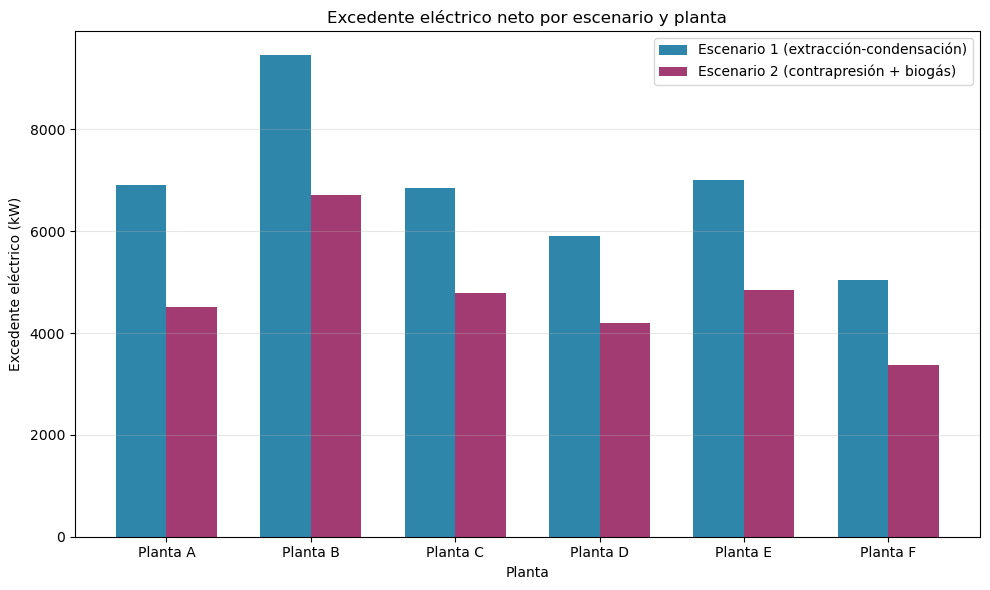

In [220]:
# ==========================================================
# Sección 12 - Comparación de escenarios (Línea base, Escenario 1, Escenario 2)
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np

# --- Recolectar resultados ya calculados ---
excedente_esc1 = {p: excedente_total_esc1_kW(p)[0] for p in plantas}
excedente_esc2 = {p: excedente_total_esc2_kW(p)[0] for p in plantas}

df_comparacion = pd.DataFrame({
    'Planta': plantas,
    'Escenario 1 (kW)': [excedente_esc1[p] for p in plantas],
    'Escenario 2 (kW)': [excedente_esc2[p] for p in plantas],
})
df_comparacion['Esc.2 / Esc.1 (%)'] = 100 * df_comparacion['Escenario 2 (kW)'] / df_comparacion['Escenario 1 (kW)']

print(df_comparacion.to_string(index=False))

# --- Gráfico de barras agrupadas ---
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(plantas))
ancho = 0.35

ax.bar(x - ancho/2, df_comparacion['Escenario 1 (kW)'], ancho, label='Escenario 1 (extracción-condensación)', color='#2E86AB')
ax.bar(x + ancho/2, df_comparacion['Escenario 2 (kW)'], ancho, label='Escenario 2 (contrapresión + biogás)', color='#A23B72')

ax.set_xlabel('Planta')
ax.set_ylabel('Excedente eléctrico (kW)')
ax.set_title('Excedente eléctrico neto por escenario y planta')
ax.set_xticks(x)
ax.set_xticklabels(plantas)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_excedente_escenarios.png', dpi=150)
plt.show()

df_comparacion.to_csv('comparacion_excedente_escenarios.csv', index=False)

  Planta  LB - % autogenerado (biomasa+biogás)  Escenario 1 - Excedente (kW)  Escenario 2 - Excedente (kW)
Planta A                             79.127913                   6906.929270                   4510.527791
Planta B                              0.000000                   9455.142458                   6706.756382
Planta C                              0.000000                   6852.339190                   4790.997899
Planta D                             70.000000                   5898.162820                   4190.431520
Planta E                              0.000000                   7012.353598                   4836.818628
Planta F                              0.000000                   5052.252448                   3379.603849


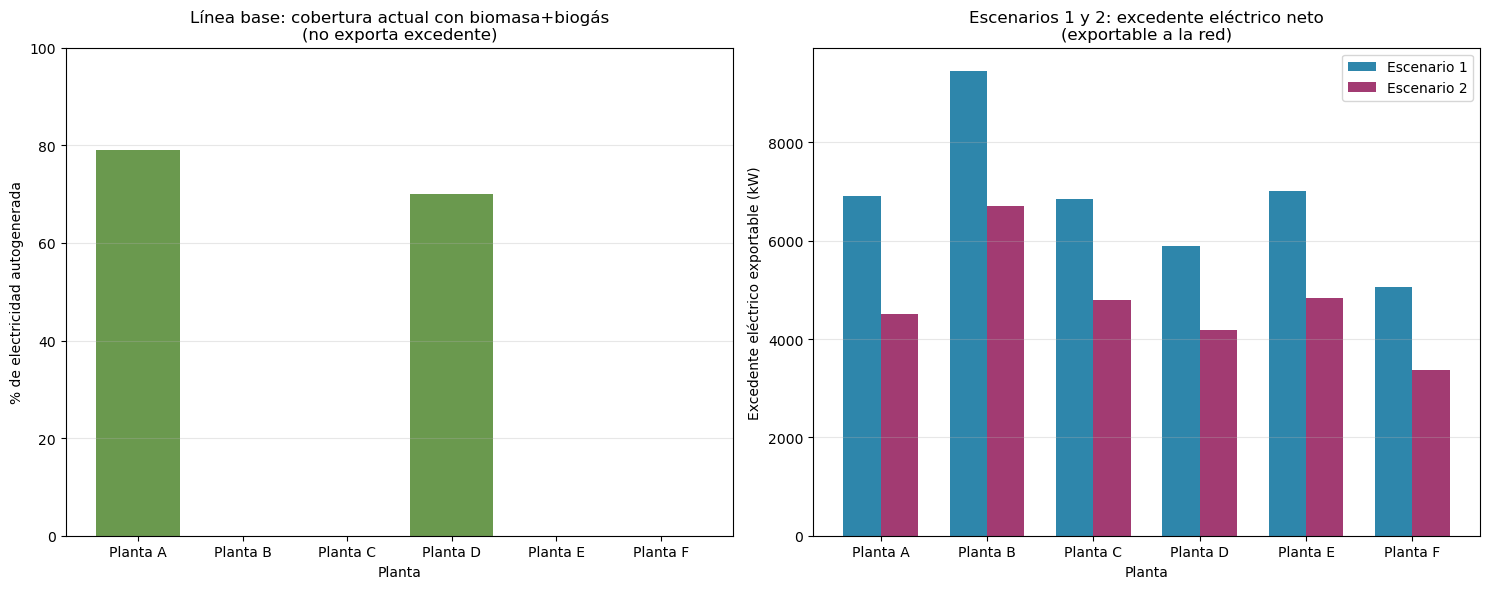

In [221]:
# ==========================================================
# Sección 12 - Comparación de escenarios (actualizado con línea base)
# Línea base: % de electricidad autogenerada con biomasa+biogás (métrica 
# distinta al excedente, ya que hoy no exporta nada a la red)
# Escenarios 1 y 2: excedente eléctrico neto exportable (kW)
# ==========================================================
# --- Línea base: % autogenerado (de Sección 8.1, df_fuente_electrica_LB) ---
df_fuente_electrica_LB['Pct_autogenerado'] = 100 * (
    df_fuente_electrica_LB['Electricidad_biomasa_kWh_ano'] + df_fuente_electrica_LB['Electricidad_biogas_kWh_ano']
) / df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano']

pct_autogenerado_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Pct_autogenerado']))

# --- Tabla consolidada ---
df_comparacion = pd.DataFrame({
    'Planta': plantas,
    'LB - % autogenerado (biomasa+biogás)': [pct_autogenerado_LB[p] for p in plantas],
    'Escenario 1 - Excedente (kW)': [excedente_esc1[p] for p in plantas],
    'Escenario 2 - Excedente (kW)': [excedente_esc2[p] for p in plantas],
})
print(df_comparacion.to_string(index=False))
df_comparacion.to_csv('comparacion_3_escenarios.csv', index=False)

# --- Gráfico de dos paneles ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(plantas))
ancho = 0.35

# Panel izquierdo: línea base, % autogenerado
ax1.bar(x, df_comparacion['LB - % autogenerado (biomasa+biogás)'], color='#6A994E')
ax1.set_xlabel('Planta')
ax1.set_ylabel('% de electricidad autogenerada')
ax1.set_title('Línea base: cobertura actual con biomasa+biogás\n(no exporta excedente)')
ax1.set_xticks(x)
ax1.set_xticklabels(plantas)
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)

# Panel derecho: Escenarios 1 y 2, excedente kW (el gráfico que ya validamos)
ax2.bar(x - ancho/2, df_comparacion['Escenario 1 - Excedente (kW)'], ancho, label='Escenario 1', color='#2E86AB')
ax2.bar(x + ancho/2, df_comparacion['Escenario 2 - Excedente (kW)'], ancho, label='Escenario 2', color='#A23B72')
ax2.set_xlabel('Planta')
ax2.set_ylabel('Excedente eléctrico exportable (kW)')
ax2.set_title('Escenarios 1 y 2: excedente eléctrico neto\n(exportable a la red)')
ax2.set_xticks(x)
ax2.set_xticklabels(plantas)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_3_escenarios.png', dpi=150)
plt.show()

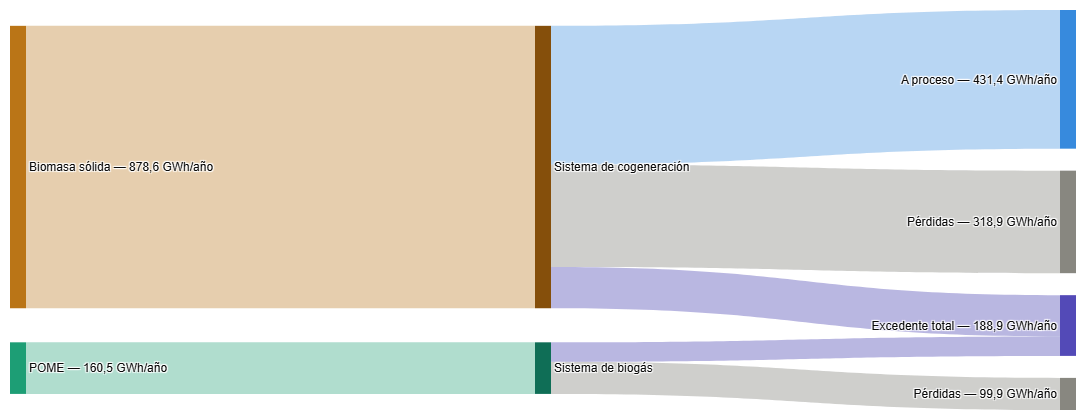

In [222]:
# ==========================================================
# Sección 12 (o nueva sección de figuras) - Diagrama Sankey
# Balance energético del Escenario 1: biomasa bruta y POME 
# hasta pérdidas, energía a proceso y excedente eléctrico
# ==========================================================
import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    orientation="h",
    node=dict(
        pad=22,
        thickness=16,
        line=dict(color="rgba(0,0,0,0)", width=0),
        label=[
            "Biomasa sólida — 878,6 GWh/año",
            "POME — 160,5 GWh/año",
            "Sistema de cogeneración",
            "Sistema de biogás",
            "Pérdidas — 318,9 GWh/año",
            "A proceso — 431,4 GWh/año",
            "Excedente total — 188,9 GWh/año",
            "Pérdidas — 99,9 GWh/año",
        ],
        color=["#BA7517", "#1D9E75", "#854F0B", "#0F6E56", "#888780", "#378ADD", "#534AB7", "#888780"],
    ),
    link=dict(
        source=[0, 1, 2, 2, 2, 3, 3],
        target=[2, 3, 4, 5, 6, 7, 6],
        value=[878.6, 160.5, 318.9, 431.4, 128.3, 99.9, 60.6],
        color=[
            "rgba(186,117,23,0.35)", "rgba(29,158,117,0.35)", "rgba(136,135,128,0.4)",
            "rgba(55,138,221,0.35)", "rgba(83,74,183,0.4)", "rgba(136,135,128,0.4)",
            "rgba(83,74,183,0.4)",
        ],
    ),
)])

fig.update_layout(
    font=dict(color="#0b0b0b", size=12, family="Arial, sans-serif"),
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=10, r=10, t=10, b=10),
    height=420,
)

fig.show()
fig.write_html("sankey_energia_escenario1.html")
fig.write_image("sankey_energia_escenario1.png", scale=2)  # requiere 'kaleido' instalado

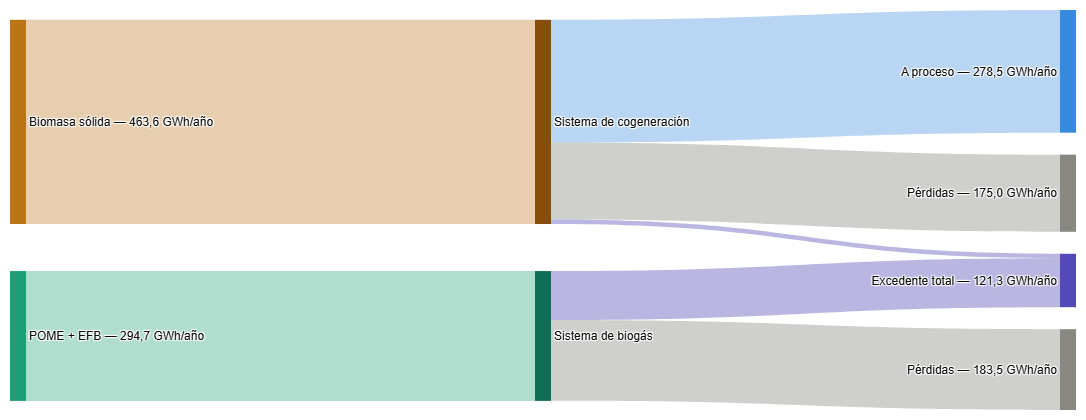

In [223]:
# ==========================================================
# Sección 12 (o nueva sección de figuras) - Diagrama Sankey, Escenario 2
# Balance energético: biomasa (solo Cuesco+Fibra) y POME+EFB pretratado 
# hasta pérdidas, energía a proceso y excedente eléctrico
# ==========================================================
import plotly.graph_objects as go

fig2 = go.Figure(data=[go.Sankey(
    orientation="h",
    node=dict(
        pad=22,
        thickness=16,
        line=dict(color="rgba(0,0,0,0)", width=0),
        label=[
            "Biomasa sólida — 463,6 GWh/año",
            "POME + EFB — 294,7 GWh/año",
            "Sistema de cogeneración",
            "Sistema de biogás",
            "Pérdidas — 175,0 GWh/año",
            "A proceso — 278,5 GWh/año",
            "Excedente total — 121,3 GWh/año",
            "Pérdidas — 183,5 GWh/año",
        ],
        color=["#BA7517", "#1D9E75", "#854F0B", "#0F6E56", "#888780", "#378ADD", "#534AB7", "#888780"],
    ),
    link=dict(
        source=[0, 1, 2, 2, 2, 3, 3],
        target=[2, 3, 4, 5, 6, 7, 6],
        value=[463.6, 294.7, 175.0, 278.5, 10.1, 183.5, 111.1],
        color=[
            "rgba(186,117,23,0.35)", "rgba(29,158,117,0.35)", "rgba(136,135,128,0.4)",
            "rgba(55,138,221,0.35)", "rgba(83,74,183,0.4)", "rgba(136,135,128,0.4)",
            "rgba(83,74,183,0.4)",
        ],
    ),
)])

fig2.update_layout(
    font=dict(color="#0b0b0b", size=12, family="Arial, sans-serif"),
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=10, r=10, t=10, b=10),
    height=420,
)

fig2.show()
fig2.write_html("sankey_energia_escenario2.html")
fig2.write_image("sankey_energia_escenario2.png", scale=2)

## Sección 13 (nueva): impacto social de los 3 escenarios

In [124]:
# ==========================================================
# Sección 13 - Impacto social de los 3 escenarios
# Horas de operación anual: hoja Eficiencia, fila Excel 6
# ==========================================================
raw_efi_horas = pd.read_excel('Escenarios.xlsx', sheet_name='Eficiencia', header=None)
horas_operacion_anual = dict(zip(plantas, raw_efi_horas.iloc[5, 2:8].tolist()))
print("Horas de operación anual por planta:", horas_operacion_anual)

# --- Convertir excedente eléctrico (kW) a energía anual (kWh/año) ---
excedentes_esc1_kWh_ano = {p: excedente_esc1[p] * horas_operacion_anual[p] for p in plantas}
excedentes_esc2_kWh_ano = {p: excedente_esc2[p] * horas_operacion_anual[p] for p in plantas}

# --- Aplicar las funciones ya construidas en la Sección 5 ---
df_impacto_esc1 = construir_tabla_impacto_social(excedentes_esc1_kWh_ano, 'Escenario_1_Termico')
df_impacto_esc2 = construir_tabla_impacto_social(excedentes_esc2_kWh_ano, 'Escenario_2_Biogas')

df_impacto_social = pd.concat([df_impacto_esc1, df_impacto_esc2], ignore_index=True)
print(df_impacto_social.to_string(index=False))

df_impacto_social.to_csv('impacto_social_escenarios.csv', index=False)

Horas de operación anual por planta: {'Planta A': 5105, 'Planta B': 5155, 'Planta C': 5920, 'Planta D': 5496, 'Planta E': 3147, 'Planta F': 1931}
          Escenario   Planta  Excedente_kWh_ano  Viviendas_rurales_beneficiadas  Personas_rurales_beneficiadas  Pct_cobertura_rural_departamental
Escenario_1_Termico Planta A       3.525987e+07                   101841.687332                  376814.243130                         116.369221
Escenario_1_Termico Planta B       4.874126e+07                   140780.199831                  520886.739376                         160.862242
Escenario_1_Termico Planta C       4.056585e+07                   117167.021588                  433517.979874                         133.880686
Escenario_1_Termico Planta D       3.241630e+07                    93628.553175                  346425.646748                         106.984498
Escenario_1_Termico Planta E       2.206788e+07                    63739.019920                  235834.373703              

In [125]:
# ==========================================================
# Sección 13 - Ajuste: techo de 100% en cobertura rural departamental
# Se mantiene la columna original (Pct_cobertura_rural_departamental) para 
# trazabilidad, y se agrega una versión con techo + bandera de "supera 100%"
# para presentación en tablas/gráficos del artículo (evita la lectura 
# errónea de "más del 100% de cobertura").
# ==========================================================
df_impacto_social['Supera_100pct_cobertura'] = df_impacto_social['Pct_cobertura_rural_departamental'] > 100
df_impacto_social['Pct_cobertura_rural_departamental_techo'] = df_impacto_social['Pct_cobertura_rural_departamental'].clip(upper=100)

print(df_impacto_social[['Escenario', 'Planta', 'Pct_cobertura_rural_departamental',
                          'Pct_cobertura_rural_departamental_techo', 'Supera_100pct_cobertura']].to_string(index=False))

df_impacto_social.to_csv('impacto_social_escenarios.csv', index=False)

          Escenario   Planta  Pct_cobertura_rural_departamental  Pct_cobertura_rural_departamental_techo  Supera_100pct_cobertura
Escenario_1_Termico Planta A                         116.369221                               100.000000                     True
Escenario_1_Termico Planta B                         160.862242                               100.000000                     True
Escenario_1_Termico Planta C                         133.880686                               100.000000                     True
Escenario_1_Termico Planta D                         106.984498                               100.000000                     True
Escenario_1_Termico Planta E                          72.831276                                72.831276                    False
Escenario_1_Termico Planta F                          32.197688                                32.197688                    False
 Escenario_2_Biogas Planta A                          75.994206                           

## Sección 14: balance de emisiones de GEI por escenario

In [126]:
# ==========================================================
# Sección 14 - Balance de emisiones de GEI (CO2-eq) por escenario
# Combina: no-CO2 de combustión (biomasa/biogás), diésel de respaldo (3%, 
# eficiencia genset 30%), crédito por electricidad exportada (desplaza 
# red nacional), y crédito de absorción de palma (ya en balance_neto_GEI).
# Todas las funciones/factores ya definidos en la Sección 4.
# ==========================================================
kWh_a_TJ = 1 / 277_777.78  # 1 TJ = 277,777.78 kWh
FRACCION_DIESEL_RESPALDO = 0.03   # supuesto, 3% del consumo eléctrico propio
EFICIENCIA_GENSET_DIESEL = 0.30   # supuesto de literatura

fruto_procesado_anual = {p: horas_operacion_anual[p] * capacidades[p] * 1000 for p in plantas}  # kg/año aprox -> ton
fruto_procesado_anual_t = {p: horas_operacion_anual[p] * capacidades[p] for p in plantas}  # t/año

def balance_emisiones_esc1(planta):
    horas = horas_operacion_anual[planta]

    # --- No-CO2 de combustión de biomasa sólida ---
    energia_biomasa_kWth, _ = energia_biomasa_kWth_esc1(planta)
    energia_biomasa_TJ_ano = energia_biomasa_kWth * horas * kWh_a_TJ
    emisiones_biomasa = emisiones_no_co2_biomasa(energia_biomasa_TJ_ano, fuente='Biomasa sólida')

    # --- No-CO2 de combustión de biogás ---
    ch4_biogas_Nm3_h = biogas_pome(planta)['metano_Nm3_h']
    energia_biogas_TJ_ano = ch4_biogas_Nm3_h * LHV_CH4_kWh_Nm3 * horas * kWh_a_TJ
    emisiones_biogas = emisiones_no_co2_biomasa(energia_biogas_TJ_ano, fuente='Biogás')

    # --- Diésel de respaldo (3% del consumo eléctrico propio, genset 30%) ---
    consumo_propio_kWh_ano = consumo_electrico_esc1_kW(planta) * horas
    elec_diesel_kWh_ano = consumo_propio_kWh_ano * FRACCION_DIESEL_RESPALDO
    fuel_diesel_TJ_ano = (elec_diesel_kWh_ano / EFICIENCIA_GENSET_DIESEL) * kWh_a_TJ
    emisiones_diesel_kg = emisiones_diesel(fuel_diesel_TJ_ano)

    # --- Crédito por electricidad exportada (desplaza red nacional) ---
    excedente_kWh_ano = excedente_total_esc1_kW(planta)[0] * horas
    credito_exportacion_kg = -emisiones_red_nacional(excedente_kWh_ano)  # negativo = crédito

    # --- Balance total ---
    emisiones_proceso = emisiones_biomasa + emisiones_biogas + emisiones_diesel_kg + credito_exportacion_kg
    balance_neto = balance_neto_GEI(emisiones_proceso, fruto_procesado_anual_t[planta])

    return {'emisiones_biomasa_kg': emisiones_biomasa, 'emisiones_biogas_kg': emisiones_biogas,
            'emisiones_diesel_kg': emisiones_diesel_kg, 'credito_exportacion_kg': credito_exportacion_kg,
            'balance_neto_kgCO2eq_ano': balance_neto}

def balance_emisiones_esc2(planta):
    horas = horas_operacion_anual[planta]

    energia_biomasa_kWth = energia_biomasa_kWth_esc2(planta)
    energia_biomasa_TJ_ano = energia_biomasa_kWth * horas * kWh_a_TJ
    emisiones_biomasa = emisiones_no_co2_biomasa(energia_biomasa_TJ_ano, fuente='Biomasa sólida')

    ch4_biogas_Nm3_h = biogas_pome_y_efb_esc2(planta)['ch4_total_Nm3_h']
    energia_biogas_TJ_ano = ch4_biogas_Nm3_h * LHV_CH4_kWh_Nm3 * horas * kWh_a_TJ
    emisiones_biogas = emisiones_no_co2_biomasa(energia_biogas_TJ_ano, fuente='Biogás')

    consumo_propio_kWh_ano = consumo_electrico_esc2_kW(planta) * horas
    elec_diesel_kWh_ano = consumo_propio_kWh_ano * FRACCION_DIESEL_RESPALDO
    fuel_diesel_TJ_ano = (elec_diesel_kWh_ano / EFICIENCIA_GENSET_DIESEL) * kWh_a_TJ
    emisiones_diesel_kg = emisiones_diesel(fuel_diesel_TJ_ano)

    excedente_kWh_ano = excedente_total_esc2_kW(planta)[0] * horas
    credito_exportacion_kg = -emisiones_red_nacional(excedente_kWh_ano)

    emisiones_proceso = emisiones_biomasa + emisiones_biogas + emisiones_diesel_kg + credito_exportacion_kg
    balance_neto = balance_neto_GEI(emisiones_proceso, fruto_procesado_anual_t[planta])

    return {'emisiones_biomasa_kg': emisiones_biomasa, 'emisiones_biogas_kg': emisiones_biogas,
            'emisiones_diesel_kg': emisiones_diesel_kg, 'credito_exportacion_kg': credito_exportacion_kg,
            'balance_neto_kgCO2eq_ano': balance_neto}

print("Balance de emisiones GEI - Escenario 1 (kg CO2-eq/año):\n")
for p in plantas:
    r = balance_emisiones_esc1(p)
    print(f"{p}: biomasa={r['emisiones_biomasa_kg']:,.0f} | biogás={r['emisiones_biogas_kg']:,.0f} | "
          f"diésel={r['emisiones_diesel_kg']:,.0f} | crédito export={r['credito_exportacion_kg']:,.0f} | "
          f"BALANCE NETO={r['balance_neto_kgCO2eq_ano']:,.0f}")

print("\nBalance de emisiones GEI - Escenario 2 (kg CO2-eq/año):\n")
for p in plantas:
    r = balance_emisiones_esc2(p)
    print(f"{p}: biomasa={r['emisiones_biomasa_kg']:,.0f} | biogás={r['emisiones_biogas_kg']:,.0f} | "
          f"diésel={r['emisiones_diesel_kg']:,.0f} | crédito export={r['credito_exportacion_kg']:,.0f} | "
          f"BALANCE NETO={r['balance_neto_kgCO2eq_ano']:,.0f}")

Balance de emisiones GEI - Escenario 1 (kg CO2-eq/año):

Planta A: biomasa=1,211,682 | biogás=4,458 | diésel=116,725 | crédito export=-5,761,463 | BALANCE NETO=-25,109,973
Planta B: biomasa=1,474,681 | biogás=7,878 | diésel=105,503 | crédito export=-7,964,322 | BALANCE NETO=-34,221,508
Planta C: biomasa=1,307,013 | biogás=6,355 | diésel=116,696 | crédito export=-6,628,460 | BALANCE NETO=-29,181,499
Planta D: biomasa=918,614 | biogás=6,338 | diésel=80,494 | crédito export=-5,296,824 | BALANCE NETO=-22,103,694
Planta E: biomasa=701,201 | biogás=3,591 | diésel=78,330 | crédito export=-3,605,891 | BALANCE NETO=-15,571,895
Planta F: biomasa=301,676 | biogás=1,433 | diésel=20,023 | crédito export=-1,594,114 | BALANCE NETO=-6,486,227

Balance de emisiones GEI - Escenario 2 (kg CO2-eq/año):

Planta A: biomasa=634,143 | biogás=10,619 | diésel=102,311 | crédito export=-3,762,488 | BALANCE NETO=-23,696,791
Planta B: biomasa=754,686 | biogás=15,559 | diésel=86,992 | crédito export=-5,649,282 | BAL

In [127]:
# ==========================================================
# Sección 14 - Intensidad de emisiones SIN el crédito de absorción de palma
# (el crédito de absorción se reporta aparte, por tRFF, no por kWh, ya que 
# no depende de la tecnología de generación eléctrica)
# ==========================================================
def intensidad_emisiones(emisiones_kg_ano, energia_kWh_ano):
    """Intensidad de emisiones en gCO2eq/kWh, a partir de emisiones anuales 
    (kg CO2-eq/año) y energía exportada anual (kWh/año)."""
    return emisiones_kg_ano * 1000 / energia_kWh_ano

def balance_emisiones_solo_energia_esc1(planta):
    r = balance_emisiones_esc1(planta)
    return r['emisiones_biomasa_kg'] + r['emisiones_biogas_kg'] + r['emisiones_diesel_kg'] + r['credito_exportacion_kg']

def balance_emisiones_solo_energia_esc2(planta):
    r = balance_emisiones_esc2(planta)
    return r['emisiones_biomasa_kg'] + r['emisiones_biogas_kg'] + r['emisiones_diesel_kg'] + r['credito_exportacion_kg']

print("Intensidad de emisiones - SOLO sistema energético (sin absorción de palma), Escenario 1:\n")
for p in plantas:
    emisiones_energia = balance_emisiones_solo_energia_esc1(p)
    excedente_kWh_ano = excedente_total_esc1_kW(p)[0] * horas_operacion_anual[p]
    intensidad = intensidad_emisiones(emisiones_energia, excedente_kWh_ano)
    print(f"{p}: {intensidad:,.1f} gCO2eq/kWh")

print("\nIntensidad de emisiones - SOLO sistema energético (sin absorción de palma), Escenario 2:\n")
for p in plantas:
    emisiones_energia = balance_emisiones_solo_energia_esc2(p)
    excedente_kWh_ano = excedente_total_esc2_kW(p)[0] * horas_operacion_anual[p]
    intensidad = intensidad_emisiones(emisiones_energia, excedente_kWh_ano)
    print(f"{p}: {intensidad:,.1f} gCO2eq/kWh")

print(f"\nCrédito de absorción de palma (constante, no depende del escenario): {FACTOR_ABSORCION_PALMA} kg CO2/tRFF")

Intensidad de emisiones - SOLO sistema energético (sin absorción de palma), Escenario 1:

Planta A: -125.6 gCO2eq/kWh
Planta B: -130.8 gCO2eq/kWh
Planta C: -128.1 gCO2eq/kWh
Planta D: -132.4 gCO2eq/kWh
Planta E: -127.9 gCO2eq/kWh
Planta F: -130.3 gCO2eq/kWh

Intensidad de emisiones - SOLO sistema energético (sin absorción de palma), Escenario 2:

Planta A: -131.0 gCO2eq/kWh
Planta B: -138.6 gCO2eq/kWh
Planta C: -135.5 gCO2eq/kWh
Planta D: -136.6 gCO2eq/kWh
Planta E: -135.7 gCO2eq/kWh
Planta F: -133.8 gCO2eq/kWh

Crédito de absorción de palma (constante, no depende del escenario): -135.04 kg CO2/tRFF


## Sección 15: LCOE (costo nivelado de energía)

In [224]:
# ==========================================================
# Sección 15.0 — Núcleo económico: parámetros, motor de escalamiento y CAPEX
#
# CORRECCIONES CRÍTICAS respecto a versiones anteriores:
#  (1) REGLA DE LOS SEIS DÉCIMOS (exponente 0.6, Tabla 18 — Sinnot & Taylor,
#      Peters et al.) aplicada a TODOS los equipos. Antes se escalaba
#      linealmente, lo que sobreestimaba gravemente los equipos alejados de
#      su capacidad de referencia (la turbina de Esc.1 opera a 7.5x su
#      referencia de 1,000 kW -> el costo lineal la sobreestimaba >2x).
#  (2) DOBLE CONTEO DE LA CALDERA ELIMINADO: los costos de turbina de la
#      Tabla 17 ($3,669/kW extracción-condensación; $2,815/kW contrapresión)
#      YA INCLUYEN la caldera. La partida separada "Caldera" se elimina.
#
# Efecto: CAPEX Esc.1 -54% ; CAPEX Esc.2 -30%.
# ==========================================================

# --- Parámetros financieros ---
TASA_DESCUENTO = 0.10
VIDA_UTIL_ANOS = 20
PVAF = (1 - (1 + TASA_DESCUENTO) ** -VIDA_UTIL_ANOS) / TASA_DESCUENTO
PCT_OPERACION_ANUAL = 0.025          # O&M anual como % del CAPEX (Tabla 18)
N_ESCALAMIENTO = 0.6                 # regla de los seis décimos (Tabla 18)

# --- Precios (Tabla 18 + fuentes primarias) ---
PRECIO_ELECTRICIDAD_VENTA = 0.06     # $/kWh (legado CREG 030; CREG 174 lo sustituye en Fase 2)
PRECIO_PKS = 16                      # $/t cuesco  (costo de oportunidad al quemarlo)
PRECIO_MF  = 8                       # $/t fibra
TRM_COP_USD = 3339.65

# Precio de compra ESPECÍFICO POR PLANTA = costo ponderado real de su matriz
# eléctrica actual (línea base). No un valor único de red: Planta A y D ya
# cogeneran barato, así que su ahorro marginal al invertir es menor.
PRECIO_ELECTRICIDAD_COMPRA_dict = {
    'Planta A': 0.1141, 'Planta B': 0.2537, 'Planta C': 0.2572,
    'Planta D': 0.1530, 'Planta E': 0.2551, 'Planta F': 0.2591,
}

# ==========================================================
# Motor de escalamiento (regla de los seis décimos)
# ==========================================================
def costo_escalado(costo_unitario_ref, capacidad_ref, capacidad_real):
    """Costo TOTAL (USD 2026) de un equipo a `capacidad_real`.

    costo_unitario_ref : $/unidad A LA CAPACIDAD DE REFERENCIA (Tabla 17)
    capacidad_ref      : capacidad a la que aplica ese costo unitario
    """
    costo_total_ref = costo_unitario_ref * capacidad_ref
    return costo_total_ref * factor_cepci_2019 * (capacidad_real / capacidad_ref) ** N_ESCALAMIENTO

# --- Tabla 17: (costo unitario, capacidad de referencia) ---
REF = {
    'turbina_extraccion':    (3669,  1000),   # $/kW    @ 1,000 kW    INCLUYE CALDERA
    'turbina_contrapresion': (2815,  1000),   # $/kW    @ 1,000 kW    INCLUYE CALDERA
    'precipitador':          (25000, 15),     # $/tvap  @ 15 t vapor  (Esc.1)
    'gases_combustion':      (11515, 15),     # $/tvap  @ 15 t vapor  (Esc.2; ref. supuesta por analogía)
    'pretrat_mecanico':      (29655, 3),      # $/tEFB  @ 3 tEFB
    'lagunas_carpadas':      (18518, 27),     # $/tRFF  @ 27 t/h
    'tratamiento_biogas':    (424,   660),    # $/m3    @ 660 m3/h
    'generador_biogas':      (186,   1500),   # $/kW    @ 1,500 kW
    'esteriliz_continua':    (38400, 20),     # $/tRFF  @ 20 t/h
    'clarif_dinamica':       (23368, 15),     # $/tRFF  @ 15 t/h
}
COSTO_REDES_INFRA_USD_tRFF = 7153.13 * factor_cepci_2019   # LINEAL (infraestructura ~proporcional)
CAP_REF_TRAT_TERMICO, COSTO_REF_TRAT_TERMICO = 5.6, 178571  # tEFB/h ; $ total (Tabla 17)

# ==========================================================
# Catálogos comerciales -> CAPEX por tamaño (con economías de escala)
# El costo por kW YA NO es constante: cae con el tamaño. Por eso el CAPEX
# se precalcula por entrada de catálogo y entra al MILP como coeficiente
# de la binaria de selección (sigue siendo lineal en las binarias).
# ==========================================================
CATALOGO_TURBINA_ESC1 = [300, 500, 750, 1000, 1500, 2000, 3000, 4000,
                         5000, 6000, 7000, 8000, 9000, 10000]          # kW
CATALOGO_TURBINA_CONTRAPRESION = [750, 1000, 1250, 1500, 1750]         # kW

CAPEX_TURBINA_ESC1 = {k: costo_escalado(*REF['turbina_extraccion'], k)
                      for k in CATALOGO_TURBINA_ESC1}
CAPEX_TURBINA_ESC2 = {k: costo_escalado(*REF['turbina_contrapresion'], k)
                      for k in CATALOGO_TURBINA_CONTRAPRESION}

# Generador de biogás: N unidades modulares de 1 MW (motogeneradores POME).
# Las economías de escala aplican al DIMENSIONAR UNA unidad respecto a la
# referencia (1,500 kW), NO a replicar unidades idénticas: N módulos iguales
# cuestan N x costo_unidad. Por eso el CAPEX es lineal en N.
TAMANO_UNIDAD_BIOGAS_KW = 1000
N_MAX_UNIDADES_BIOGAS = 8
CAPEX_UNIDAD_BIOGAS = costo_escalado(*REF['generador_biogas'], TAMANO_UNIDAD_BIOGAS_KW)

# ==========================================================
# CAPEX incremental por escenario
# (solo inversión NUEVA; la planta extractora ya existe)
# NOTA: las claves 'Turbina' y 'Generador de biogás' se usan como filtro en
# la Fase 2 para excluir lo que ya es variable de decisión -> NO renombrar
# sin actualizar capex_fijo_esc1/esc2.
# ==========================================================
def capex_incremental_esc1(planta):
    pot_turbina_kW = potencia_turbina_kW(planta)['potencia_bruta_kW']
    cap_vapor_t_h  = vapor_producido_kg_h(planta) / 1000
    flujo_efb_t_h  = df_biomasa_disponible.loc[planta, 'Raquis'] / 1000
    r_bio          = biogas_pome(planta)
    pot_biogas_kW  = r_bio['generacion_bruta_kW']
    biogas_m3_h    = r_bio['metano_Nm3_h'] / 0.65          # supuesto 65% CH4

    return {
        'Turbina':                             costo_escalado(*REF['turbina_extraccion'], pot_turbina_kW),
        'Precipitador electroestático':        costo_escalado(*REF['precipitador'], cap_vapor_t_h),
        'Pretratamiento mecánico EFB':         costo_escalado(*REF['pretrat_mecanico'], flujo_efb_t_h),
        'Lagunas carpadas (reactor)':          costo_escalado(*REF['lagunas_carpadas'], capacidades[planta]),
        'Tratamiento de biogás':               costo_escalado(*REF['tratamiento_biogas'], biogas_m3_h),
        'Generador de biogás':                 costo_escalado(*REF['generador_biogas'], pot_biogas_kW),
        'Sustitución esterilización continua': costo_escalado(*REF['esteriliz_continua'], capacidades[planta]),
        'Sustitución clarificación dinámica':  costo_escalado(*REF['clarif_dinamica'], capacidades[planta]),
        'Redes e infraestructura':             COSTO_REDES_INFRA_USD_tRFF * capacidades[planta],
    }

def capex_incremental_esc2(planta):
    pot_turbina_kW = potencia_turbina_esc2_kW(planta)['potencia_bruta_kW']
    cap_vapor_t_h  = vapor_producido_kg_h_esc2(planta) / 1000
    flujo_efb_t_h  = df_biomasa_disponible.loc[planta, 'Raquis'] / 1000
    r_bio          = biogas_pome_y_efb_esc2(planta)
    pot_biogas_kW  = r_bio['generacion_bruta_kW']
    biogas_m3_h    = r_bio['ch4_efluente_Nm3_h'] / 0.65 + r_bio['ch4_efb_Nm3_h'] / 0.54

    costo_trat_termico = (COSTO_REF_TRAT_TERMICO * factor_cepci_2019
                          * (flujo_efb_t_h / CAP_REF_TRAT_TERMICO) ** N_ESCALAMIENTO)

    return {
        'Turbina':                            costo_escalado(*REF['turbina_contrapresion'], pot_turbina_kW),
        'Sistema gases de combustión':        costo_escalado(*REF['gases_combustion'], cap_vapor_t_h),
        'Tratamiento térmico EFB':            costo_trat_termico,
        'Lagunas carpadas (reactor)':         costo_escalado(*REF['lagunas_carpadas'], capacidades[planta]),
        'Tratamiento de biogás':              costo_escalado(*REF['tratamiento_biogas'], biogas_m3_h),
        'Generador de biogás':                costo_escalado(*REF['generador_biogas'], pot_biogas_kW),
        'Sustitución clarificación dinámica': costo_escalado(*REF['clarif_dinamica'], capacidades[planta]),
        'Redes e infraestructura':            COSTO_REDES_INFRA_USD_tRFF * capacidades[planta],
    }

def lcoe_escenario(planta, capex_items, excedente_kW, consumo_propio_kW, escenario_num):
    horas = horas_operacion_anual[planta]
    capex_total = sum(capex_items.values())

    excedente_kWh_ano = excedente_kW * horas
    consumo_propio_kWh_ano = consumo_propio_kW * horas

    ahorro_autoconsumo = PRECIO_ELECTRICIDAD_COMPRA_dict[planta] * consumo_propio_kWh_ano
    venta_excedente = PRECIO_ELECTRICIDAD_VENTA * excedente_kWh_ano

    cuesco_t_ano = (df_biomasa_disponible.loc[planta, 'Cuesco']/1000) * horas
    fibra_t_ano = (df_biomasa_disponible.loc[planta, 'Fibra']/1000) * horas
    costo_oportunidad_pks_mf = PRECIO_PKS * cuesco_t_ano + PRECIO_MF * fibra_t_ano

    costo_operacion_anual = PCT_OPERACION_ANUAL * capex_total

    opex_neto_anual = costo_operacion_anual + costo_oportunidad_pks_mf - ahorro_autoconsumo - venta_excedente

    lcoe = capex_total / (excedente_kWh_ano * PVAF) + opex_neto_anual / excedente_kWh_ano

    return {'capex_total': capex_total, 'opex_neto_anual': opex_neto_anual,
            'excedente_kWh_ano': excedente_kWh_ano, 'lcoe_USD_kWh': lcoe}

print("CAPEX incremental total (USD 2026) — regla 0.6, sin doble conteo de caldera:\n")
print(f"{'Planta':10} {'Escenario 1':>16} {'Escenario 2':>16}")
for p in plantas:
    print(f"{p:10} {sum(capex_incremental_esc1(p).values()):16,.0f} "
          f"{sum(capex_incremental_esc2(p).values()):16,.0f}")

print("\nCatálogo turbina Esc.1 — economías de escala:")
print(f"{'kW':>7} {'CAPEX':>14} {'$/kW':>8} {'$/kW/año':>10}")
for k in CATALOGO_TURBINA_ESC1:
    c = CAPEX_TURBINA_ESC1[k]
    print(f"{k:7,} {c:14,.0f} {c/k:8,.0f} {c/k/PVAF:10,.1f}")
print(f"\nCAPEX unidad biogás (1 MW): ${CAPEX_UNIDAD_BIOGAS:,.0f}")


CAPEX incremental total (USD 2026) — regla 0.6, sin doble conteo de caldera:

Planta          Escenario 1      Escenario 2
Planta A         22,996,475        8,789,180
Planta B         26,090,473       10,116,479
Planta C         22,025,384        8,573,240
Planta D         18,918,120        7,711,279
Planta E         22,473,772        8,504,885
Planta F         17,964,577        7,095,192

Catálogo turbina Esc.1 — economías de escala:
     kW          CAPEX     $/kW   $/kW/año
    300      2,562,632    8,542    1,003.4
    500      3,481,733    6,963      817.9
    750      4,440,688    5,921      695.5
  1,000      5,277,320    5,277      619.9
  1,500      6,730,824    4,487      527.1
  2,000      7,998,922    3,999      469.8
  3,000     10,202,021    3,401      399.4
  4,000     12,124,099    3,031      356.0
  5,000     13,861,029    2,772      325.6
  6,000     15,463,373    2,577      302.7
  7,000     16,961,814    2,423      284.6
  8,000     18,376,697    2,297      269.8
 

In [225]:
# ==========================================================
# Sección 15 - Conversión LCOE a pesos colombianos (COP)
# TRM del 9 de julio de 2026: $3,339.65 COP/USD (fuente: Banco de la 
# República / TRM oficial) - actualizar si se corre en otra fecha
# ==========================================================
TRM_COP_USD = 3339.65

print("LCOE - Escenario 1 (USD/kWh y COP/kWh):\n")
for p in plantas:
    items1 = capex_incremental_esc1(p)
    r = lcoe_escenario(p, items1, excedente_esc1[p], consumo_electrico_esc1_kW(p), 1)
    lcoe_cop = r['lcoe_USD_kWh'] * TRM_COP_USD
    print(f"{p}: LCOE=${r['lcoe_USD_kWh']:.4f}/kWh  |  ${lcoe_cop:,.1f} COP/kWh")

print("\nLCOE - Escenario 2 (USD/kWh y COP/kWh):\n")
for p in plantas:
    items2 = capex_incremental_esc2(p)
    r = lcoe_escenario(p, items2, excedente_esc2[p], consumo_electrico_esc2_kW(p), 2)
    lcoe_cop = r['lcoe_USD_kWh'] * TRM_COP_USD
    print(f"{p}: LCOE=${r['lcoe_USD_kWh']:.4f}/kWh  |  ${lcoe_cop:,.1f} COP/kWh")

LCOE - Escenario 1 (USD/kWh y COP/kWh):

Planta A: LCOE=$0.0272/kWh  |  $90.8 COP/kWh
Planta B: LCOE=$0.0027/kWh  |  $9.0 COP/kWh
Planta C: LCOE=$-0.0028/kWh  |  $-9.3 COP/kWh
Planta D: LCOE=$0.0166/kWh  |  $55.6 COP/kWh
Planta E: LCOE=$0.0581/kWh  |  $194.1 COP/kWh
Planta F: LCOE=$0.1908/kWh  |  $637.4 COP/kWh

LCOE - Escenario 2 (USD/kWh y COP/kWh):

Planta A: LCOE=$-0.0117/kWh  |  $-39.1 COP/kWh
Planta B: LCOE=$-0.0323/kWh  |  $-108.0 COP/kWh
Planta C: LCOE=$-0.0407/kWh  |  $-136.1 COP/kWh
Planta D: LCOE=$-0.0188/kWh  |  $-62.8 COP/kWh
Planta E: LCOE=$-0.0143/kWh  |  $-47.6 COP/kWh
Planta F: LCOE=$0.0827/kWh  |  $276.0 COP/kWh


In [148]:
# ==========================================================
# Sección 15 - LCOE bruto (convencional, sin restar ingresos/ahorros)
# Complementa el LCOE neto ya calculado - para reportar ambos en el 
# artículo y evitar que un LCOE negativo se malinterprete
# ==========================================================
def lcoe_bruto(planta, capex_items, excedente_kW):
    horas = horas_operacion_anual[planta]
    capex_total = sum(capex_items.values())
    excedente_kWh_ano = excedente_kW * horas
    costo_operacion_anual = PCT_OPERACION_ANUAL * capex_total   # solo O&M, sin ingresos
    lcoe = capex_total / (excedente_kWh_ano * PVAF) + costo_operacion_anual / excedente_kWh_ano 
    return lcoe

print("LCOE bruto vs. neto - Escenario 1:\n")
for p in plantas:
    items1 = capex_incremental_esc1(p)
    bruto = lcoe_bruto(p, items1, excedente_esc1[p])
    neto = lcoe_escenario(p, items1, excedente_esc1[p], consumo_electrico_esc1_kW(p), 1)['lcoe_USD_kWh']
    print(f"{p}: bruto=${bruto:.4f}/kWh | neto=${neto:.4f}/kWh")

print("\nLCOE bruto vs. neto - Escenario 2:\n")
for p in plantas:
    items2 = capex_incremental_esc2(p)
    bruto = lcoe_bruto(p, items2, excedente_esc2[p])
    neto = lcoe_escenario(p, items2, excedente_esc2[p], consumo_electrico_esc2_kW(p), 2)['lcoe_USD_kWh']
    print(f"{p}: bruto=${bruto:.4f}/kWh | neto=${neto:.4f}/kWh")

LCOE bruto vs. neto - Escenario 1:

Planta A: bruto=$0.0929/kWh | neto=$0.0272/kWh
Planta B: bruto=$0.0763/kWh | neto=$0.0027/kWh
Planta C: bruto=$0.0773/kWh | neto=$-0.0028/kWh
Planta D: bruto=$0.0831/kWh | neto=$0.0166/kWh
Planta E: bruto=$0.1451/kWh | neto=$0.0581/kWh
Planta F: bruto=$0.2623/kWh | neto=$0.1908/kWh

LCOE bruto vs. neto - Escenario 2:

Planta A: bruto=$0.0544/kWh | neto=$-0.0117/kWh
Planta B: bruto=$0.0417/kWh | neto=$-0.0323/kWh
Planta C: bruto=$0.0431/kWh | neto=$-0.0407/kWh
Planta D: bruto=$0.0477/kWh | neto=$-0.0188/kWh
Planta E: bruto=$0.0796/kWh | neto=$-0.0143/kWh
Planta F: bruto=$0.1549/kWh | neto=$0.0827/kWh


## Sección 16 — Fase 2 (superestructura), Escenario 1: turbina extracción-condensación + biogás de POME

*Reorganizada para dejar solo el flujo final y correcto; las iteraciones exploratorias superadas quedan archivadas en 16.6, sin ejecutarse como parte del resultado reportado.*

### 16.1 Parámetros, catálogos y remuneración CREG 174

In [149]:
# ==========================================================
# Sección 16.1 - Parámetros y catálogos, Escenario 1 (turbina
# extracción-condensación + biogás de POME)
# ==========================================================
CATALOGO_TURBINA_ESC1 = [300, 500, 750, 1000, 1500, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]  # kW

potencia_ideal_dict = {p: potencia_turbina_kW(p)['potencia_bruta_kW'] for p in plantas}
consumo_medido_dict = {p: consumo_electrico_esc1_kW(p) for p in plantas}
potencia_ideal_biogas_esc1_dict = {p: biogas_pome(p)['generacion_bruta_kW'] for p in plantas}

# Remuneración CREG 174 de 2021 (deroga CREG 030) - 3 tramos:
#   Tramo 1 - autoconsumo: precio ponderado de la planta (deja de comprar)
#   Tramo 2 - excedente hasta = consumo: precio minorista (permuta ~ precio planta)
#   Tramo 3 - excedente sobre consumo: precio de bolsa promedio
PRECIO_BOLSA_PROMEDIO = 0.0703  # USD/kWh, promedio 11 meses XM (ene25-mar26)
PRECIO_TRAMO_12_dict = PRECIO_ELECTRICIDAD_COMPRA_dict  # tramos 1 y 2 comparten precio ponderado de planta

# Generador de biogás como N unidades modulares (mismo criterio usado en
# Sección 17 para Escenario 2 — motogeneradores biogás POME se instalan
# típicamente en módulos de ~1 MW, ver revisión bibliográfica)
TAMANO_UNIDAD_BIOGAS_KW = 1000
N_MAX_UNIDADES_BIOGAS = 8


### 16.2 Modelo (turbina + biogás, dos rutas independientes) y payoff table lexicográfica

In [160]:
# [CAPEX CORREGIDO] La turbina entra con CAPEX POR TAMAÑO (regla 0.6,
# economías de escala) como coeficiente de la binaria; el generador de
# biogás como N x CAPEX_UNIDAD_BIOGAS (módulos idénticos -> lineal en N).
# ==========================================================
# Fase 2 - Multiobjetivo, Paso 1: Payoff table (lexicográfica)
# Dos rutas independientes: turbina de extracción-condensación
# (catálogo discreto) + biogás de POME (N unidades de 1,000 kW).
#   f1 = beneficio económico (ahorro + venta - CAPEX anualizado)  [MAX]
#   f2 = electricidad total generada con biomasa+biogás (kWh/año) [MAX]
# ==========================================================
def construir_modelo_f2(objetivo='economico', restriccion_f2=None, restriccion_f1=None):
    """objetivo: 'economico' o 'excedente'.
       restriccion_f2/f1: valor mínimo a imponer sobre el otro objetivo (para lexicográfica y ε-constraint)."""
    m = pyo.ConcreteModel()
    m.PLANTAS = pyo.Set(initialize=plantas)
    m.TAMANOS = pyo.Set(initialize=CATALOGO_TURBINA_ESC1)

    m.potencia_ideal_kW = pyo.Param(m.PLANTAS, initialize=potencia_ideal_dict)
    m.potencia_ideal_biogas = pyo.Param(m.PLANTAS, initialize=potencia_ideal_biogas_esc1_dict)
    m.consumo_medido_kW = pyo.Param(m.PLANTAS, initialize=consumo_medido_dict)
    m.horas = pyo.Param(m.PLANTAS, initialize=horas_operacion_anual)
    m.costo_oport = pyo.Param(m.PLANTAS, initialize=costo_oport_dict)
    m.precio_tramo12 = pyo.Param(m.PLANTAS, initialize=PRECIO_TRAMO_12_dict)
    m.precio_bolsa = pyo.Param(initialize=PRECIO_BOLSA_PROMEDIO)
    m.pvaf = pyo.Param(initialize=PVAF)

    m.z = pyo.Var(m.PLANTAS, m.TAMANOS, domain=pyo.Binary)
    m.n_unidades_biogas = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeIntegers, bounds=(0, N_MAX_UNIDADES_BIOGAS))
    m.capacidad_turbina_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.capacidad_biogas_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.factor_utilizacion = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals, bounds=(0, 1))
    m.factor_util_biogas = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals, bounds=(0, 1))
    m.potencia_turbina_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.potencia_biogas_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.autoconsumo_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.excedente_permuta_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.excedente_bolsa_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)

    m.r_una_seleccion = pyo.Constraint(m.PLANTAS, rule=lambda m, p: sum(m.z[p, k] for k in m.TAMANOS) == 1)
    m.r_capacidad = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.capacidad_turbina_kW[p] == sum(k*m.z[p, k] for k in m.TAMANOS))
    m.r_cap_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.capacidad_biogas_kW[p] == m.n_unidades_biogas[p] * TAMANO_UNIDAD_BIOGAS_KW)
    m.r_potencia = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_turbina_kW[p] == m.factor_utilizacion[p]*m.potencia_ideal_kW[p])
    m.r_pot_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_biogas_kW[p] == m.factor_util_biogas[p]*m.potencia_ideal_biogas[p])
    m.r_no_exceder = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_turbina_kW[p] <= m.capacidad_turbina_kW[p])
    m.r_no_exc_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_biogas_kW[p] <= m.capacidad_biogas_kW[p])
    m.r_reparto = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_turbina_kW[p] + m.potencia_biogas_kW[p]
                                 == m.autoconsumo_kW[p] + m.excedente_permuta_kW[p] + m.excedente_bolsa_kW[p])
    m.r_tope_auto = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.autoconsumo_kW[p] <= m.consumo_medido_kW[p])
    m.r_tope_permuta = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.excedente_permuta_kW[p] <= m.consumo_medido_kW[p])

    # --- Expresiones de los 2 objetivos ---
    m.f1_economico = pyo.Expression(expr=(
        sum(m.autoconsumo_kW[p]*m.horas[p]*m.precio_tramo12[p] for p in m.PLANTAS)
        + sum(m.excedente_permuta_kW[p]*m.horas[p]*m.precio_tramo12[p] for p in m.PLANTAS)
        + sum(m.excedente_bolsa_kW[p]*m.horas[p]*m.precio_bolsa for p in m.PLANTAS)
        - sum(sum(CAPEX_TURBINA_ESC1[k]*m.z[p, k] for k in m.TAMANOS)/m.pvaf for p in m.PLANTAS)
        - sum(m.n_unidades_biogas[p]*CAPEX_UNIDAD_BIOGAS/m.pvaf for p in m.PLANTAS)
        # [NUEVO] O&M anual (2.5% del CAPEX variable)
        - sum(sum(CAPEX_TURBINA_ESC1[k]*m.z[p, k] for k in m.TAMANOS)*PCT_OPERACION_ANUAL for p in m.PLANTAS)
        - sum(m.n_unidades_biogas[p]*CAPEX_UNIDAD_BIOGAS*PCT_OPERACION_ANUAL for p in m.PLANTAS)
        # [NUEVO] Costo de oportunidad de la biomasa quemada (escala con el uso)
        - sum(m.factor_utilizacion[p]*m.costo_oport[p] for p in m.PLANTAS)))
   
    m.f2_generacion = pyo.Expression(expr=sum((m.potencia_turbina_kW[p] + m.potencia_biogas_kW[p])*m.horas[p] for p in m.PLANTAS))

    if restriccion_f1 is not None:
        m.r_eps_f1 = pyo.Constraint(expr=m.f1_economico >= restriccion_f1)
    if restriccion_f2 is not None:
        m.r_eps_f2 = pyo.Constraint(expr=m.f2_generacion >= restriccion_f2)

    if objetivo == 'economico':
        m.obj = pyo.Objective(expr=m.f1_economico, sense=pyo.maximize)
    else:
        m.obj = pyo.Objective(expr=m.f2_generacion, sense=pyo.maximize)
    return m

# --- Fila 1: optimizar f1, luego f2 entre los óptimos alternativos ---
m1 = construir_modelo_f2(objetivo='economico'); solver.solve(m1)
f1_max = pyo.value(m1.f1_economico)
m1b = construir_modelo_f2(objetivo='generacion', restriccion_f1=f1_max - abs(f1_max)*1e-6); solver.solve(m1b)
f2_en_f1max = pyo.value(m1b.f2_generacion)

# --- Fila 2: optimizar f2, luego f1 entre los óptimos alternativos ---
m2 = construir_modelo_f2(objetivo='generacion'); solver.solve(m2)
f2_max = pyo.value(m2.f2_generacion)
m2b = construir_modelo_f2(objetivo='economico', restriccion_f2=f2_max - abs(f2_max)*1e-6); solver.solve(m2b)
f1_en_f2max = pyo.value(m2b.f1_economico)

print("=== PAYOFF TABLE Escenario 1 (lexicográfica, con ruta biogás POME) ===\n")
print(f"{'':22} {'f1: Beneficio (USD/año)':>26} {'f2: Generación (GWh/año)':>26}")
print(f"{'Óptimo económico':22} {f1_max:>26,.0f} {f2_en_f1max/1e6:>26,.1f}")
print(f"{'Óptimo generación':22} {f1_en_f2max:>26,.0f} {f2_max/1e6:>26,.1f}")
print()
print(f"Rango f1: {f1_max - f1_en_f2max:,.0f} USD/año")
print(f"Rango f2: {(f2_max - f2_en_f1max)/1e6:,.1f} GWh/año")


=== PAYOFF TABLE Escenario 1 (lexicográfica, con ruta biogás POME) ===

                          f1: Beneficio (USD/año)   f2: Generación (GWh/año)
Óptimo económico                        8,202,233                      189.5
Óptimo generación                       6,009,831                      249.1

Rango f1: 2,192,403 USD/año
Rango f2: 59.6 GWh/año


In [161]:
m_chk = construir_modelo_f2(objetivo='generacion'); solver.solve(m_chk)
print(f"{'Planta':10} {'FU turb':>8} {'FU bio':>8} {'P.turb kW':>10} {'ideal':>10} {'P.bio kW':>10} {'ideal':>10}")
for p in plantas:
    print(f"{p:10} {pyo.value(m_chk.factor_utilizacion[p]):8.3f} {pyo.value(m_chk.factor_util_biogas[p]):8.3f} "
          f"{pyo.value(m_chk.potencia_turbina_kW[p]):10,.0f} {potencia_ideal_dict[p]:10,.0f} "
          f"{pyo.value(m_chk.potencia_biogas_kW[p]):10,.0f} {potencia_ideal_biogas_esc1_dict[p]:10,.0f}")


Planta      FU turb   FU bio  P.turb kW      ideal   P.bio kW      ideal
Planta A      1.000    1.000      7,517      7,517      1,866      1,866
Planta B      1.000    1.000      8,942      8,942      3,266      3,266
Planta C      1.000    1.000      6,796      6,796      2,294      2,294
Planta D      1.000    1.000      5,162      5,162      2,464      2,464
Planta E      1.000    1.000      7,069      7,069      2,438      2,438
Planta F      1.000    1.000      4,940      4,940      1,586      1,586


### 16.3 ε-constraint (q=10) y frente de Pareto

 punto  epsilon_GWh  f1_beneficio_USD  f2_generacion_GWh  factor_util_promedio  factor_util_biogas_promedio  capacidad_turbina_total_MW  capacidad_biogas_total_MW
     0   189.454778      8.202233e+06         189.454778              0.515419                          1.0                       23.90                       17.0
     1   195.417004      8.179939e+06         215.285978              0.667160                          1.0                       28.60                       17.0
     2   201.379230      8.179939e+06         215.285978              0.667160                          1.0                       28.60                       17.0
     3   207.341456      8.179939e+06         215.285978              0.667160                          1.0                       28.60                       17.0
     4   213.303682      8.179939e+06         215.285978              0.667160                          1.0                       28.60                       17.0
     5   219.265908   

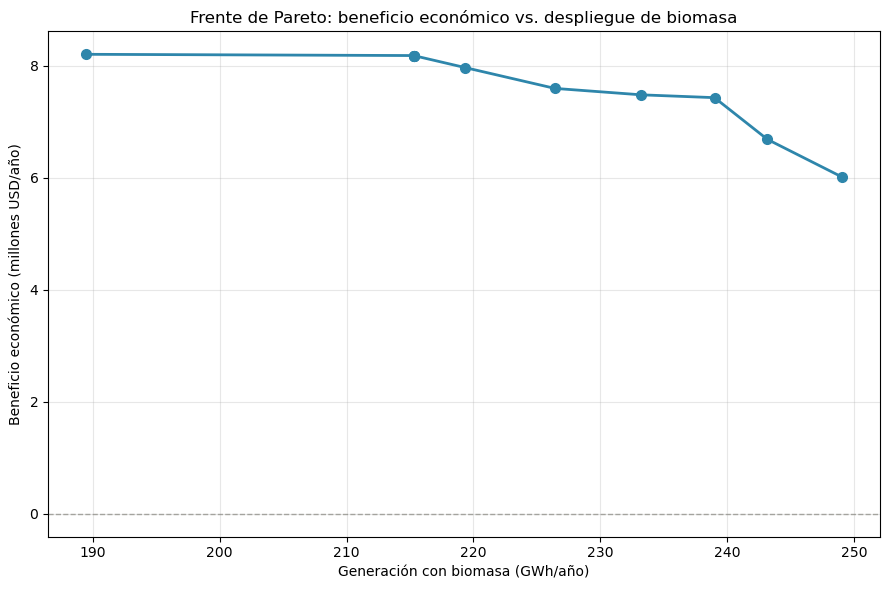

In [162]:
# ==========================================================
# Fase 2 - Multiobjetivo, Paso 2: ε-constraint  [AMPLIADO]
# Igual que antes, pero ahora también guarda el detalle POR PLANTA de
# cada punto del frente, necesario para calcular los indicadores de
# sostenibilidad (LCOE, emisiones, social) en la Sección 19.
# ==========================================================
q = 10  # número de intervalos

frente_pareto = []
detalle_plantas = []          # <-- NUEVO: una fila por (punto, planta)

for n in range(q + 1):
    epsilon = f2_en_f1max + n * (f2_max - f2_en_f1max) / q
    m_eps = construir_modelo_f2(objetivo='economico', restriccion_f2=epsilon)
    res = solver.solve(m_eps, tee=False)

    if res.solver.termination_condition == pyo.TerminationCondition.optimal:
        frente_pareto.append({
            'punto': n,
            'epsilon_GWh': epsilon / 1e6,
            'f1_beneficio_USD': pyo.value(m_eps.f1_economico),
            'f2_generacion_GWh': pyo.value(m_eps.f2_generacion) / 1e6,
            'factor_util_promedio': sum(pyo.value(m_eps.factor_utilizacion[p]) for p in plantas) / len(plantas),
            'factor_util_biogas_promedio': sum(pyo.value(m_eps.factor_util_biogas[p]) for p in plantas) / len(plantas),
            'capacidad_turbina_total_MW': sum(pyo.value(m_eps.capacidad_turbina_kW[p]) for p in plantas) / 1000,
            'capacidad_biogas_total_MW': sum(pyo.value(m_eps.capacidad_biogas_kW[p]) for p in plantas) / 1000,
        })

        # --- NUEVO: detalle por planta de este punto del frente ---
        for p in plantas:
            h = pyo.value(m_eps.horas[p])
            pot_turb = pyo.value(m_eps.potencia_turbina_kW[p])
            pot_bio  = pyo.value(m_eps.potencia_biogas_kW[p])
            autoc    = pyo.value(m_eps.autoconsumo_kW[p])
            exc_perm = pyo.value(m_eps.excedente_permuta_kW[p])
            exc_bols = pyo.value(m_eps.excedente_bolsa_kW[p])

            detalle_plantas.append({
                'punto': n,
                'planta': p,
                'horas': h,
                'cap_turbina_kW': pyo.value(m_eps.capacidad_turbina_kW[p]),
                'cap_biogas_kW': pyo.value(m_eps.capacidad_biogas_kW[p]),
                'generacion_kWh': (pot_turb + pot_bio) * h,     # electricidad total producida
                'autoconsumo_kWh': autoc * h,                   # sustituye compra de red
                'excedente_kWh': (exc_perm + exc_bols) * h,     # exportado a la red
            })

df_pareto = pd.DataFrame(frente_pareto)
df_pareto_plantas = pd.DataFrame(detalle_plantas)   # <-- NUEVO

print(df_pareto.to_string(index=False))
df_pareto.to_csv('frente_pareto_economico_generacion.csv', index=False)
df_pareto_plantas.to_csv('frente_pareto_detalle_plantas_esc1.csv', index=False)

# --- Gráfico del frente de Pareto (sin cambios) ---
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(df_pareto['f2_generacion_GWh'], df_pareto['f1_beneficio_USD']/1e6, 'o-',
        color='#2E86AB', linewidth=2, markersize=7)
ax.axhline(0, color='#888780', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Generación con biomasa (GWh/año)')
ax.set_ylabel('Beneficio económico (millones USD/año)')
ax.set_title('Frente de Pareto: beneficio económico vs. despliegue de biomasa')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('frente_pareto.png', dpi=150)
plt.show()

### 16.4 Diagnóstico — elección del solver (turbina vs. biogás)

In [163]:
def reporte_eleccion_esc1(m, etiqueta):
    print(f"--- {etiqueta} ---")
    for p in plantas:
        tam_turb = [k for k in CATALOGO_TURBINA_ESC1 if pyo.value(m.z[p, k]) > 0.5][0]
        n_unid = pyo.value(m.n_unidades_biogas[p])
        fu_turb = pyo.value(m.factor_utilizacion[p])
        fu_bio = pyo.value(m.factor_util_biogas[p])
        print(f"{p}: turbina={tam_turb:,} kW (FU={fu_turb:.3f}) | "
              f"biogás={n_unid:.0f} unidades (FU={fu_bio:.3f})")
    print()

reporte_eleccion_esc1(m1, "Óptimo económico (f1 max)")
reporte_eleccion_esc1(m2, "Óptimo generación (f2 max)")

--- Óptimo económico (f1 max) ---
Planta A: turbina=7,000 kW (FU=0.931) | biogás=2 unidades (FU=1.000)
Planta B: turbina=9,000 kW (FU=1.000) | biogás=4 unidades (FU=1.000)
Planta C: turbina=7,000 kW (FU=1.000) | biogás=3 unidades (FU=1.000)
Planta D: turbina=300 kW (FU=0.058) | biogás=3 unidades (FU=1.000)
Planta E: turbina=300 kW (FU=0.042) | biogás=3 unidades (FU=1.000)
Planta F: turbina=300 kW (FU=0.061) | biogás=2 unidades (FU=1.000)

--- Óptimo generación (f2 max) ---
Planta A: turbina=10,000 kW (FU=1.000) | biogás=2 unidades (FU=1.000)
Planta B: turbina=10,000 kW (FU=1.000) | biogás=4 unidades (FU=1.000)
Planta C: turbina=10,000 kW (FU=1.000) | biogás=3 unidades (FU=1.000)
Planta D: turbina=10,000 kW (FU=1.000) | biogás=3 unidades (FU=1.000)
Planta E: turbina=10,000 kW (FU=1.000) | biogás=3 unidades (FU=1.000)
Planta F: turbina=10,000 kW (FU=1.000) | biogás=2 unidades (FU=1.000)



### 16.5 CAPEX fijo y beneficio neto total

CAPEX fijo anualizado TOTAL Esc.1 (6 plantas): $3,335,578 USD/año

 f2_generacion_GWh  f1_beneficio_USD  f1_beneficio_neto_total_USD
        189.454778      8.202233e+06                 4.866656e+06
        215.285978      8.179939e+06                 4.844362e+06
        215.285978      8.179939e+06                 4.844362e+06
        215.285978      8.179939e+06                 4.844362e+06
        215.285978      8.179939e+06                 4.844362e+06
        219.341410      7.965642e+06                 4.630064e+06
        226.422160      7.593627e+06                 4.258050e+06
        233.223878      7.478920e+06                 4.143342e+06
        239.010160      7.428395e+06                 4.092817e+06
        243.184767      6.682865e+06                 3.347287e+06
        249.077037      6.009831e+06                 2.674253e+06


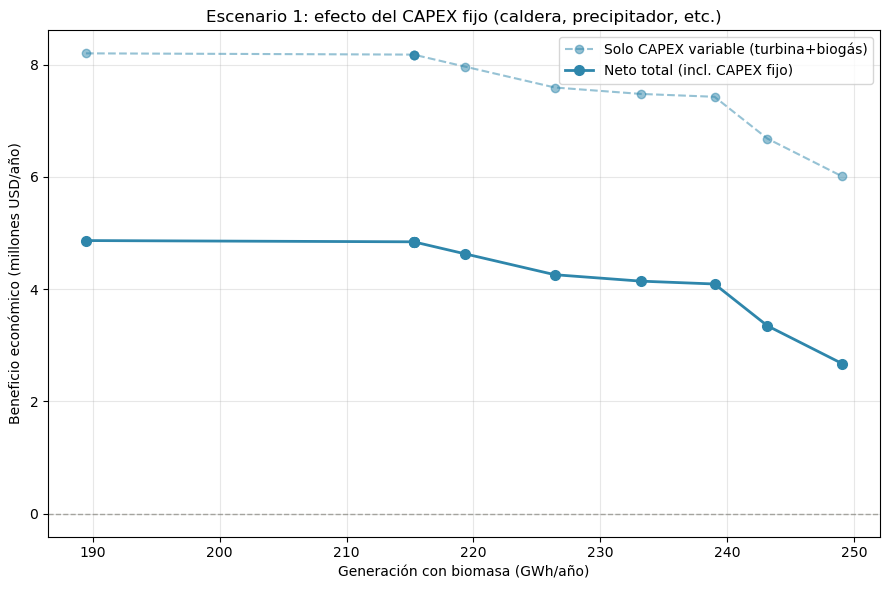

In [164]:
# Reutiliza capex_incremental_esc1(planta) (Sección 15), excluyendo turbina 
# y generador de biogás (ambos ya están modelados como variables en el 
# solver de Fase 2 — si no se excluyen, se contarían dos veces).
def capex_fijo_esc1(planta):
    items = capex_incremental_esc1(planta)
    excluir = {'Turbina', 'Generador de biogás'}   # claves de capex_incremental_esc1 (Sección 15.0)
    return sum(v for k, v in items.items() if k not in excluir)

capex_fijo_esc1_dict = {p: capex_fijo_esc1(p) for p in plantas}
capex_fijo_anualizado_total_esc1 = sum(capex_fijo_esc1_dict[p] / PVAF for p in plantas)
print(f"CAPEX fijo anualizado TOTAL Esc.1 (6 plantas): ${capex_fijo_anualizado_total_esc1:,.0f} USD/año\n")

df_pareto['f1_beneficio_neto_total_USD'] = df_pareto['f1_beneficio_USD'] - capex_fijo_anualizado_total_esc1
print(df_pareto[['f2_generacion_GWh', 'f1_beneficio_USD', 'f1_beneficio_neto_total_USD']].to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(df_pareto['f2_generacion_GWh'], df_pareto['f1_beneficio_USD']/1e6,
        'o--', color='#2E86AB', alpha=0.5, linewidth=1.5, markersize=6, label='Solo CAPEX variable (turbina+biogás)')
ax.plot(df_pareto['f2_generacion_GWh'], df_pareto['f1_beneficio_neto_total_USD']/1e6,
        'o-', color='#2E86AB', linewidth=2, markersize=7, label='Neto total (incl. CAPEX fijo)')
ax.axhline(0, color='#888780', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Generación con biomasa (GWh/año)')
ax.set_ylabel('Beneficio económico (millones USD/año)')
ax.set_title('Escenario 1: efecto del CAPEX fijo (caldera, precipitador, etc.)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('escenario1_capex_fijo_efecto.png', dpi=150)
plt.show()


## Sección 16.6

In [230]:
# ==========================================================
# Sección 16.6 - Indicadores de sostenibilidad en cada punto del frente de
# Pareto — ESCENARIO 1 (extracción-condensación + biogás POME).
# CAPEX leído de los catálogos escalados (regla 0.6), no lineal.
# LCOE sobre GENERACIÓN TOTAL.
# ==========================================================
def capex_variable_esc1(cap_turbina_kW, cap_biogas_kW):
    """CAPEX de los equipos que el solver dimensiona, con economías de escala.
    La turbina se busca en el catálogo; el biogás es N módulos de 1 MW."""
    capex_t = CAPEX_TURBINA_ESC1.get(int(round(cap_turbina_kW)), 0.0)
    n_unid  = int(round(cap_biogas_kW / TAMANO_UNIDAD_BIOGAS_KW))
    return capex_t + n_unid * CAPEX_UNIDAD_BIOGAS

filas = []
for n in sorted(df_pareto_plantas['punto'].unique()):
    sub = df_pareto_plantas[df_pareto_plantas['punto'] == n]
    generacion_kWh = sub['generacion_kWh'].sum()
    excedente_kWh  = sub['excedente_kWh'].sum()

    # CAPEX variable: PLANTA POR PLANTA (el escalamiento 0.6 no es aditivo)
    capex_variable = sum(capex_variable_esc1(r['cap_turbina_kW'], r['cap_biogas_kW'])
                         for _, r in sub.iterrows())
    capex_fijo  = sum(capex_fijo_esc1_dict[p] for p in plantas)
    capex_total = capex_fijo + capex_variable

    lcoe = (capex_total / PVAF + PCT_OPERACION_ANUAL * capex_total) / generacion_kWh
    filas.append({
        'punto': n,
        'generacion_GWh': generacion_kWh / 1e6,
        'excedente_GWh': excedente_kWh / 1e6,
        'capex_total_MUSD': capex_total / 1e6,
        'lcoe_USD_kWh': lcoe,
        'emisiones_evitadas_tCO2': excedente_kWh * FACTOR_RED_NACIONAL / 1000,
        'viviendas_rurales': viviendas_rurales_beneficiadas(excedente_kWh),
    })

df_sost = pd.DataFrame(filas)
df_sost = df_sost.merge(df_pareto[['punto', 'f1_beneficio_USD']], on='punto', how='left')
df_sost['beneficio_neto_total_USD'] = df_sost['f1_beneficio_USD'] - capex_fijo_anualizado_total_esc1
df_sost['pct_cobertura_rural']       = (df_sost['excedente_GWh'] / DEMANDA_RESIDENCIAL_RURAL_GWh) * 100
df_sost['viviendas_rurales_techo']   = df_sost['viviendas_rurales'].clip(upper=USUARIOS_RURALES)
df_sost['pct_demanda_departamental'] = (df_sost['excedente_GWh'] / DEMANDA_TOTAL_DEPARTAMENTAL_GWh) * 100

n_antes = len(df_sost)
df_sost = df_sost.drop_duplicates(subset='generacion_GWh', keep='first').reset_index(drop=True)

print(f"Indicadores de sostenibilidad — ESCENARIO 1")
print(f"({len(df_sost)} puntos únicos de {n_antes} valores de ε; "
      f"los duplicados son huecos del frente por discretización del catálogo)\n")
print(df_sost[['generacion_GWh', 'excedente_GWh', 'beneficio_neto_total_USD',
               'lcoe_USD_kWh', 'emisiones_evitadas_tCO2',
               'pct_cobertura_rural', 'pct_demanda_departamental']].to_string(index=False))
df_sost.to_csv('indicadores_sostenibilidad_pareto_esc1.csv', index=False)

Indicadores de sostenibilidad — ESCENARIO 1
(8 puntos únicos de 11 valores de ε; los duplicados son huecos del frente por discretización del catálogo)

 generacion_GWh  excedente_GWh  beneficio_neto_total_USD  lcoe_USD_kWh  emisiones_evitadas_tCO2  pct_cobertura_rural  pct_demanda_departamental
     189.454778     170.045131              4.866656e+06      0.071495             27785.374457           561.205054                   6.997742
     215.285978     195.876331              4.844362e+06      0.070393             32006.192537           646.456539                   8.060754
     219.341410     199.931763              4.630064e+06      0.071231             32668.850155           659.840804                   8.227645
     226.422160     207.012513              4.258050e+06      0.072628             33825.844705           683.209615                   8.519033
     233.223878     213.814231              4.143342e+06      0.072859             34937.245397           705.657529            

## Sección 17 — Fase 2 (superestructura), Escenario 2: turbina contrapresión + biogás POME+EFB pretratado

### 17.1 Parámetros, catálogos y CAPEX fijo

In [183]:
# ==========================================================
# Sección 17 - Fase 2, Escenario 2: catálogo de turbina contrapresión 
# (single unit) + generador de biogás como N unidades modulares de 
# 1,000 kW c/u (estándar de industria: motogeneradores biogás POME 
# se instalan en módulos de ~1 MW).
# ==========================================================
# CATALOGO_TURBINA_CONTRAPRESION, CAPEX_TURBINA_ESC2, CAPEX_UNIDAD_BIOGAS,
# TAMANO_UNIDAD_BIOGAS_KW y N_MAX_UNIDADES_BIOGAS se definen en la Sección 15.0.
# TAMANO_UNIDAD_BIOGAS_KW y N_MAX_UNIDADES_BIOGAS ya se definieron en la
# Sección 16.1 (mismo criterio de módulos de ~1 MW para ambos escenarios).

potencia_ideal_turbina_esc2_dict = {p: potencia_turbina_esc2_kW(p)['potencia_bruta_kW'] for p in plantas}
potencia_ideal_biogas_esc2_dict = {p: biogas_pome_y_efb_esc2(p)['generacion_bruta_kW'] for p in plantas}
consumo_medido_esc2_dict = {p: consumo_electrico_esc2_kW(p) for p in plantas}

def capex_fijo_esc2(planta):
    """CAPEX que NO depende de la capacidad eléctrica elegida por el solver.
    Excluye turbina y generador de biogás (son variables de decisión en Fase 2).
    Se reutiliza capex_incremental_esc2 (Sección 15.0, ya escalado con la regla 0.6)
    para no duplicar la lógica de costos."""
    items = capex_incremental_esc2(planta)
    excluir = {'Turbina', 'Generador de biogás'}
    return sum(v for k, v in items.items() if k not in excluir)

capex_fijo_esc2_dict = {p: capex_fijo_esc2(p) for p in plantas}
capex_fijo_anualizado_total = sum(capex_fijo_esc2_dict[p] / PVAF for p in plantas)

print("CAPEX fijo Escenario 2 (USD, no depende de la capacidad eléctrica elegida):")
for p in plantas:
    print(f"  {p}: ${capex_fijo_esc2_dict[p]:,.0f}")
print(f"\nCAPEX fijo anualizado TOTAL Esc.2 (6 plantas): ${capex_fijo_anualizado_total:,.0f} USD/año")


CAPEX fijo Escenario 2 (USD, no depende de la capacidad eléctrica elegida):
  Planta A: $3,191,371
  Planta B: $3,835,111
  Planta C: $3,189,431
  Planta D: $2,765,635
  Planta E: $3,222,863
  Planta F: $2,469,586

CAPEX fijo anualizado TOTAL Esc.2 (6 plantas): $2,193,441 USD/año


### 17.2 Modelo (turbina contrapresión + N unidades biogás) y payoff table

In [184]:
# ==========================================================
# Sección 17 - Fase 2, Escenario 2: turbina de contrapresión (catálogo)
# + generador de biogás (N unidades de 1,000 kW). Payoff table lexicográfica.
# f1 incluye: CAPEX anualizado + O&M (2.5%) + costo de oportunidad de la
# biomasa quemada (escala con el factor de utilización de la turbina).
# ==========================================================
def construir_modelo_f2_esc2(objetivo='economico', restriccion_f2=None, restriccion_f1=None):
    m = pyo.ConcreteModel()
    m.PLANTAS = pyo.Set(initialize=plantas)
    m.TAM_TURBINA = pyo.Set(initialize=CATALOGO_TURBINA_CONTRAPRESION)

    m.potencia_ideal_turbina = pyo.Param(m.PLANTAS, initialize=potencia_ideal_turbina_esc2_dict)
    m.potencia_ideal_biogas = pyo.Param(m.PLANTAS, initialize=potencia_ideal_biogas_esc2_dict)
    m.consumo_medido_kW = pyo.Param(m.PLANTAS, initialize=consumo_medido_esc2_dict)
    m.horas = pyo.Param(m.PLANTAS, initialize=horas_operacion_anual)
    m.costo_oport = pyo.Param(m.PLANTAS, initialize=costo_oport_dict)
    m.precio_tramo12 = pyo.Param(m.PLANTAS, initialize=PRECIO_TRAMO_12_dict)
    m.precio_bolsa = pyo.Param(initialize=PRECIO_BOLSA_PROMEDIO)
    m.pvaf = pyo.Param(initialize=PVAF)

    m.z_turb = pyo.Var(m.PLANTAS, m.TAM_TURBINA, domain=pyo.Binary)
    m.n_unidades_biogas = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeIntegers, bounds=(0, N_MAX_UNIDADES_BIOGAS))
    m.capacidad_turbina_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.capacidad_biogas_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.factor_util_turbina = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals, bounds=(0, 1))
    m.factor_util_biogas = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals, bounds=(0, 1))
    m.potencia_turbina_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.potencia_biogas_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.autoconsumo_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.excedente_permuta_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.excedente_bolsa_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)

    m.r_una_turb = pyo.Constraint(m.PLANTAS, rule=lambda m, p: sum(m.z_turb[p, k] for k in m.TAM_TURBINA) == 1)
    m.r_cap_turb = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.capacidad_turbina_kW[p] == sum(k*m.z_turb[p, k] for k in m.TAM_TURBINA))
    m.r_cap_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.capacidad_biogas_kW[p] == m.n_unidades_biogas[p] * TAMANO_UNIDAD_BIOGAS_KW)
    m.r_pot_turb = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_turbina_kW[p] == m.factor_util_turbina[p]*m.potencia_ideal_turbina[p])
    m.r_pot_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_biogas_kW[p] == m.factor_util_biogas[p]*m.potencia_ideal_biogas[p])
    m.r_no_exc_turb = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_turbina_kW[p] <= m.capacidad_turbina_kW[p])
    m.r_no_exc_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_biogas_kW[p] <= m.capacidad_biogas_kW[p])
    m.r_reparto = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_turbina_kW[p] + m.potencia_biogas_kW[p]
                                 == m.autoconsumo_kW[p] + m.excedente_permuta_kW[p] + m.excedente_bolsa_kW[p])
    m.r_tope_auto = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.autoconsumo_kW[p] <= m.consumo_medido_kW[p])
    m.r_tope_permuta = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.excedente_permuta_kW[p] <= m.consumo_medido_kW[p])

    m.f1_economico = pyo.Expression(expr=(
        sum(m.autoconsumo_kW[p]*m.horas[p]*m.precio_tramo12[p] for p in m.PLANTAS)
        + sum(m.excedente_permuta_kW[p]*m.horas[p]*m.precio_tramo12[p] for p in m.PLANTAS)
        + sum(m.excedente_bolsa_kW[p]*m.horas[p]*m.precio_bolsa for p in m.PLANTAS)
        - sum(sum(CAPEX_TURBINA_ESC2[k]*m.z_turb[p, k] for k in m.TAM_TURBINA)/m.pvaf for p in m.PLANTAS)
        - sum(m.n_unidades_biogas[p]*CAPEX_UNIDAD_BIOGAS/m.pvaf for p in m.PLANTAS)
        - sum(sum(CAPEX_TURBINA_ESC2[k]*m.z_turb[p, k] for k in m.TAM_TURBINA)*PCT_OPERACION_ANUAL for p in m.PLANTAS)
        - sum(m.n_unidades_biogas[p]*CAPEX_UNIDAD_BIOGAS*PCT_OPERACION_ANUAL for p in m.PLANTAS)
        - sum(m.factor_util_turbina[p]*m.costo_oport[p] for p in m.PLANTAS)))

    m.f2_generacion = pyo.Expression(expr=sum((m.potencia_turbina_kW[p] + m.potencia_biogas_kW[p])*m.horas[p] for p in m.PLANTAS))

    if restriccion_f1 is not None:
        m.r_eps_f1 = pyo.Constraint(expr=m.f1_economico >= restriccion_f1)
    if restriccion_f2 is not None:
        m.r_eps_f2 = pyo.Constraint(expr=m.f2_generacion >= restriccion_f2)

    if objetivo == 'economico':
        m.obj = pyo.Objective(expr=m.f1_economico, sense=pyo.maximize)
    else:
        m.obj = pyo.Objective(expr=m.f2_generacion, sense=pyo.maximize)
    return m


# --- Payoff table lexicográfica ---
m1_e2 = construir_modelo_f2_esc2(objetivo='economico'); solver.solve(m1_e2)
f1_max_e2 = pyo.value(m1_e2.f1_economico)
m1b_e2 = construir_modelo_f2_esc2(objetivo='generacion', restriccion_f1=f1_max_e2 - 1.0); solver.solve(m1b_e2)
f2_en_f1max_e2 = pyo.value(m1b_e2.f2_generacion)

m2_e2 = construir_modelo_f2_esc2(objetivo='generacion'); solver.solve(m2_e2)
f2_max_e2 = pyo.value(m2_e2.f2_generacion)
m2b_e2 = construir_modelo_f2_esc2(objetivo='economico', restriccion_f2=f2_max_e2 - 100.0); solver.solve(m2b_e2)
f1_en_f2max_e2 = pyo.value(m2b_e2.f1_economico)

print("=== PAYOFF TABLE Escenario 2 (lexicográfica, biogás por N unidades) ===\n")
print(f"{'':22} {'f1: Beneficio (USD/año)':>26} {'f2: Generación (GWh/año)':>26}")
print(f"{'Óptimo económico':22} {f1_max_e2:>26,.0f} {f2_en_f1max_e2/1e6:>26,.1f}")
print(f"{'Óptimo generación':22} {f1_en_f2max_e2:>26,.0f} {f2_max_e2/1e6:>26,.1f}")
print()
print(f"Rango f1: {f1_max_e2 - f1_en_f2max_e2:,.0f} USD/año")
print(f"Rango f2: {(f2_max_e2 - f2_en_f1max_e2)/1e6:,.1f} GWh/año")

=== PAYOFF TABLE Escenario 2 (lexicográfica, biogás por N unidades) ===

                          f1: Beneficio (USD/año)   f2: Generación (GWh/año)
Óptimo económico                        9,902,091                      147.5
Óptimo generación                       8,995,254                      161.6

Rango f1: 906,837 USD/año
Rango f2: 14.1 GWh/año


### 17.3 ε-constraint (q=10), frente de Pareto y comparación en paneles

In [185]:
# ==========================================================
# Fase 2 - Escenario 2, Paso 2: ε-constraint  [AMPLIADO]
# Guarda además el detalle POR PLANTA de cada punto del frente,
# necesario para los indicadores de sostenibilidad (Sección 19 bis).
# ==========================================================
q = 10

frente_pareto_e2 = []
detalle_plantas_e2 = []

for n in range(q + 1):
    epsilon = f2_en_f1max_e2 + n * (f2_max_e2 - f2_en_f1max_e2) / q
    m_eps = construir_modelo_f2_esc2(objetivo='economico', restriccion_f2=epsilon)
    res = solver.solve(m_eps, tee=False)

    if res.solver.termination_condition == pyo.TerminationCondition.optimal:
        frente_pareto_e2.append({
            'punto': n,
            'epsilon_GWh': epsilon / 1e6,
            'f1_beneficio_USD': pyo.value(m_eps.f1_economico),
            'f2_generacion_GWh': pyo.value(m_eps.f2_generacion) / 1e6,
            'factor_util_promedio': sum(pyo.value(m_eps.factor_util_turbina[p]) for p in plantas) / len(plantas),
            'factor_util_biogas_promedio': sum(pyo.value(m_eps.factor_util_biogas[p]) for p in plantas) / len(plantas),
            'capacidad_turbina_total_MW': sum(pyo.value(m_eps.capacidad_turbina_kW[p]) for p in plantas) / 1000,
            'capacidad_biogas_total_MW': sum(pyo.value(m_eps.capacidad_biogas_kW[p]) for p in plantas) / 1000,
        })

        for p in plantas:
            h = pyo.value(m_eps.horas[p])
            pot_turb = pyo.value(m_eps.potencia_turbina_kW[p])
            pot_bio  = pyo.value(m_eps.potencia_biogas_kW[p])
            exc_perm = pyo.value(m_eps.excedente_permuta_kW[p])
            exc_bols = pyo.value(m_eps.excedente_bolsa_kW[p])

            detalle_plantas_e2.append({
                'punto': n,
                'planta': p,
                'horas': h,
                'cap_turbina_kW': pyo.value(m_eps.capacidad_turbina_kW[p]),
                'cap_biogas_kW': pyo.value(m_eps.capacidad_biogas_kW[p]),
                'generacion_kWh': (pot_turb + pot_bio) * h,
                'autoconsumo_kWh': pyo.value(m_eps.autoconsumo_kW[p]) * h,
                'excedente_kWh': (exc_perm + exc_bols) * h,
            })

df_pareto_e2 = pd.DataFrame(frente_pareto_e2)
df_pareto_plantas_e2 = pd.DataFrame(detalle_plantas_e2)

print(df_pareto_e2.to_string(index=False))
df_pareto_e2.to_csv('frente_pareto_economico_generacion_esc2.csv', index=False)
df_pareto_plantas_e2.to_csv('frente_pareto_detalle_plantas_esc2.csv', index=False)

 punto  epsilon_GWh  f1_beneficio_USD  f2_generacion_GWh  factor_util_promedio  factor_util_biogas_promedio  capacidad_turbina_total_MW  capacidad_biogas_total_MW
     0   147.476939      9.902092e+06         147.476939              0.624845                     0.992342                    4.500006                       29.0
     1   148.891191      9.852040e+06         148.956903              0.658711                     0.992342                    4.750000                       29.0
     2   150.305443      9.807534e+06         150.320216              0.689908                     0.992342                    5.000000                       29.0
     3   151.719696      9.725917e+06         151.931866              0.728828                     0.994125                    5.250000                       30.0
     4   153.133948      9.677957e+06         153.135366              0.742801                     0.994125                    5.500000                       30.0
     5   154.548201   

## 17.4 Indicadores de sostenibilidad

In [229]:
# ==========================================================
# Sección 17.4 - Indicadores de sostenibilidad en cada punto del
# frente de Pareto — ESCENARIO 2 (contrapresión + biogás POME/EFB).
# CAPEX leído de los catálogos escalados (regla 0.6), no lineal.
# LCOE sobre GENERACIÓN TOTAL (misma convención que Escenario 1).
# ==========================================================
def capex_variable_esc2(cap_turbina_kW, cap_biogas_kW):
    """CAPEX de los equipos que el solver dimensiona, con economías de escala.
    La turbina se busca en el catálogo; el biogás es N módulos de 1 MW."""
    capex_t = CAPEX_TURBINA_ESC2.get(int(round(cap_turbina_kW)), 0.0)
    n_unid  = int(round(cap_biogas_kW / TAMANO_UNIDAD_BIOGAS_KW))
    return capex_t + n_unid * CAPEX_UNIDAD_BIOGAS

filas = []
for n in sorted(df_pareto_plantas_e2['punto'].unique()):
    sub = df_pareto_plantas_e2[df_pareto_plantas_e2['punto'] == n]
    generacion_kWh = sub['generacion_kWh'].sum()
    excedente_kWh  = sub['excedente_kWh'].sum()

    # CAPEX variable: se suma PLANTA POR PLANTA (el escalamiento no es aditivo)
    capex_variable = sum(capex_variable_esc2(r['cap_turbina_kW'], r['cap_biogas_kW'])
                         for _, r in sub.iterrows())
    capex_fijo  = sum(capex_fijo_esc2_dict[p] for p in plantas)
    capex_total = capex_fijo + capex_variable

    lcoe = (capex_total / PVAF + PCT_OPERACION_ANUAL * capex_total) / generacion_kWh
    filas.append({
        'punto': n,
        'generacion_GWh': generacion_kWh / 1e6,
        'excedente_GWh': excedente_kWh / 1e6,
        'capex_total_MUSD': capex_total / 1e6,
        'lcoe_USD_kWh': lcoe,
        'emisiones_evitadas_tCO2': excedente_kWh * FACTOR_RED_NACIONAL / 1000,
        'viviendas_rurales': viviendas_rurales_beneficiadas(excedente_kWh),
    })

df_sost_e2 = pd.DataFrame(filas)
df_sost_e2 = df_sost_e2.merge(df_pareto_e2[['punto', 'f1_beneficio_USD']], on='punto', how='left')
df_sost_e2['beneficio_neto_total_USD'] = df_sost_e2['f1_beneficio_USD'] - capex_fijo_anualizado_total
df_sost_e2['pct_cobertura_rural']       = (df_sost_e2['excedente_GWh'] / DEMANDA_RESIDENCIAL_RURAL_GWh) * 100
df_sost_e2['viviendas_rurales_techo']   = df_sost_e2['viviendas_rurales'].clip(upper=USUARIOS_RURALES)
df_sost_e2['pct_demanda_departamental'] = (df_sost_e2['excedente_GWh'] / DEMANDA_TOTAL_DEPARTAMENTAL_GWh) * 100

n_antes = len(df_sost_e2)
df_sost_e2 = df_sost_e2.drop_duplicates(subset='generacion_GWh', keep='first').reset_index(drop=True)

print(f"Indicadores de sostenibilidad — ESCENARIO 2")
print(f"({len(df_sost_e2)} puntos únicos de {n_antes} valores de ε; "
      f"los duplicados son huecos del frente por discretización del catálogo)\n")
print(df_sost_e2[['generacion_GWh', 'excedente_GWh', 'beneficio_neto_total_USD',
                  'lcoe_USD_kWh', 'emisiones_evitadas_tCO2',
                  'pct_cobertura_rural', 'pct_demanda_departamental']].to_string(index=False))
df_sost_e2.to_csv('indicadores_sostenibilidad_pareto_esc2.csv', index=False)

Indicadores de sostenibilidad — ESCENARIO 2
(11 puntos únicos de 11 valores de ε; los duplicados son huecos del frente por discretización del catálogo)

 generacion_GWh  excedente_GWh  beneficio_neto_total_USD  lcoe_USD_kWh  emisiones_evitadas_tCO2  pct_cobertura_rural  pct_demanda_departamental
     147.476939     130.684279              7.708652e+06      0.046600             21353.811143           431.301250                   5.377954
     148.956903     132.164244              7.658599e+06      0.046751             21595.637391           436.185622                   5.438858
     150.320216     133.527556              7.614093e+06      0.046876             21818.402642           440.685003                   5.494961
     151.931866     135.139206              7.532476e+06      0.047276             22081.746333           446.003982                   5.561284
     153.135366     136.342706              7.484516e+06      0.047444             22278.398233           449.975929           

### 17.4 Diagnóstico — elección del solver

In [190]:
# ==========================================================
# Sección 17 - Bloque 4: diagnóstico — ¿cuántas unidades de biogás 
# elige el solver? ¿alguna planta necesita fracción de unidad 
# (sobre-dimensionamiento por indivisibilidad)?
# ==========================================================
def reporte_eleccion(m, etiqueta):
    print(f"--- {etiqueta} ---")
    for p in plantas:
        tam_turb = [k for k in CATALOGO_TURBINA_CONTRAPRESION if pyo.value(m.z_turb[p, k]) > 0.5][0]
        n_unid = pyo.value(m.n_unidades_biogas[p])
        cap_bio = n_unid * TAMANO_UNIDAD_BIOGAS_KW
        fu_turb = pyo.value(m.factor_util_turbina[p])
        fu_bio = pyo.value(m.factor_util_biogas[p])
        print(f"{p}: turbina={tam_turb:,} kW (FU={fu_turb:.3f}) | "
              f"biogás={n_unid:.0f} unidades ({cap_bio:,.0f} kW, FU={fu_bio:.3f})")
    print()

reporte_eleccion(m1_e2, "Óptimo económico (f1 max)")
reporte_eleccion(m2_e2, "Óptimo generación (f2 max)")

--- Óptimo económico (f1 max) ---
Planta A: turbina=750 kW (FU=0.559) | biogás=5 unidades (5,000 kW, FU=1.000)
Planta B: turbina=750 kW (FU=0.476) | biogás=7 unidades (7,000 kW, FU=1.000)
Planta C: turbina=750 kW (FU=0.610) | biogás=5 unidades (5,000 kW, FU=1.000)
Planta D: turbina=750 kW (FU=0.701) | biogás=4 unidades (4,000 kW, FU=0.989)
Planta E: turbina=750 kW (FU=0.640) | biogás=5 unidades (5,000 kW, FU=0.996)
Planta F: turbina=750 kW (FU=0.764) | biogás=3 unidades (3,000 kW, FU=0.969)

--- Óptimo generación (f2 max) ---
Planta A: turbina=1,750 kW (FU=1.000) | biogás=5 unidades (5,000 kW, FU=1.000)
Planta B: turbina=1,750 kW (FU=1.000) | biogás=7 unidades (7,000 kW, FU=1.000)
Planta C: turbina=1,750 kW (FU=1.000) | biogás=5 unidades (5,000 kW, FU=1.000)
Planta D: turbina=1,750 kW (FU=1.000) | biogás=5 unidades (5,000 kW, FU=1.000)
Planta E: turbina=1,750 kW (FU=1.000) | biogás=6 unidades (6,000 kW, FU=1.000)
Planta F: turbina=1,750 kW (FU=1.000) | biogás=4 unidades (4,000 kW, FU=1

### 17.5 Verificación — consistencia FU_biogás vs. ideal/capacidad

In [191]:
print(f"{'Planta':10} {'ideal_biogas_kW':>16} {'n_unidades':>12} {'capacidad_kW':>14} {'potencia_kW':>14} {'FU_reportado':>14}")
for p in plantas:
    ideal = potencia_ideal_biogas_esc2_dict[p]
    n_unid = pyo.value(m1_e2.n_unidades_biogas[p])
    cap = n_unid * TAMANO_UNIDAD_BIOGAS_KW
    pot = pyo.value(m1_e2.potencia_biogas_kW[p])
    fu = pyo.value(m1_e2.factor_util_biogas[p])
    print(f"{p:10} {ideal:>16,.1f} {n_unid:>12.0f} {cap:>14,.0f} {pot:>14,.1f} {fu:>14.3f}")

Planta      ideal_biogas_kW   n_unidades   capacidad_kW    potencia_kW   FU_reportado
Planta A            4,444.6            5          5,000        4,444.6          1.000
Planta B            6,449.0            7          7,000        6,449.0          1.000
Planta C            4,723.8            5          5,000        4,723.8          1.000
Planta D            4,043.2            4          4,000        4,000.0          0.989
Planta E            5,021.0            5          5,000        5,000.0          0.996
Planta F            3,096.2            3          3,000        3,000.0          0.969


### 17.6 CAPEX fijo y beneficio neto total

CAPEX fijo anualizado TOTAL (6 plantas): $2,193,441 USD/año

 f2_generacion_GWh  f1_beneficio_USD  f1_beneficio_neto_total_USD
        147.476939      9.902092e+06                 7.708652e+06
        148.956903      9.852040e+06                 7.658599e+06
        150.320216      9.807534e+06                 7.614093e+06
        151.931866      9.725917e+06                 7.532476e+06
        153.135366      9.677957e+06                 7.484516e+06
        155.560466      9.612650e+06                 7.419209e+06
        156.738966      9.560479e+06                 7.367039e+06
        158.112966      9.506979e+06                 7.313538e+06
        158.899716      9.437984e+06                 7.244543e+06
        160.253749      9.250590e+06                 7.057149e+06
        161.619463      8.995254e+06                 6.801813e+06


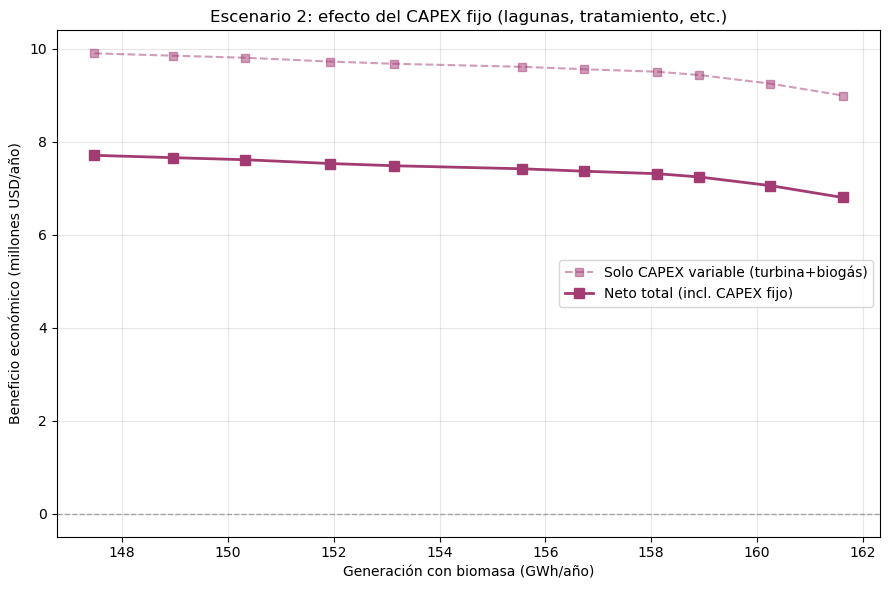

In [192]:
# ==========================================================
# Sección 17 - Bloque 5: beneficio NETO TOTAL (incluye CAPEX fijo 
# anualizado) para comparación justa con Escenario 1
# ==========================================================
capex_fijo_anualizado_total = sum(capex_fijo_esc2_dict[p] / PVAF for p in plantas)
print(f"CAPEX fijo anualizado TOTAL (6 plantas): ${capex_fijo_anualizado_total:,.0f} USD/año\n")

df_pareto_e2['f1_beneficio_neto_total_USD'] = df_pareto_e2['f1_beneficio_USD'] - capex_fijo_anualizado_total
print(df_pareto_e2[['f2_generacion_GWh', 'f1_beneficio_USD', 'f1_beneficio_neto_total_USD']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(df_pareto_e2['f2_generacion_GWh'], df_pareto_e2['f1_beneficio_USD']/1e6,
        's--', color='#A23B72', alpha=0.5, linewidth=1.5, markersize=6, label='Solo CAPEX variable (turbina+biogás)')
ax.plot(df_pareto_e2['f2_generacion_GWh'], df_pareto_e2['f1_beneficio_neto_total_USD']/1e6,
        's-', color='#A23B72', linewidth=2, markersize=7, label='Neto total (incl. CAPEX fijo)')
ax.axhline(0, color='#888780', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Generación con biomasa (GWh/año)')
ax.set_ylabel('Beneficio económico (millones USD/año)')
ax.set_title('Escenario 2: efecto del CAPEX fijo (lagunas, tratamiento, etc.)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('escenario2_capex_fijo_efecto.png', dpi=150)
plt.show()

## Sección 18 — Comparación final: beneficio neto total, Escenario 1 vs. Escenario 2

*Panel para la Discusión del artículo — usa el beneficio NETO TOTAL (incluyendo CAPEX fijo) de ambos escenarios, calculado en 16.5 y 17.6.*

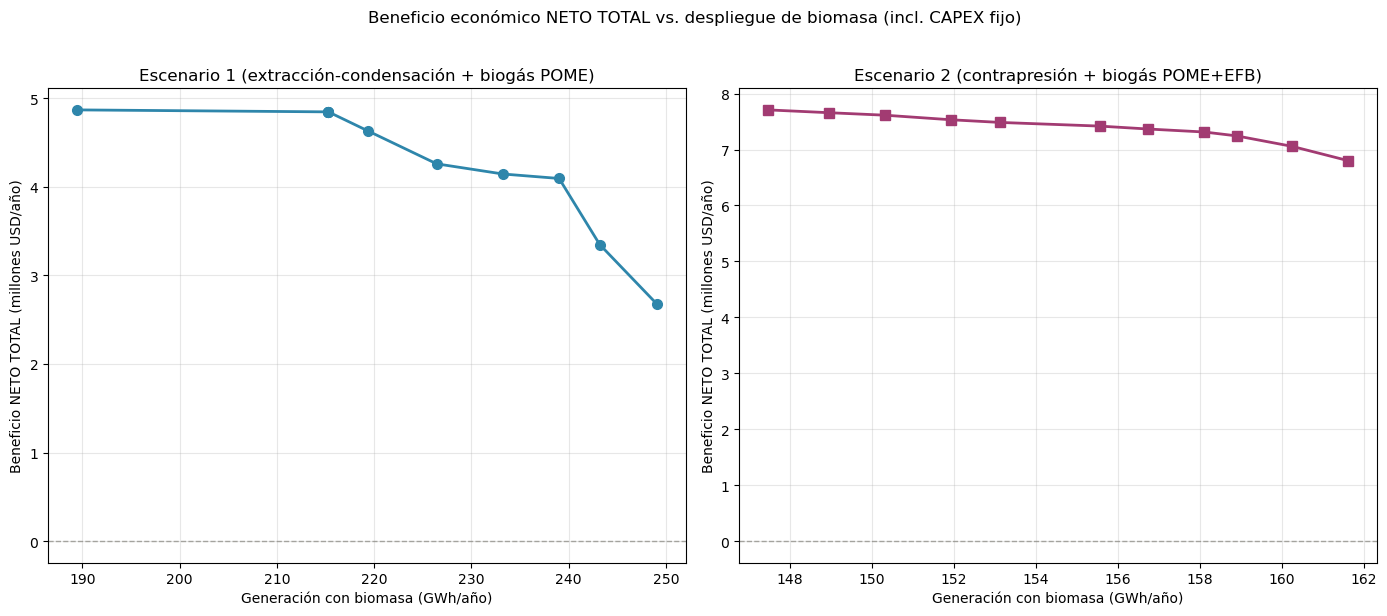

=== Resumen -- beneficio neto total (incl. CAPEX fijo) ===

Escenario 1: punto de equilibrio ~249.1 GWh -> 100.0% del potencial
Escenario 2: punto de equilibrio ~161.6 GWh -> 100.0% del potencial
Escenario 1:
  Óptimo económico     : 189.5 GWh (76% del potencial) -> $4.87M/año
  Despliegue 100%      : 249.1 GWh -> $2.67M/año
  Costo de desplegar todo: $2.19M/año (45% del óptimo)
  ¿Rentable en todo el frente?: SÍ (mínimo $2.67M)

Escenario 2:
  Óptimo económico     : 147.5 GWh (91% del potencial) -> $7.71M/año
  Despliegue 100%      : 161.6 GWh -> $6.80M/año
  Costo de desplegar todo: $0.91M/año (12% del óptimo)
  ¿Rentable en todo el frente?: SÍ (mínimo $6.80M)



In [233]:
# ==========================================================
# Sección 18 - Comparación final (beneficio NETO TOTAL, incluyendo
# CAPEX fijo) entre Escenario 1 y Escenario 2.
# ==========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

ax1.plot(df_pareto['f2_generacion_GWh'], df_pareto['f1_beneficio_neto_total_USD']/1e6,
          'o-', color='#2E86AB', linewidth=2, markersize=7)
ax1.axhline(0, color='#888780', linestyle='--', linewidth=1, alpha=0.7)
ax1.set_xlabel('Generación con biomasa (GWh/año)')
ax1.set_ylabel('Beneficio NETO TOTAL (millones USD/año)')
ax1.set_title('Escenario 1 (extracción-condensación + biogás POME)')
ax1.grid(alpha=0.3)

ax2.plot(df_pareto_e2['f2_generacion_GWh'], df_pareto_e2['f1_beneficio_neto_total_USD']/1e6,
          's-', color='#A23B72', linewidth=2, markersize=7)
ax2.axhline(0, color='#888780', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_xlabel('Generación con biomasa (GWh/año)')
ax2.set_ylabel('Beneficio NETO TOTAL (millones USD/año)')
ax2.set_title('Escenario 2 (contrapresión + biogás POME+EFB)')
ax2.grid(alpha=0.3)

fig.suptitle('Beneficio económico NETO TOTAL vs. despliegue de biomasa (incl. CAPEX fijo)', y=1.02)
plt.tight_layout()
plt.savefig('comparacion_final_neto_total_esc1_esc2.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Resumen de puntos de equilibrio ---
def punto_equilibrio_neto(df, col_f1='f1_beneficio_neto_total_USD', col_f2='f2_generacion_GWh'):
    df_pos = df[df[col_f1] >= 0]
    if df_pos.empty:
        return None
    return df_pos[col_f2].max()

eq1 = punto_equilibrio_neto(df_pareto)
eq2 = punto_equilibrio_neto(df_pareto_e2)
f2_max_gwh_e1 = df_pareto['f2_generacion_GWh'].max()
f2_max_gwh_e2 = df_pareto_e2['f2_generacion_GWh'].max()

print("=== Resumen -- beneficio neto total (incl. CAPEX fijo) ===\n")
if eq1 is not None:
    print(f"Escenario 1: punto de equilibrio ~{eq1:.1f} GWh -> {eq1/f2_max_gwh_e1*100:.1f}% del potencial")
else:
    print("Escenario 1: no se alcanza equilibrio (neto total negativo en todo el rango)")
if eq2 is not None:
    print(f"Escenario 2: punto de equilibrio ~{eq2:.1f} GWh -> {eq2/f2_max_gwh_e2*100:.1f}% del potencial")
else:
    print("Escenario 2: no se alcanza equilibrio (neto total negativo en todo el rango)")

    print("=== Frente de Pareto: rentabilidad en todo el rango ===\n")
for nombre, df in [('Escenario 1', df_sost), ('Escenario 2', df_sost_e2)]:
    ben = df['beneficio_neto_total_USD']
    i_opt = ben.idxmax()
    pct_opt = df.loc[i_opt, 'generacion_GWh'] / df['generacion_GWh'].max() * 100
    print(f"{nombre}:")
    print(f"  Óptimo económico     : {df.loc[i_opt,'generacion_GWh']:.1f} GWh ({pct_opt:.0f}% del potencial) "
          f"-> ${ben[i_opt]/1e6:.2f}M/año")
    print(f"  Despliegue 100%      : {df['generacion_GWh'].max():.1f} GWh "
          f"-> ${ben.iloc[-1]/1e6:.2f}M/año")
    print(f"  Costo de desplegar todo: ${(ben[i_opt]-ben.iloc[-1])/1e6:.2f}M/año "
          f"({100*(ben[i_opt]-ben.iloc[-1])/ben[i_opt]:.0f}% del óptimo)")
    print(f"  ¿Rentable en todo el frente?: {'SÍ' if ben.min() > 0 else 'NO'} "
          f"(mínimo ${ben.min()/1e6:.2f}M)\n")


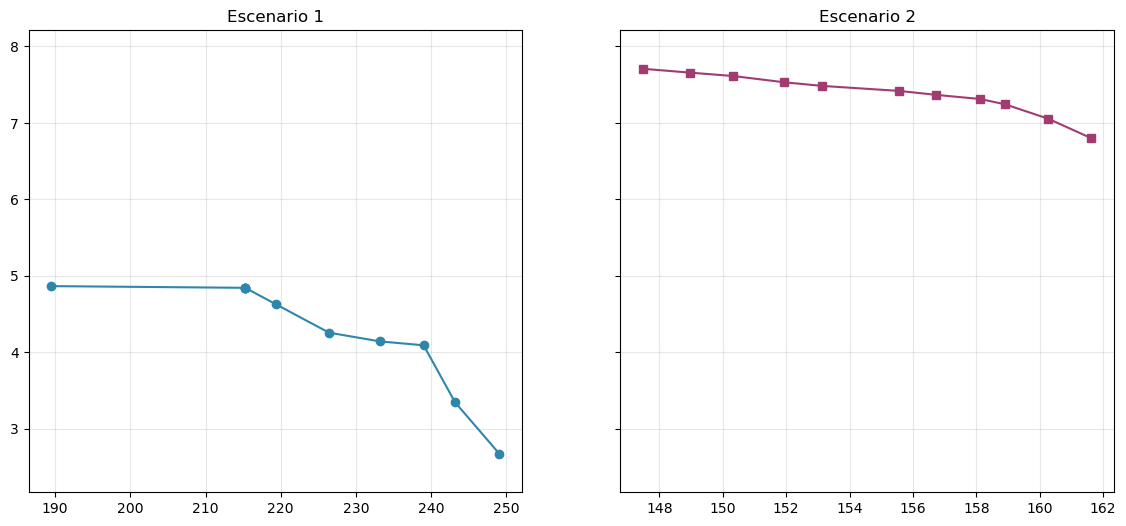

In [265]:
# 1. Definir un límite común para ambos ejes Y (usando el mínimo de ambos escenarios)
min_y = min(df_pareto['f1_beneficio_neto_total_USD'].min(), 
            df_pareto_e2['f1_beneficio_neto_total_USD'].min())
max_y = max(df_pareto['f1_beneficio_neto_total_USD'].max(), 
            df_pareto_e2['f1_beneficio_neto_total_USD'].max())

# Ajustamos para dar un margen de 10%
margin = (max_y - min_y) * 0.1
y_lims = (min_y - margin, max_y + margin)

# 2. Implementar subplots con sharey=True
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True) # <-- sharey=True es la clave

# Gráfico Escenario 1
ax1.plot(df_pareto['f2_generacion_GWh'], df_pareto['f1_beneficio_neto_total_USD']/1e6, 'o-', color='#2E86AB')
ax1.axhline(0, color='#888780', linestyle='--', linewidth=1)
ax1.set_ylim(y_lims[0]/1e6, y_lims[1]/1e6) # Aplicamos límites comunes
ax1.set_title('Escenario 1')
ax1.grid(alpha=0.3)

# Gráfico Escenario 2
ax2.plot(df_pareto_e2['f2_generacion_GWh'], df_pareto_e2['f1_beneficio_neto_total_USD']/1e6, 's-', color='#A23B72')
ax2.axhline(0, color='#888780', linestyle='--', linewidth=1)
# El eje Y se comparte automáticamente gracias a sharey=True
ax2.set_title('Escenario 2')
ax2.grid(alpha=0.3)

plt.show()

## Sección 19 - Sensibilidad de estacionalidad

## 19.1 Sensibilidad de estacionalidad

In [235]:
# ==========================================================
# Sección 19 - Sensibilidad de estacionalidad sobre las capacidades 
# elegidas en Fase 2 (óptimo económico, ambos escenarios). 
# Supuesto: el potencial de generación escala linealmente con el 
# Factor_estacionalidad del RFF procesado (Sección 12) — mismo supuesto 
# que sustenta el resto del modelo (energía biomasa ∝ tRFF procesado). 
# No recalcula termodinámica mes a mes; usa horas promedio mensuales 
# (horas_anuales/12), no un patrón de operación mensual real.
# ==========================================================
def perdida_estacional_v2(capacidad_instalada_kW, potencia_ideal_anual_kW, planta, horas_anuales):
    """Aísla la pérdida INCREMENTAL por estacionalidad, restando la línea 
    base sin estacionalidad (factor=1 todo el año) — evita confundir la 
    variabilidad mensual con el hueco estructural ya conocido entre 
    capacidad instalada e ideal anual (ese hueco ya está en el payoff table)."""
    horas_mes_prom = horas_anuales / 12
    df_p = df_rff_mensual[df_rff_mensual['Planta'] == planta]
    perdida_con_estacionalidad_kWh = 0
    for _, fila in df_p.iterrows():
        potencia_ideal_mes = potencia_ideal_anual_kW * fila['Factor_estacionalidad']
        exceso_kW = max(0, potencia_ideal_mes - capacidad_instalada_kW)
        perdida_con_estacionalidad_kWh += exceso_kW * horas_mes_prom

    # Línea base: mismo cálculo pero SIN estacionalidad (factor=1 todo el año)
    exceso_base_kW = max(0, potencia_ideal_anual_kW - capacidad_instalada_kW)
    perdida_base_kWh = exceso_base_kW * horas_anuales

    perdida_incremental_kWh = perdida_con_estacionalidad_kWh - perdida_base_kWh
    return perdida_incremental_kWh / 1e6  # GWh/año (puede ser ~0 si la capacidad ya está saturada todo el año)
    
# --- Escenario 1: capacidad elegida en el óptimo económico (m1) ---
print("=== Escenario 1 — pérdida estacional por capacidad fija (óptimo económico) ===\n")
perdida_total_e1 = 0
for p in plantas:
    tam_turb = [k for k in CATALOGO_TURBINA_ESC1 if pyo.value(m1.z[p, k]) > 0.5][0]
    cap_bio = pyo.value(m1.n_unidades_biogas[p]) * TAMANO_UNIDAD_BIOGAS_KW
    perdida_turb = perdida_estacional_v2(tam_turb, potencia_ideal_dict[p], p, horas_operacion_anual[p])
    perdida_bio = perdida_estacional_v2(cap_bio, potencia_ideal_biogas_esc1_dict[p], p, horas_operacion_anual[p])
    total_p = perdida_turb + perdida_bio
    perdida_total_e1 += total_p
    print(f"{p}: pérdida turbina={perdida_turb:.2f} GWh/año | pérdida biogás={perdida_bio:.2f} GWh/año | total={total_p:.2f} GWh/año")
print(f"\nTOTAL 6 plantas (Esc.1): {perdida_total_e1:.2f} GWh/año perdidos por capacidad fija en meses pico")
print(f"Referencia: generación en óptimo económico Esc.1 = {f2_en_f1max/1e6:.1f} GWh/año "
      f"-> pérdida = {perdida_total_e1/(f2_en_f1max/1e6)*100:.1f}% adicional sobre ese punto\n")

# --- Escenario 2: capacidad elegida en el óptimo económico (m1_e2) ---
print("=== Escenario 2 — pérdida estacional por capacidad fija (óptimo económico) ===\n")
perdida_total_e2 = 0
for p in plantas:
    tam_turb = [k for k in CATALOGO_TURBINA_CONTRAPRESION if pyo.value(m1_e2.z_turb[p, k]) > 0.5][0]
    cap_bio = pyo.value(m1_e2.n_unidades_biogas[p]) * TAMANO_UNIDAD_BIOGAS_KW
    perdida_turb = perdida_estacional_v2(tam_turb, potencia_ideal_turbina_esc2_dict[p], p, horas_operacion_anual[p])
    perdida_bio = perdida_estacional_v2(cap_bio, potencia_ideal_biogas_esc2_dict[p], p, horas_operacion_anual[p])
    total_p = perdida_turb + perdida_bio
    perdida_total_e2 += total_p
    print(f"{p}: pérdida turbina={perdida_turb:.2f} GWh/año | pérdida biogás={perdida_bio:.2f} GWh/año | total={total_p:.2f} GWh/año")
print(f"\nTOTAL 6 plantas (Esc.2): {perdida_total_e2:.2f} GWh/año perdidos por capacidad fija en meses pico")
print(f"Referencia: generación en óptimo económico Esc.2 = {f2_en_f1max_e2/1e6:.1f} GWh/año "
      f"-> pérdida = {perdida_total_e2/(f2_en_f1max_e2/1e6)*100:.1f}% adicional sobre ese punto")

=== Escenario 1 — pérdida estacional por capacidad fija (óptimo económico) ===

Planta A: pérdida turbina=2.88 GWh/año | pérdida biogás=0.63 GWh/año | total=3.51 GWh/año
Planta B: pérdida turbina=6.66 GWh/año | pérdida biogás=0.70 GWh/año | total=7.36 GWh/año
Planta C: pérdida turbina=0.82 GWh/año | pérdida biogás=0.00 GWh/año | total=0.82 GWh/año
Planta D: pérdida turbina=0.00 GWh/año | pérdida biogás=0.00 GWh/año | total=0.00 GWh/año
Planta E: pérdida turbina=0.00 GWh/año | pérdida biogás=0.19 GWh/año | total=0.19 GWh/año
Planta F: pérdida turbina=0.00 GWh/año | pérdida biogás=0.00 GWh/año | total=0.00 GWh/año

TOTAL 6 plantas (Esc.1): 11.88 GWh/año perdidos por capacidad fija en meses pico
Referencia: generación en óptimo económico Esc.1 = 189.5 GWh/año -> pérdida = 6.3% adicional sobre ese punto

=== Escenario 2 — pérdida estacional por capacidad fija (óptimo económico) ===

Planta A: pérdida turbina=0.07 GWh/año | pérdida biogás=1.01 GWh/año | total=1.08 GWh/año
Planta B: pérdida 

### 19.2 Pérdida estacional INCREMENTAL

In [236]:
# ==========================================================
# Sección 19 (v2, celda única) - Pérdida estacional INCREMENTAL
# ==========================================================
def perdida_estacional_incremental(capacidad_instalada_kW, potencia_ideal_anual_kW, planta, horas_anuales):
    horas_mes_prom = horas_anuales / 12
    df_p = df_rff_mensual[df_rff_mensual['Planta'] == planta]

    perdida_con_estacionalidad_kWh = 0
    for _, fila in df_p.iterrows():
        potencia_ideal_mes = potencia_ideal_anual_kW * fila['Factor_estacionalidad']
        exceso_kW = max(0, potencia_ideal_mes - capacidad_instalada_kW)
        perdida_con_estacionalidad_kWh += exceso_kW * horas_mes_prom

    exceso_base_kW = max(0, potencia_ideal_anual_kW - capacidad_instalada_kW)
    perdida_base_kWh = exceso_base_kW * horas_anuales

    return (perdida_con_estacionalidad_kWh - perdida_base_kWh) / 1e6  # GWh/año

print("=== Escenario 1 (INCREMENTAL) ===\n")
perdida_total_e1_v2 = 0
for p in plantas:
    tam_turb = [k for k in CATALOGO_TURBINA_ESC1 if pyo.value(m1.z[p, k]) > 0.5][0]
    cap_bio = pyo.value(m1.n_unidades_biogas[p]) * TAMANO_UNIDAD_BIOGAS_KW
    pt = perdida_estacional_incremental(tam_turb, potencia_ideal_dict[p], p, horas_operacion_anual[p])
    pb = perdida_estacional_incremental(cap_bio, potencia_ideal_biogas_esc1_dict[p], p, horas_operacion_anual[p])
    perdida_total_e1_v2 += pt + pb
    print(f"{p}: turbina={pt:.2f} | biogás={pb:.2f} | total={pt+pb:.2f} GWh/año")
print(f"\nTOTAL Esc.1 (incremental): {perdida_total_e1_v2:.2f} GWh/año\n")

print("=== Escenario 2 (INCREMENTAL) ===\n")
perdida_total_e2_v2 = 0
for p in plantas:
    tam_turb = [k for k in CATALOGO_TURBINA_CONTRAPRESION if pyo.value(m1_e2.z_turb[p, k]) > 0.5][0]
    cap_bio = pyo.value(m1_e2.n_unidades_biogas[p]) * TAMANO_UNIDAD_BIOGAS_KW
    pt = perdida_estacional_incremental(tam_turb, potencia_ideal_turbina_esc2_dict[p], p, horas_operacion_anual[p])
    pb = perdida_estacional_incremental(cap_bio, potencia_ideal_biogas_esc2_dict[p], p, horas_operacion_anual[p])
    perdida_total_e2_v2 += pt + pb
    print(f"{p}: turbina={pt:.2f} | biogás={pb:.2f} | total={pt+pb:.2f} GWh/año")
print(f"\nTOTAL Esc.2 (incremental): {perdida_total_e2_v2:.2f} GWh/año")

=== Escenario 1 (INCREMENTAL) ===

Planta A: turbina=2.88 | biogás=0.63 | total=3.51 GWh/año
Planta B: turbina=6.66 | biogás=0.70 | total=7.36 GWh/año
Planta C: turbina=0.82 | biogás=0.00 | total=0.82 GWh/año
Planta D: turbina=0.00 | biogás=0.00 | total=0.00 GWh/año
Planta E: turbina=0.00 | biogás=0.19 | total=0.19 GWh/año
Planta F: turbina=0.00 | biogás=0.00 | total=0.00 GWh/año

TOTAL Esc.1 (incremental): 11.88 GWh/año

=== Escenario 2 (INCREMENTAL) ===

Planta A: turbina=0.07 | biogás=1.01 | total=1.08 GWh/año
Planta B: turbina=0.07 | biogás=3.49 | total=3.56 GWh/año
Planta C: turbina=-0.00 | biogás=0.34 | total=0.34 GWh/año
Planta D: turbina=0.00 | biogás=0.91 | total=0.91 GWh/año
Planta E: turbina=0.00 | biogás=1.27 | total=1.27 GWh/año
Planta F: turbina=0.00 | biogás=0.39 | total=0.40 GWh/año

TOTAL Esc.2 (incremental): 7.56 GWh/año


### 19.3 Indicadores de sostenibilidad (Comparativo)

In [242]:
# ==========================================================
# Sección 19.3 - Indicadores de sostenibilidad EN CADA PUNTO del frente
# de Pareto (Escenario 1).
#
# CORREGIDO: el CAPEX ya NO se reconstruye multiplicando capacidad por un
# costo específico constante (eso reintroduciría el error lineal que las
# correcciones eliminaron). Ahora se LEE del diccionario CAPEX_TURBINA_ESC1[k],
# que ya incorpora la regla de los seis décimos y no duplica la caldera.
#
# LCOE: sobre GENERACIÓN TOTAL, no sobre el excedente (system-level LCOE).
# ==========================================================
PVAF_MOD = PVAF
capex_fijo_total = sum(capex_fijo_esc1_dict[p] for p in plantas)

filas = []
for n in sorted(df_pareto_plantas['punto'].unique()):
    sub = df_pareto_plantas[df_pareto_plantas['punto'] == n]

    generacion_kWh = sub['generacion_kWh'].sum()
    excedente_kWh  = sub['excedente_kWh'].sum()

    # --- CAPEX variable: leído del catálogo, NO reconstruido ---
    capex_turbinas = sum(CAPEX_TURBINA_ESC1[int(row['cap_turbina_kW'])]
                         for _, row in sub.iterrows()
                         if row['cap_turbina_kW'] > 0)
    n_modulos = (sub['cap_biogas_kW'].sum() / TAMANO_UNIDAD_BIOGAS_KW)
    capex_biogas = n_modulos * CAPEX_UNIDAD_BIOGAS

    capex_variable = capex_turbinas + capex_biogas
    capex_total    = capex_fijo_total + capex_variable

    # LCOE (system-level) = (CAPEX anualizado + O&M anual) / generación anual
    lcoe = (capex_total / PVAF_MOD + PCT_OPERACION_ANUAL * capex_total) / generacion_kWh

    filas.append({
        'punto': n,
        'generacion_GWh': generacion_kWh / 1e6,
        'excedente_GWh': excedente_kWh / 1e6,
        'capex_total_MUSD': capex_total / 1e6,
        'lcoe_USD_kWh': lcoe,
        'emisiones_evitadas_tCO2': excedente_kWh * FACTOR_RED_NACIONAL / 1000,
        'viviendas_rurales': viviendas_rurales_beneficiadas(excedente_kWh),
    })

df_sost = pd.DataFrame(filas)

# --- Beneficio neto total: f1 del solver (ya incluye O&M variable y costo de
#     oportunidad) menos el CAPEX fijo anualizado y su O&M ---
df_sost = df_sost.merge(df_pareto[['punto', 'f1_beneficio_USD']], on='punto', how='left')
df_sost['beneficio_neto_total_USD'] = (
    df_sost['f1_beneficio_USD']
    - capex_fijo_anualizado_total_esc1
    - PCT_OPERACION_ANUAL * capex_fijo_total
)

print(df_sost[['generacion_GWh', 'excedente_GWh', 'beneficio_neto_total_USD',
               'lcoe_USD_kWh', 'emisiones_evitadas_tCO2',
               'viviendas_rurales']].to_string(index=False))
df_sost.to_csv('indicadores_sostenibilidad_pareto_esc1.csv', index=False)

 generacion_GWh  excedente_GWh  beneficio_neto_total_USD  lcoe_USD_kWh  emisiones_evitadas_tCO2  viviendas_rurales
     189.454778     170.045131              4.156714e+06      0.071495             27785.374457      491144.214933
     215.285978     195.876331              4.134420e+06      0.070393             32006.192537      565752.904675
     215.285978     195.876331              4.134420e+06      0.070393             32006.192537      565752.904675
     215.285978     195.876331              4.134420e+06      0.070393             32006.192537      565752.904675
     215.285978     195.876331              4.134420e+06      0.070393             32006.192537      565752.904675
     219.341410     199.931763              3.920123e+06      0.071231             32668.850155      577466.277687
     226.422160     207.012513              3.548108e+06      0.072628             33825.844705      597917.727092
     233.223878     213.814231              3.433401e+06      0.072859          

=== PUNTOS NOTABLES DEL FRENTE (Escenario 1) ===

Óptimo privado    :  189.5 GWh ( 76.1%) | $   4,156,714 | LCOE $0.0715 |   27,785 tCO2 |   491,144 viv.
LCOE mínimo       :  215.3 GWh ( 86.4%) | $   4,134,420 | LCOE $0.0704 |   32,006 tCO2 |   565,753 viv.
Despliegue total  :  249.1 GWh (100.0%) | $   1,964,312 | LCOE $0.0781 |   37,528 tCO2 |   663,352 viv.

>> NO existe punto de equilibrio: el beneficio es POSITIVO en todo el frente (mínimo $1,964,312/año).
>> El despliegue del 100% de la biomasa NO requiere subsidio.

--- Costo de desplegar el 100% (óptimo privado -> despliegue total) ---
Beneficio sacrificado : $2,192,403/año (53% del óptimo)
Energía adicional     : +59.6 GWh/año
Emisiones adicionales : +9,742 tCO2/año
Costo por tCO2 evitada: $225/tCO2


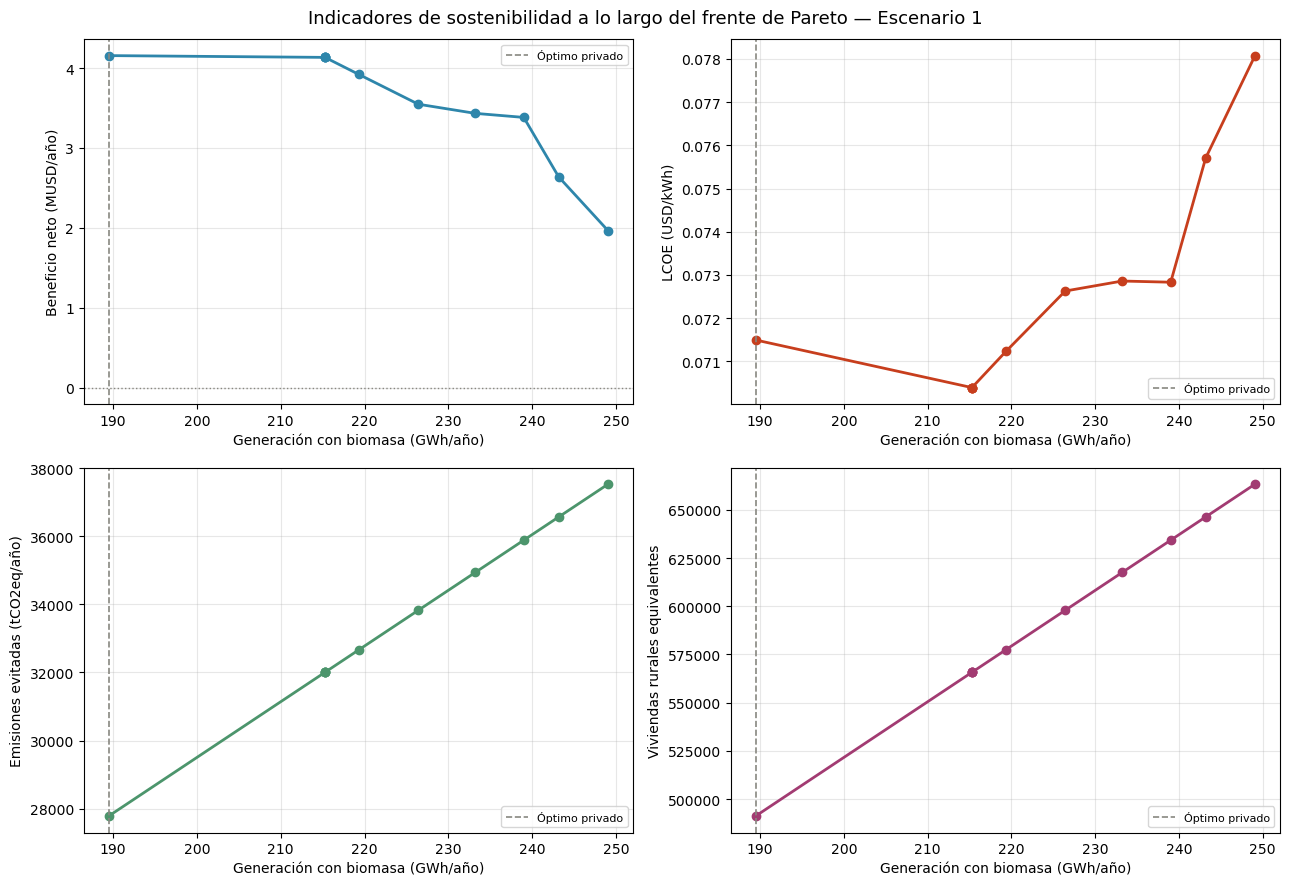

In [248]:
# ==========================================================
# Sección 19b - Puntos notables del frente (Escenario 1)
# CORREGIDO: con el CAPEX corregido NO existe punto de equilibrio — el
# beneficio es positivo en todo el frente. El código anterior asumía un
# cruce por cero y fallaba. La pregunta ya no es "¿dónde deja de ser
# rentable?" sino "¿cuánto beneficio cuesta desplegar el 100%?".
# ==========================================================
b = df_sost['beneficio_neto_total_USD'].values
pot_max = df_sost['generacion_GWh'].iloc[-1]

opt_eco  = df_sost.iloc[df_sost['beneficio_neto_total_USD'].idxmax()]
opt_lcoe = df_sost.iloc[df_sost['lcoe_USD_kWh'].idxmin()]
total    = df_sost.iloc[-1]

def linea(nombre, f):
    print(f"{nombre:18s}: {f['generacion_GWh']:6.1f} GWh ({f['generacion_GWh']/pot_max*100:5.1f}%) | "
          f"${f['beneficio_neto_total_USD']:>12,.0f} | LCOE ${f['lcoe_USD_kWh']:.4f} | "
          f"{f['emisiones_evitadas_tCO2']:>8,.0f} tCO2 | {f['viviendas_rurales']:>9,.0f} viv.")

print("=== PUNTOS NOTABLES DEL FRENTE (Escenario 1) ===\n")
linea("Óptimo privado", opt_eco)
linea("LCOE mínimo", opt_lcoe)
linea("Despliegue total", total)

# --- ¿Hay punto de equilibrio? ---
if np.any(np.sign(b) != np.sign(b[0])):
    i = np.where(np.diff(np.sign(b)))[0][0]
    frac = b[i] / (b[i] - b[i+1])
    g = df_sost['generacion_GWh'].values
    gen_eq = g[i] + frac * (g[i+1] - g[i])
    print(f"\n>> Punto de equilibrio en {gen_eq:.1f} GWh ({gen_eq/pot_max*100:.1f}% del potencial)")
else:
    print(f"\n>> NO existe punto de equilibrio: el beneficio es POSITIVO en todo el frente "
          f"(mínimo ${b.min():,.0f}/año).")
    print(">> El despliegue del 100% de la biomasa NO requiere subsidio.")

# --- El trade-off real: costo de oportunidad del despliegue total ---
costo_desplegar = opt_eco['beneficio_neto_total_USD'] - total['beneficio_neto_total_USD']
print(f"\n--- Costo de desplegar el 100% (óptimo privado -> despliegue total) ---")
print(f"Beneficio sacrificado : ${costo_desplegar:,.0f}/año "
      f"({costo_desplegar/opt_eco['beneficio_neto_total_USD']*100:.0f}% del óptimo)")
print(f"Energía adicional     : +{total['generacion_GWh'] - opt_eco['generacion_GWh']:.1f} GWh/año")
print(f"Emisiones adicionales : +{total['emisiones_evitadas_tCO2'] - opt_eco['emisiones_evitadas_tCO2']:,.0f} tCO2/año")
print(f"Costo por tCO2 evitada: ${costo_desplegar/(total['emisiones_evitadas_tCO2'] - opt_eco['emisiones_evitadas_tCO2']):,.0f}/tCO2")

# --- Figura de 4 paneles ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
series = [
    ('beneficio_neto_total_USD', 'Beneficio neto (MUSD/año)', 1e6, '#2E86AB'),
    ('lcoe_USD_kWh',             'LCOE (USD/kWh)',            1,   '#C73E1D'),
    ('emisiones_evitadas_tCO2',  'Emisiones evitadas (tCO2eq/año)', 1, '#4C956C'),
    ('viviendas_rurales',        'Viviendas rurales equivalentes',  1, '#A23B72'),
]
for ax, (col, lab, esc, color) in zip(axes.flat, series):
    ax.plot(df_sost['generacion_GWh'], df_sost[col]/esc, 'o-', color=color, linewidth=2, markersize=6)
    ax.axvline(opt_eco['generacion_GWh'], color='#888780', linestyle='--', linewidth=1.2,
               label='Óptimo privado')
    if col == 'beneficio_neto_total_USD':
        ax.axhline(0, color='#888780', linestyle=':', linewidth=1)
    ax.set_xlabel('Generación con biomasa (GWh/año)')
    ax.set_ylabel(lab)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Indicadores de sostenibilidad a lo largo del frente de Pareto — Escenario 1', fontsize=13)
plt.tight_layout()
plt.savefig('indicadores_sostenibilidad_pareto_esc1.png', dpi=150)
plt.show()

In [253]:
# ==========================================================
# Sección 19 bis - Indicadores de sostenibilidad sobre el frente (Esc. 2)
# CAPEX leído de CATALOGO (regla 0.6), NO reconstruido linealmente.
# ==========================================================
capex_fijo_total_e2 = sum(capex_fijo_esc2_dict[p] for p in plantas)

filas = []
for n in sorted(df_pareto_plantas_e2['punto'].unique()):
    sub = df_pareto_plantas_e2[df_pareto_plantas_e2['punto'] == n]

    generacion_kWh = sub['generacion_kWh'].sum()
    excedente_kWh  = sub['excedente_kWh'].sum()

    capex_turbinas = sum(CAPEX_TURBINA_ESC2[int(row['cap_turbina_kW'])]
                         for _, row in sub.iterrows() if row['cap_turbina_kW'] > 0)
    n_modulos    = sub['cap_biogas_kW'].sum() / TAMANO_UNIDAD_BIOGAS_KW
    capex_biogas = n_modulos * CAPEX_UNIDAD_BIOGAS

    capex_total = capex_fijo_total_e2 + capex_turbinas + capex_biogas
    lcoe = (capex_total / PVAF + PCT_OPERACION_ANUAL * capex_total) / generacion_kWh

    filas.append({
        'punto': n,
        'generacion_GWh': generacion_kWh / 1e6,
        'excedente_GWh': excedente_kWh / 1e6,
        'capex_total_MUSD': capex_total / 1e6,
        'lcoe_USD_kWh': lcoe,
        'emisiones_evitadas_tCO2': excedente_kWh * FACTOR_RED_NACIONAL / 1000,
        'viviendas_rurales': viviendas_rurales_beneficiadas(excedente_kWh),
    })

df_sost_e2 = pd.DataFrame(filas)
df_sost_e2 = df_sost_e2.merge(df_pareto_e2[['punto', 'f1_beneficio_USD']], on='punto', how='left')
df_sost_e2['beneficio_neto_total_USD'] = (
    df_sost_e2['f1_beneficio_USD']
    - capex_fijo_anualizado_total          # CAPEX fijo Esc.2 anualizado (sin O&M)
    - PCT_OPERACION_ANUAL * capex_fijo_total_e2
)

print(df_sost_e2[['generacion_GWh', 'excedente_GWh', 'beneficio_neto_total_USD',
                  'lcoe_USD_kWh', 'emisiones_evitadas_tCO2',
                  'viviendas_rurales']].to_string(index=False))
df_sost_e2.to_csv('indicadores_sostenibilidad_pareto_esc2.csv', index=False)

 generacion_GWh  excedente_GWh  beneficio_neto_total_USD  lcoe_USD_kWh  emisiones_evitadas_tCO2  viviendas_rurales
     147.476939     130.684279              7.241802e+06      0.046600             21353.811143      377457.601870
     148.956903     132.164244              7.191750e+06      0.046751             21595.637391      381732.209110
     150.320216     133.527556              7.147243e+06      0.046876             21818.402642      385669.887333
     151.931866     135.139206              7.065626e+06      0.047276             22081.746333      390324.844602
     153.135366     136.342706              7.017666e+06      0.047444             22278.398233      393800.933909
     155.560466     138.767806              6.952359e+06      0.047494             22674.659492      400805.389610
     156.738966     139.946306              6.900189e+06      0.047664             22867.226392      404209.270996
     158.112966     141.320306              6.846688e+06      0.047829          


=== ESCENARIO 1 ===
Óptimo privado    :  189.5 GWh ( 76.1%) | $   4,156,714 | LCOE $0.0715 |   27,785 tCO2
LCOE mínimo       :  215.3 GWh ( 86.4%) | $   4,134,420 | LCOE $0.0704 |   32,006 tCO2
Despliegue total  :  249.1 GWh (100.0%) | $   1,964,312 | LCOE $0.0781 |   37,528 tCO2
>> Rentable en TODO el frente (mínimo $1,964,312/año) — sin subsidio.
>> Costo de desplegar el 100%: $2,192,403/año (53% del óptimo) | $225 por tCO2 adicional evitada

=== ESCENARIO 2 ===
Óptimo privado    :  147.5 GWh ( 91.2%) | $   7,241,802 | LCOE $0.0466 |   21,354 tCO2
LCOE mínimo       :  147.5 GWh ( 91.2%) | $   7,241,802 | LCOE $0.0466 |   21,354 tCO2
Despliegue total  :  161.6 GWh (100.0%) | $   6,334,963 | LCOE $0.0507 |   23,665 tCO2
>> Rentable en TODO el frente (mínimo $6,334,963/año) — sin subsidio.
>> Costo de desplegar el 100%: $906,838/año (13% del óptimo) | $392 por tCO2 adicional evitada


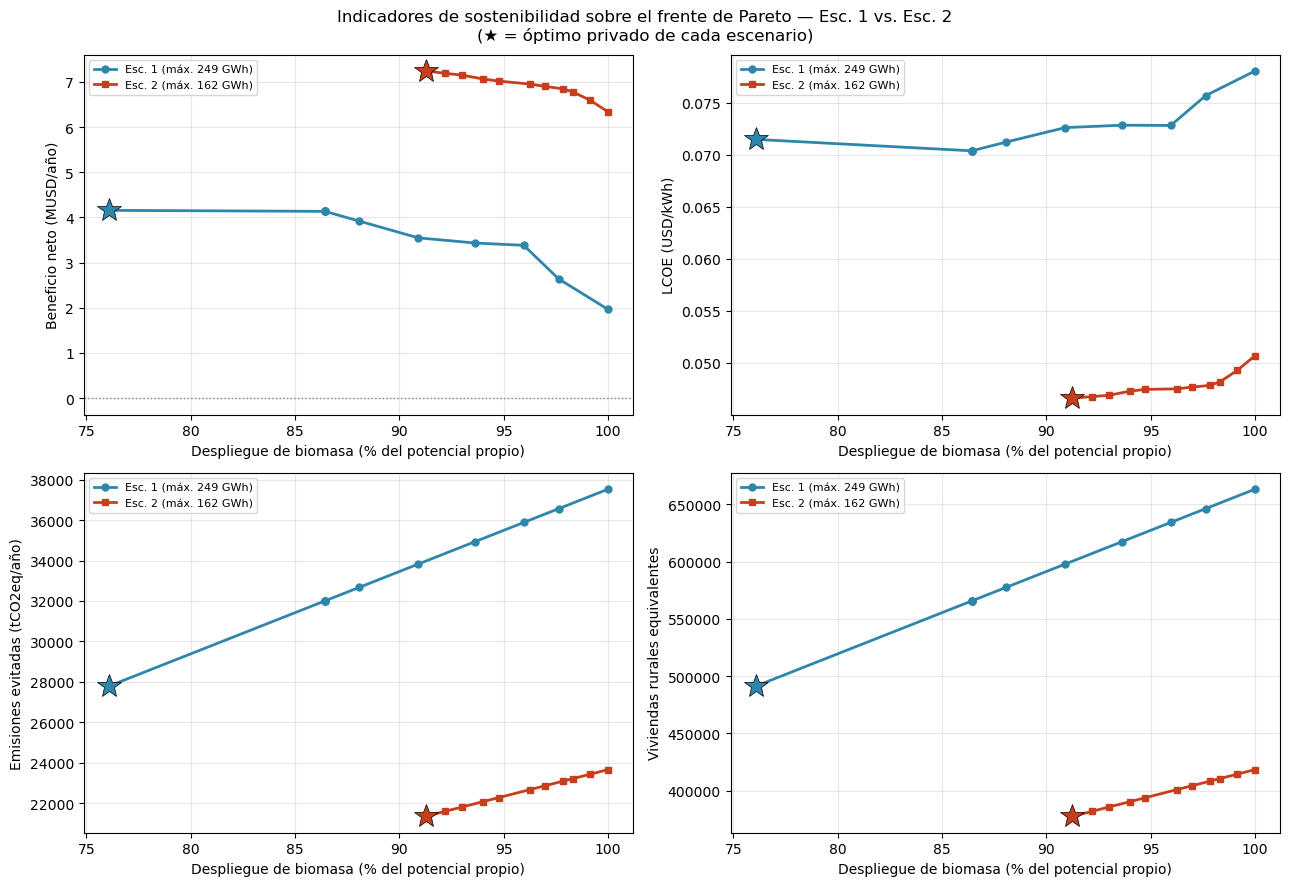

In [254]:
# ==========================================================
# Sección 19c - Puntos notables (Esc. 2) y comparación con Esc. 1
# ==========================================================
def puntos_notables(df, nombre):
    b = df['beneficio_neto_total_USD'].values
    pot_max = df['generacion_GWh'].iloc[-1]
    opt  = df.iloc[df['beneficio_neto_total_USD'].idxmax()]
    lcoe = df.iloc[df['lcoe_USD_kWh'].idxmin()]
    tot  = df.iloc[-1]

    print(f"\n=== {nombre} ===")
    for et, f in [("Óptimo privado", opt), ("LCOE mínimo", lcoe), ("Despliegue total", tot)]:
        print(f"{et:18s}: {f['generacion_GWh']:6.1f} GWh ({f['generacion_GWh']/pot_max*100:5.1f}%) | "
              f"${f['beneficio_neto_total_USD']:>12,.0f} | LCOE ${f['lcoe_USD_kWh']:.4f} | "
              f"{f['emisiones_evitadas_tCO2']:>8,.0f} tCO2")

    if np.any(np.sign(b) != np.sign(b[0])):
        print(">> Existe punto de equilibrio.")
    else:
        print(f">> Rentable en TODO el frente (mínimo ${b.min():,.0f}/año) — sin subsidio.")

    costo = opt['beneficio_neto_total_USD'] - tot['beneficio_neto_total_USD']
    d_co2 = tot['emisiones_evitadas_tCO2'] - opt['emisiones_evitadas_tCO2']
    print(f">> Costo de desplegar el 100%: ${costo:,.0f}/año "
          f"({costo/opt['beneficio_neto_total_USD']*100:.0f}% del óptimo) | "
          f"${costo/d_co2:,.0f} por tCO2 adicional evitada")
    return opt, tot

opt1, tot1 = puntos_notables(df_sost,    "ESCENARIO 1")
opt2, tot2 = puntos_notables(df_sost_e2, "ESCENARIO 2")

# --- Figura comparativa: eje X normalizado (% del potencial propio) ---
df_sost['pct_pot']    = df_sost['generacion_GWh']    / df_sost['generacion_GWh'].iloc[-1]    * 100
df_sost_e2['pct_pot'] = df_sost_e2['generacion_GWh'] / df_sost_e2['generacion_GWh'].iloc[-1] * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
series = [
    ('beneficio_neto_total_USD', 'Beneficio neto (MUSD/año)',       1e6),
    ('lcoe_USD_kWh',             'LCOE (USD/kWh)',                  1),
    ('emisiones_evitadas_tCO2',  'Emisiones evitadas (tCO2eq/año)', 1),
    ('viviendas_rurales',        'Viviendas rurales equivalentes',  1),
]
for ax, (col, lab, esc) in zip(axes.flat, series):
    ax.plot(df_sost['pct_pot'],    df_sost[col]/esc,    'o-', color='#2E86AB',
            linewidth=2, markersize=5, label=f"Esc. 1 (máx. {df_sost['generacion_GWh'].iloc[-1]:.0f} GWh)")
    ax.plot(df_sost_e2['pct_pot'], df_sost_e2[col]/esc, 's-', color='#C73E1D',
            linewidth=2, markersize=5, label=f"Esc. 2 (máx. {df_sost_e2['generacion_GWh'].iloc[-1]:.0f} GWh)")
    # Marcar el óptimo privado de cada escenario
    i1 = df_sost['beneficio_neto_total_USD'].idxmax()
    i2 = df_sost_e2['beneficio_neto_total_USD'].idxmax()
    ax.plot(df_sost['pct_pot'][i1],    df_sost[col][i1]/esc,    '*', color='#2E86AB',
            markersize=18, markeredgecolor='k', markeredgewidth=0.5, zorder=5)
    ax.plot(df_sost_e2['pct_pot'][i2], df_sost_e2[col][i2]/esc, '*', color='#C73E1D',
            markersize=18, markeredgecolor='k', markeredgewidth=0.5, zorder=5)
    if col == 'beneficio_neto_total_USD':
        ax.axhline(0, color='#888780', linestyle=':', linewidth=1)
    ax.set_xlabel('Despliegue de biomasa (% del potencial propio)')
    ax.set_ylabel(lab)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Indicadores de sostenibilidad sobre el frente de Pareto — Esc. 1 vs. Esc. 2\n'
             '(★ = óptimo privado de cada escenario)', fontsize=12)
plt.tight_layout()
plt.savefig('indicadores_sostenibilidad_pareto_comparacion.png', dpi=150)
plt.show()

In [245]:
# ==========================================================
# Sección 19c - Indicador social con TECHO + indicador no saturante
# Hallazgo: el excedente supera la demanda residencial rural del Magdalena
# (30.3 GWh/año) en TODOS los puntos del frente -> el indicador de viviendas
# se satura. Se reporta con techo (87,516 viviendas = 100% de usuarios
# rurales) y se añade la cobertura sobre la demanda TOTAL departamental,
# que sí discrimina entre puntos del frente.
# ==========================================================
df_sost['pct_cobertura_rural'] = (df_sost['excedente_GWh'] / DEMANDA_RESIDENCIAL_RURAL_GWh) * 100
df_sost['pct_cobertura_rural_techo'] = df_sost['pct_cobertura_rural'].clip(upper=100)
df_sost['viviendas_rurales_techo'] = df_sost['viviendas_rurales'].clip(upper=USUARIOS_RURALES)
df_sost['pct_demanda_departamental'] = (df_sost['excedente_GWh'] / DEMANDA_TOTAL_DEPARTAMENTAL_GWh) * 100

print(df_sost[['generacion_GWh', 'excedente_GWh', 'pct_cobertura_rural',
               'viviendas_rurales_techo', 'pct_demanda_departamental',
               'emisiones_evitadas_tCO2', 'lcoe_USD_kWh']].to_string(index=False))

print(f"\nConsumo por vivienda rural: {CONSUMO_PROMEDIO_VIVIENDA_RURAL_kWh:.0f} kWh/año")
print(f"Demanda rural departamental: {DEMANDA_RESIDENCIAL_RURAL_GWh} GWh/año")
print(f"Cobertura rural en el ÓPTIMO PRIVADO: {df_sost['pct_cobertura_rural'].iloc[0]:.0f}% "
      f"-> el indicador satura desde el primer punto del frente")

df_sost.to_csv('indicadores_sostenibilidad_pareto_esc1.csv', index=False)

 generacion_GWh  excedente_GWh  pct_cobertura_rural  viviendas_rurales_techo  pct_demanda_departamental  emisiones_evitadas_tCO2  lcoe_USD_kWh
     189.454778     170.045131           561.205054                  87516.0                   6.997742             27785.374457      0.071495
     215.285978     195.876331           646.456539                  87516.0                   8.060754             32006.192537      0.070393
     215.285978     195.876331           646.456539                  87516.0                   8.060754             32006.192537      0.070393
     215.285978     195.876331           646.456539                  87516.0                   8.060754             32006.192537      0.070393
     215.285978     195.876331           646.456539                  87516.0                   8.060754             32006.192537      0.070393
     219.341410     199.931763           659.840804                  87516.0                   8.227645             32668.850155      0.071231

## 20 Target Seeking

=== COSTO DE OPORTUNIDAD DEL DESPLIEGUE TOTAL ===

=== ESCENARIO 1 ===
Óptimo privado    :  189.5 GWh ( 76.1%) | $  4,156,714/año
Despliegue 100%   :  249.1 GWh (100.0%) | $  1,964,312/año
>> Ambos POSITIVOS: el despliegue total NO requiere subsidio.
>> Costo de oportunidad: $2,192,403/año (53% del óptimo)
>> Compra: +59.6 GWh/año y +9,742 tCO2eq/año
>> Costo implícito: $225 por tCO2eq adicional evitada

=== ESCENARIO 2 ===
Óptimo privado    :  147.5 GWh ( 91.2%) | $  7,241,802/año
Despliegue 100%   :  161.6 GWh (100.0%) | $  6,334,963/año
>> Ambos POSITIVOS: el despliegue total NO requiere subsidio.
>> Costo de oportunidad: $906,838/año (13% del óptimo)
>> Compra: +14.1 GWh/año y +2,311 tCO2eq/año
>> Costo implícito: $392 por tCO2eq adicional evitada

COMPARACIÓN
El Esc.2 es más rentable en su óptimo privado (+74%) y le cuesta mucho menos desplegar el 100% (13% vs. 53% del óptimo).
PERO compra CO2 evitado MÁS CARO: $392 vs. $225 por tCO2 (1.7x), porque ya opera al 91% en su óptimo pri

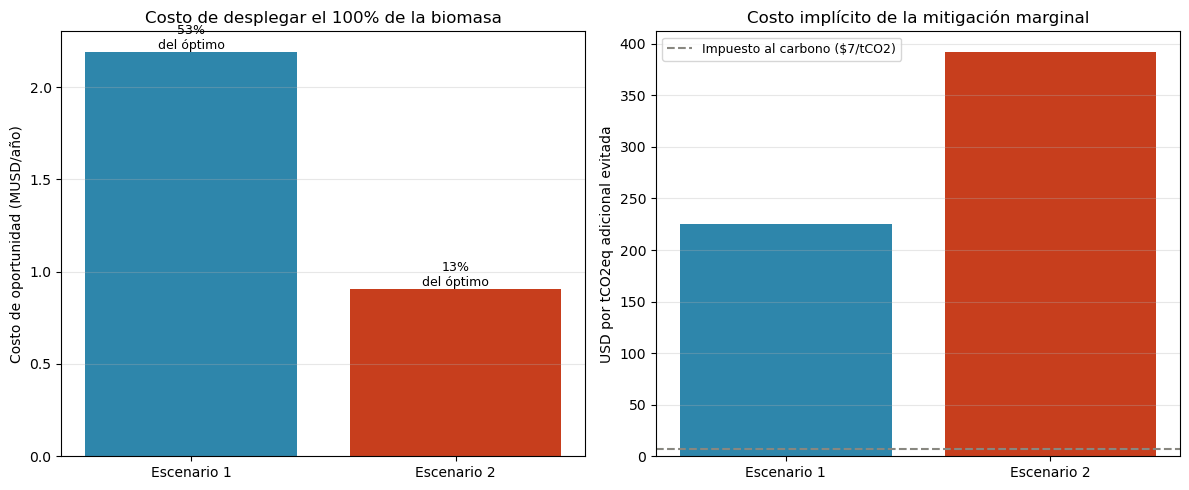

In [260]:
# ==========================================================
# Sección 20 - Costo de oportunidad del despliegue total y comparación
# con el precio del carbono — AMBOS ESCENARIOS.
#
# CORREGIDO: con el CAPEX corregido NO existe brecha a subsidiar (ambos
# escenarios son rentables al 100%). Lo que se cuantifica es el COSTO DE
# OPORTUNIDAD: beneficio NO REALIZADO, no una pérdida. El lenguaje de
# "subsidio" y "brecha" queda eliminado del artículo.
# ==========================================================

# Precio del carbono (Decreto 926/2017). ⚠️ VERIFICAR valor vigente 2026.
PRECIO_CARBONO_USD_tCO2 = 25_000 / 3_339.65   # ~COP 25,000/tCO2, TRM 3,339.65

def costo_oportunidad(df, nombre):
    opt = df.iloc[df['beneficio_neto_total_USD'].idxmax()]
    tot = df.iloc[-1]

    co    = opt['beneficio_neto_total_USD'] - tot['beneficio_neto_total_USD']
    d_co2 = tot['emisiones_evitadas_tCO2']  - opt['emisiones_evitadas_tCO2']
    d_gwh = tot['generacion_GWh']           - opt['generacion_GWh']
    implicito = co / d_co2

    print(f"\n=== {nombre} ===")
    print(f"Óptimo privado    : {opt['generacion_GWh']:6.1f} GWh "
          f"({opt['generacion_GWh']/tot['generacion_GWh']*100:5.1f}%) | ${opt['beneficio_neto_total_USD']:>11,.0f}/año")
    print(f"Despliegue 100%   : {tot['generacion_GWh']:6.1f} GWh (100.0%) | ${tot['beneficio_neto_total_USD']:>11,.0f}/año")
    print(f">> Ambos POSITIVOS: el despliegue total NO requiere subsidio.")
    print(f">> Costo de oportunidad: ${co:,.0f}/año ({co/opt['beneficio_neto_total_USD']*100:.0f}% del óptimo)")
    print(f">> Compra: +{d_gwh:.1f} GWh/año y +{d_co2:,.0f} tCO2eq/año")
    print(f">> Costo implícito: ${implicito:,.0f} por tCO2eq adicional evitada")

    return {'escenario': nombre,
            'gen_optimo_GWh': opt['generacion_GWh'],
            'pct_optimo': opt['generacion_GWh']/tot['generacion_GWh']*100,
            'beneficio_optimo_USD': opt['beneficio_neto_total_USD'],
            'gen_total_GWh': tot['generacion_GWh'],
            'beneficio_total_USD': tot['beneficio_neto_total_USD'],
            'costo_oportunidad_USD': co,
            'pct_del_optimo': co/opt['beneficio_neto_total_USD']*100,
            'delta_GWh': d_gwh,
            'delta_tCO2': d_co2,
            'tCO2_totales_100pct': tot['emisiones_evitadas_tCO2'],
            'costo_implicito_USD_tCO2': implicito}

print("=== COSTO DE OPORTUNIDAD DEL DESPLIEGUE TOTAL ===")
r1 = costo_oportunidad(df_sost,    "ESCENARIO 1")
r2 = costo_oportunidad(df_sost_e2, "ESCENARIO 2")

df_co = pd.DataFrame([r1, r2])
df_co.to_csv('costo_oportunidad_despliegue.csv', index=False)

# --- Comparación directa ---
print("\n" + "="*70)
print("COMPARACIÓN")
print("="*70)
print(f"El Esc.2 es más rentable en su óptimo privado "
      f"(+{(r2['beneficio_optimo_USD']/r1['beneficio_optimo_USD']-1)*100:.0f}%) y le cuesta "
      f"mucho menos desplegar el 100% ({r2['pct_del_optimo']:.0f}% vs. {r1['pct_del_optimo']:.0f}% del óptimo).")
print(f"PERO compra CO2 evitado MÁS CARO: ${r2['costo_implicito_USD_tCO2']:,.0f} vs. "
      f"${r1['costo_implicito_USD_tCO2']:,.0f} por tCO2 "
      f"({r2['costo_implicito_USD_tCO2']/r1['costo_implicito_USD_tCO2']:.1f}x), porque ya opera al "
      f"{r2['pct_optimo']:.0f}% en su óptimo privado y le queda poco margen de expansión.")
print(f"Y en términos ABSOLUTOS el Esc.1 evita mucho más: "
      f"{r1['tCO2_totales_100pct']:,.0f} vs. {r2['tCO2_totales_100pct']:,.0f} tCO2eq/año "
      f"(+{(r1['tCO2_totales_100pct']/r2['tCO2_totales_100pct']-1)*100:.0f}%).")

# --- Contraste con el impuesto al carbono ---
print(f"\n--- Impuesto al carbono (Decreto 926/2017): ${PRECIO_CARBONO_USD_tCO2:,.2f}/tCO2eq ---")
for r in (r1, r2):
    print(f"{r['escenario']}: el impuesto cubre el "
          f"{PRECIO_CARBONO_USD_tCO2/r['costo_implicito_USD_tCO2']*100:.1f}% del costo implícito "
          f"({r['costo_implicito_USD_tCO2']/PRECIO_CARBONO_USD_tCO2:.0f}x menor)")
print(">> En ambos casos, el precio del carbono es incapaz de movilizar el tramo final del potencial.")

# --- Figura: costo de oportunidad y costo implícito por tCO2 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
escs = ['Escenario 1', 'Escenario 2']
colores = ['#2E86AB', '#C73E1D']

ax1.bar(escs, [r1['costo_oportunidad_USD']/1e6, r2['costo_oportunidad_USD']/1e6], color=colores)
ax1.set_ylabel('Costo de oportunidad (MUSD/año)')
ax1.set_title('Costo de desplegar el 100% de la biomasa')
for i, r in enumerate((r1, r2)):
    ax1.text(i, r['costo_oportunidad_USD']/1e6, f"{r['pct_del_optimo']:.0f}%\ndel óptimo",
             ha='center', va='bottom', fontsize=9)
ax1.grid(alpha=0.3, axis='y')

ax2.bar(escs, [r1['costo_implicito_USD_tCO2'], r2['costo_implicito_USD_tCO2']], color=colores)
ax2.axhline(PRECIO_CARBONO_USD_tCO2, color='#888780', linestyle='--',
            label=f'Impuesto al carbono (${PRECIO_CARBONO_USD_tCO2:.0f}/tCO2)')
ax2.set_ylabel('USD por tCO2eq adicional evitada')
ax2.set_title('Costo implícito de la mitigación marginal')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('costo_oportunidad_comparacion.png', dpi=150)
plt.show()

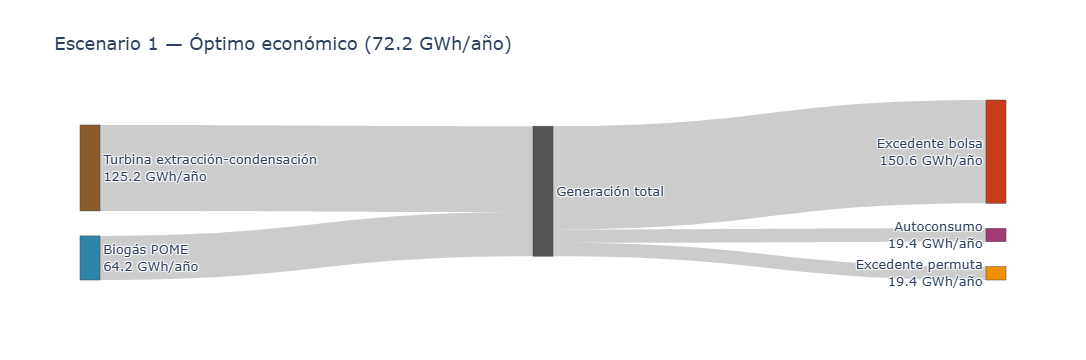

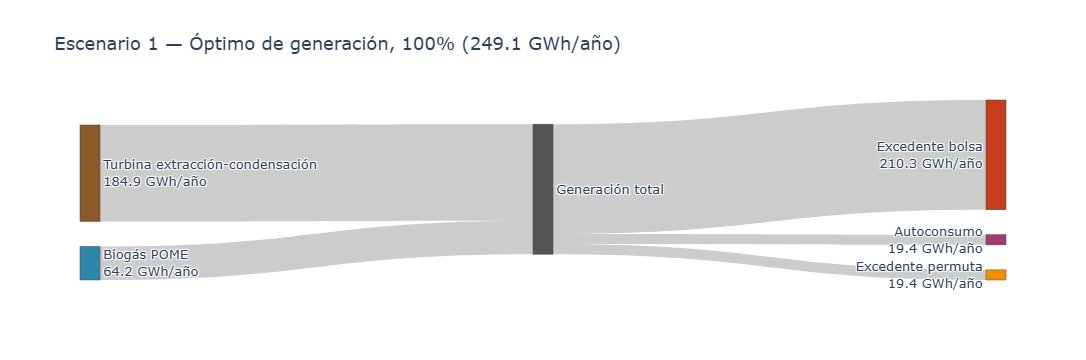


Cambio en turbina: 125.24 -> 184.86 GWh/año (+48%)
Cambio en biogás:  64.22 -> 64.22 GWh/año (+0.0%)


In [234]:
# ==========================================================
# Sección 20 - Ajuste: misma anotación de valores numéricos para 
# Escenario 1 (consistencia de estilo entre ambas figuras del artículo).
# ==========================================================
def construir_sankey_esc1_anotado(m, titulo, nombre_archivo):
    turbina_kWh = sum(pyo.value(m.potencia_turbina_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    biogas_kWh = sum(pyo.value(m.potencia_biogas_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    autoconsumo_kWh = sum(pyo.value(m.autoconsumo_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    permuta_kWh = sum(pyo.value(m.excedente_permuta_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    bolsa_kWh = sum(pyo.value(m.excedente_bolsa_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6

    labels = [
        f"Turbina extracción-condensación<br>{turbina_kWh:.1f} GWh/año",
        f"Biogás POME<br>{biogas_kWh:.1f} GWh/año",
        "Generación total",
        f"Autoconsumo<br>{autoconsumo_kWh:.1f} GWh/año",
        f"Excedente permuta<br>{permuta_kWh:.1f} GWh/año",
        f"Excedente bolsa<br>{bolsa_kWh:.1f} GWh/año",
    ]
    source = [0, 1, 2, 2, 2]
    target = [2, 2, 3, 4, 5]
    value = [turbina_kWh, biogas_kWh, autoconsumo_kWh, permuta_kWh, bolsa_kWh]

    fig = go.Figure(data=[go.Sankey(
        node=dict(pad=25, thickness=20, label=labels,
                   color=["#8B5A2B", "#2E86AB", "#555555", "#A23B72", "#F18F01", "#C73E1D"]),
        link=dict(source=source, target=target, value=value)
    )])
    fig.update_layout(title_text=titulo, font_size=13)
    fig.write_html(nombre_archivo + ".html")
    fig.write_image(nombre_archivo + ".png", scale=2)
    fig.show()
    return {"turbina_GWh": turbina_kWh, "biogas_GWh": biogas_kWh}

r_eco_e1 = construir_sankey_esc1_anotado(m1, "Escenario 1 — Óptimo económico (72.2 GWh/año)", "sankey_esc1_optimo_economico_v2")
r_gen_e1 = construir_sankey_esc1_anotado(m2, "Escenario 1 — Óptimo de generación, 100% (249.1 GWh/año)", "sankey_esc1_optimo_generacion_v2")

print(f"\nCambio en turbina: {r_eco_e1['turbina_GWh']:.2f} -> {r_gen_e1['turbina_GWh']:.2f} GWh/año "
      f"({(r_gen_e1['turbina_GWh']/r_eco_e1['turbina_GWh']-1)*100:+.0f}%)")
print(f"Cambio en biogás:  {r_eco_e1['biogas_GWh']:.2f} -> {r_gen_e1['biogas_GWh']:.2f} GWh/año "
      f"({(r_gen_e1['biogas_GWh']/r_eco_e1['biogas_GWh']-1)*100:+.1f}%)")

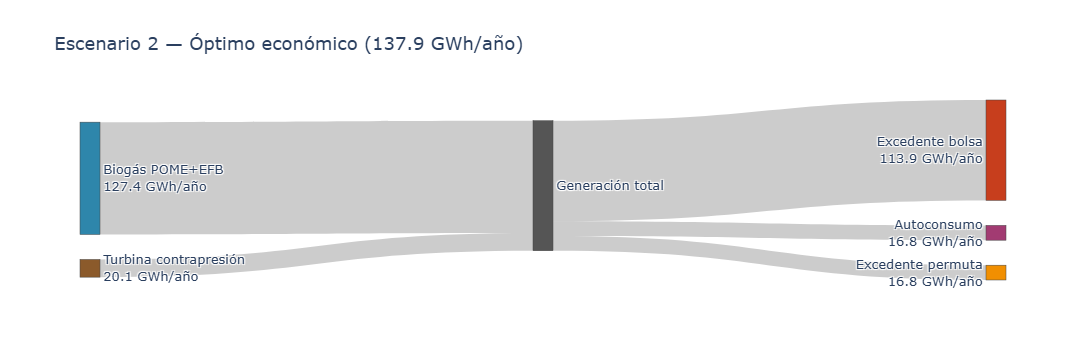

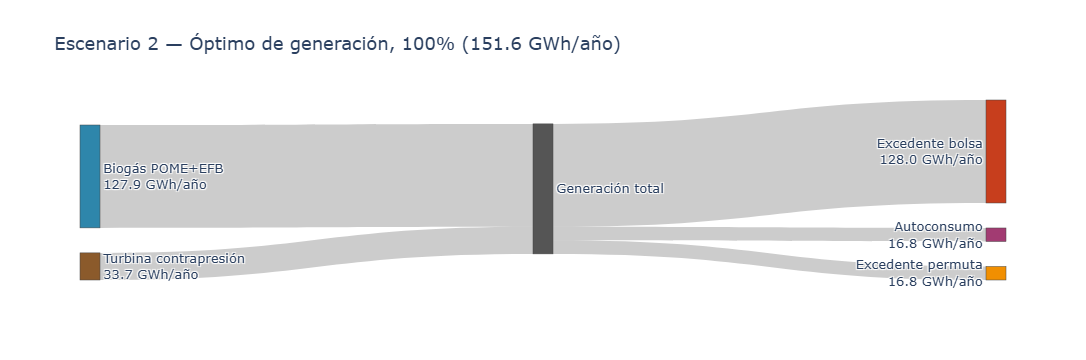


Cambio en turbina: 20.07 -> 33.72 GWh/año (+68%)
Cambio en biogás:  127.41 -> 127.90 GWh/año (+0.4%)


In [250]:
# ==========================================================
# Sección 20 - Ajuste: etiquetas con valores numéricos explícitos, 
# para que el contraste (o la ausencia de contraste, en Escenario 2) 
# sea legible en el PNG estático, no solo en el hover interactivo.
# ==========================================================
def construir_sankey_esc2_anotado(m, titulo, nombre_archivo):
    turbina_kWh = sum(pyo.value(m.potencia_turbina_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    biogas_kWh = sum(pyo.value(m.potencia_biogas_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    autoconsumo_kWh = sum(pyo.value(m.autoconsumo_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    permuta_kWh = sum(pyo.value(m.excedente_permuta_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    bolsa_kWh = sum(pyo.value(m.excedente_bolsa_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6

    labels = [
        f"Turbina contrapresión<br>{turbina_kWh:.1f} GWh/año",
        f"Biogás POME+EFB<br>{biogas_kWh:.1f} GWh/año",
        "Generación total",
        f"Autoconsumo<br>{autoconsumo_kWh:.1f} GWh/año",
        f"Excedente permuta<br>{permuta_kWh:.1f} GWh/año",
        f"Excedente bolsa<br>{bolsa_kWh:.1f} GWh/año",
    ]
    source = [0, 1, 2, 2, 2]
    target = [2, 2, 3, 4, 5]
    value = [turbina_kWh, biogas_kWh, autoconsumo_kWh, permuta_kWh, bolsa_kWh]

    fig = go.Figure(data=[go.Sankey(
        node=dict(pad=25, thickness=20, label=labels,
                   color=["#8B5A2B", "#2E86AB", "#555555", "#A23B72", "#F18F01", "#C73E1D"]),
        link=dict(source=source, target=target, value=value)
    )])
    fig.update_layout(title_text=titulo, font_size=13)
    fig.write_html(nombre_archivo + ".html")
    fig.write_image(nombre_archivo + ".png", scale=2)
    fig.show()
    return {"turbina_GWh": turbina_kWh, "biogas_GWh": biogas_kWh}

r_eco_e2 = construir_sankey_esc2_anotado(m1_e2, "Escenario 2 — Óptimo económico (137.9 GWh/año)", "sankey_esc2_optimo_economico_v2")
r_gen_e2 = construir_sankey_esc2_anotado(m2_e2, "Escenario 2 — Óptimo de generación, 100% (151.6 GWh/año)", "sankey_esc2_optimo_generacion_v2")

print(f"\nCambio en turbina: {r_eco_e2['turbina_GWh']:.2f} -> {r_gen_e2['turbina_GWh']:.2f} GWh/año "
      f"({(r_gen_e2['turbina_GWh']/r_eco_e2['turbina_GWh']-1)*100:+.0f}%)")
print(f"Cambio en biogás:  {r_eco_e2['biogas_GWh']:.2f} -> {r_gen_e2['biogas_GWh']:.2f} GWh/año "
      f"({(r_gen_e2['biogas_GWh']/r_eco_e2['biogas_GWh']-1)*100:+.1f}%)")

## Sección 21: Sensibilidad a incentivos tributarios

In [256]:
# ==========================================================
# Sección 21 - Sensibilidad a los incentivos tributarios (Ley 1715/2014
# mod. Ley 2099/2021). El modelo base NO los incorpora, por lo que sus
# resultados son conservadores. Aquí se evalúa un factor genérico de
# reducción efectiva del CAPEX (exclusión de IVA, deducción de renta,
# depreciación acelerada) sin comprometerse con un instrumento concreto.
# ==========================================================

# Guardar los valores originales para restaurarlos al final
_ORIG = {
    't1':      dict(CAPEX_TURBINA_ESC1),
    't2':      dict(CAPEX_TURBINA_ESC2),
    'bio':     CAPEX_UNIDAD_BIOGAS,
    'fijo_e1': capex_fijo_anualizado_total_esc1,
    'fijo_e2': capex_fijo_anualizado_total,
}

def correr_frente(escenario, incentivo):
    """Corre el e-constraint con el CAPEX reducido por 'incentivo' (0-1)
    y devuelve (generacion_optimo_GWh, beneficio_optimo, gen_equilibrio_GWh,
    pct_equilibrio, beneficio_despliegue_total)."""
    global CAPEX_TURBINA_ESC1, CAPEX_TURBINA_ESC2, CAPEX_UNIDAD_BIOGAS

    f = 1 - incentivo
    CAPEX_TURBINA_ESC1  = {k: v * f for k, v in _ORIG['t1'].items()}
    CAPEX_TURBINA_ESC2  = {k: v * f for k, v in _ORIG['t2'].items()}
    CAPEX_UNIDAD_BIOGAS = _ORIG['bio'] * f
    capex_fijo_anual = (_ORIG['fijo_e1'] if escenario == 1 else _ORIG['fijo_e2']) * f

    constructor = construir_modelo_f2 if escenario == 1 else construir_modelo_f2_esc2
    f2_ini = f2_en_f1max if escenario == 1 else f2_en_f1max_e2
    f2_fin = f2_max      if escenario == 1 else f2_max_e2

    gen, ben = [], []
    for n in range(q + 1):
        eps = f2_ini + n * (f2_fin - f2_ini) / q
        m = constructor(objetivo='economico', restriccion_f2=eps)
        r = solver.solve(m, tee=False)
        if r.solver.termination_condition == pyo.TerminationCondition.optimal:
            gen.append(pyo.value(m.f2_generacion) / 1e6)
            ben.append(pyo.value(m.f1_economico) - capex_fijo_anual)

    gen, ben = np.array(gen), np.array(ben)
    i_opt = ben.argmax()
    pot_max = gen[-1]

    # Punto de equilibrio (interpolación lineal donde el beneficio cruza cero)
    cruces = np.where(np.diff(np.sign(ben)))[0]
    if len(cruces) == 0:
        gen_eq, pct_eq = (np.nan, np.nan) if ben[-1] < 0 else (pot_max, 100.0)
    else:
        i = cruces[0]
        frac = ben[i] / (ben[i] - ben[i+1])
        gen_eq = gen[i] + frac * (gen[i+1] - gen[i])
        pct_eq = gen_eq / pot_max * 100

    return gen[i_opt], ben[i_opt], gen_eq, pct_eq, ben[-1]

# --- Barrido de incentivos ---
filas = []
for inc in [0.00, 0.10, 0.19, 0.30]:
    for esc in [1, 2]:
        g_opt, b_opt, g_eq, pct_eq, b_tot = correr_frente(esc, inc)
        filas.append({
            'incentivo_%': inc * 100,
            'escenario': esc,
            'gen_optimo_GWh': g_opt,
            'beneficio_optimo_USD': b_opt,
            'gen_equilibrio_GWh': g_eq,
            'equilibrio_%_potencial': pct_eq,
            'beneficio_despliegue_total_USD': b_tot,
        })

# Restaurar los valores originales (IMPORTANTE)
    CAPEX_TURBINA_ESC1  = dict(_ORIG['t1'])
    CAPEX_TURBINA_ESC2  = dict(_ORIG['t2'])
    CAPEX_UNIDAD_BIOGAS = _ORIG['bio']
df_sens = pd.DataFrame(filas)
print(df_sens.to_string(index=False))
df_sens.to_csv('sensibilidad_incentivos_tributarios.csv', index=False)

 incentivo_%  escenario  gen_optimo_GWh  beneficio_optimo_USD  gen_equilibrio_GWh  equilibrio_%_potencial  beneficio_despliegue_total_USD
         0.0          1      189.454778          4.866656e+06          249.077037                   100.0                    2.674253e+06
         0.0          2      147.476939          7.708652e+06          161.619463                   100.0                    6.801813e+06
        10.0          1      215.285978          6.288836e+06          249.077037                   100.0                    4.547954e+06
        10.0          2      147.476939          8.349206e+06          161.619463                   100.0                    7.574375e+06
        19.0          1      217.925260          7.590662e+06          249.077037                   100.0                    6.234285e+06
        19.0          2      147.476939          8.925705e+06          161.619463                   100.0                    8.269680e+06
        30.0          1      217.9

## Sección 22:Tarifa preferencial (targe seeking)

=== ESCENARIO 1 ===
 precio_excedente_USD_kWh  gen_elegida_GWh  pct_potencial_elegido  beneficio_libre_USD  beneficio_despliegue_total_USD
                     0.07       189.454778              76.062724         4.111524e+06                    1.901234e+06
                     0.08       215.285978              86.433491         5.846147e+06                    4.003812e+06
                     0.09       217.925260              87.493116         7.626309e+06                    6.106389e+06
                     0.10       217.925260              87.493116         9.417369e+06                    8.208967e+06
                     0.11       239.010160              95.958328         1.133045e+07                    1.031154e+07
                     0.12       239.010160              95.958328         1.338400e+07                    1.246575e+07
                     0.13       239.010160              95.958328         1.547342e+07                    1.465585e+07
                     0.14   

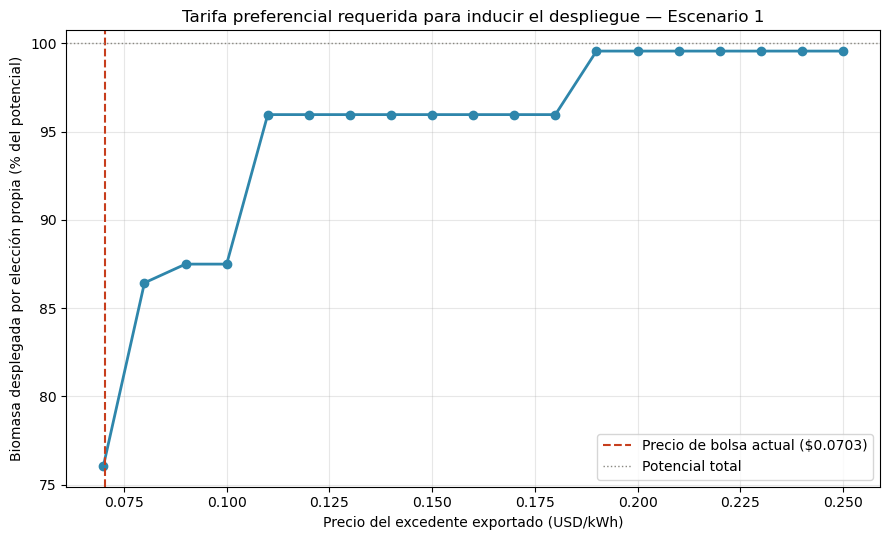

In [277]:
# ==========================================================
# Sección 22 - Tarifa preferencial (feed-in tariff) requerida
# Barrido del precio de los excedentes vendidos en bolsa. Para cada
# precio se resuelve el óptimo económico SIN restricción de generación,
# y se observa cuánta biomasa elige desplegar la planta libremente.
# Responde a dos preguntas:
#   (a) FiT de equilibrio: precio al que el despliegue total no pierde.
#   (b) FiT compatible con incentivos: precio al que la planta ELIGE el 100%.
# ==========================================================
_PRECIO_BOLSA_ORIG = PRECIO_BOLSA_PROMEDIO

def barrido_fit(escenario):
    global PRECIO_BOLSA_PROMEDIO
    constructor = construir_modelo_f2 if escenario == 1 else construir_modelo_f2_esc2

    # [CORREGIDO] capex_fijo ahora incluye su O&M anual (2.5%), igual que la
    # convencion del articulo (Sec. 19b). Antes solo restaba la anualizacion,
    # y el beneficio quedaba inflado por el O&M fijo total del escenario.
    if escenario == 1:
        capex_fijo = capex_fijo_anualizado_total_esc1 + capex_fijo_total * PCT_OPERACION_ANUAL
    else:
        capex_fijo = capex_fijo_anualizado_total + capex_fijo_total_e2 * PCT_OPERACION_ANUAL

    f2_potencial = (f2_max if escenario == 1 else f2_max_e2) / 1e6

    filas = []
    for precio in np.arange(0.07, 0.26, 0.01):
        PRECIO_BOLSA_PROMEDIO = precio

        # (a) Óptimo LIBRE: ¿cuánto elige desplegar la planta a este precio?
        m_libre = constructor(objetivo='economico')
        solver.solve(m_libre, tee=False)
        gen_libre = pyo.value(m_libre.f2_generacion) / 1e6
        ben_libre = pyo.value(m_libre.f1_economico) - capex_fijo

        # (b) Despliegue TOTAL forzado: ¿es rentable a este precio?
        m_full = constructor(objetivo='economico',
                             restriccion_f2=(f2_max if escenario == 1 else f2_max_e2))
        solver.solve(m_full, tee=False)
        ben_full = pyo.value(m_full.f1_economico) - capex_fijo

        filas.append({
            'precio_excedente_USD_kWh': precio,
            'gen_elegida_GWh': gen_libre,
            'pct_potencial_elegido': gen_libre / f2_potencial * 100,
            'beneficio_libre_USD': ben_libre,
            'beneficio_despliegue_total_USD': ben_full,
        })

    PRECIO_BOLSA_PROMEDIO = _PRECIO_BOLSA_ORIG   # restaurar
    return pd.DataFrame(filas)

df_fit1 = barrido_fit(1)
print("=== ESCENARIO 1 ===")
print(df_fit1.to_string(index=False))

# --- Extraer los dos umbrales ---
eq  = df_fit1[df_fit1['beneficio_despliegue_total_USD'] >= 0]
inc = df_fit1[df_fit1['pct_potencial_elegido'] >= 99.5]

print(f"\nPrecio actual de bolsa: ${_PRECIO_BOLSA_ORIG:.4f}/kWh")
print(f"(a) FiT de EQUILIBRIO (despliegue total sin pérdidas):  "
      f"${eq['precio_excedente_USD_kWh'].min():.3f}/kWh" if len(eq) else "(a) No alcanzado en el rango")
print(f"(b) FiT COMPATIBLE (la planta ELIGE el 100%):           "
      f"${inc['precio_excedente_USD_kWh'].min():.3f}/kWh" if len(inc) else "(b) No alcanzado en el rango")

df_fit1.to_csv('tarifa_preferencial_esc1.csv', index=False)

# --- Figura: despliegue elegido vs. precio del excedente ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(df_fit1['precio_excedente_USD_kWh'], df_fit1['pct_potencial_elegido'],
        'o-', color='#2E86AB', linewidth=2)
ax.axvline(_PRECIO_BOLSA_ORIG, color='#C73E1D', linestyle='--',
           label=f'Precio de bolsa actual (${_PRECIO_BOLSA_ORIG:.4f})')
ax.axhline(100, color='#888780', linestyle=':', linewidth=1, label='Potencial total')
ax.set_xlabel('Precio del excedente exportado (USD/kWh)')
ax.set_ylabel('Biomasa desplegada por elección propia (% del potencial)')
ax.set_title('Tarifa preferencial requerida para inducir el despliegue — Escenario 1')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('tarifa_preferencial_esc1.png', dpi=150)
plt.show()

=== ESCENARIO 2 ===
 precio_excedente_USD_kWh  gen_elegida_GWh  pct_potencial_elegido  beneficio_libre_USD  beneficio_despliegue_total_USD
                     0.07       147.476903              91.249470         7.207633e+06                    6.296553e+06
                     0.08       147.476903              91.249470         8.346549e+06                    7.576894e+06
                     0.09       147.476903              91.249470         9.485465e+06                    8.857236e+06
                     0.10       147.476903              91.249470         1.062438e+07                    1.013758e+07
                     0.11       155.560466              96.251072         1.179477e+07                    1.141792e+07
                     0.12       158.112966              97.830399         1.308097e+07                    1.274352e+07
                     0.13       158.112966              97.830399         1.440295e+07                    1.410057e+07
                     0.14   

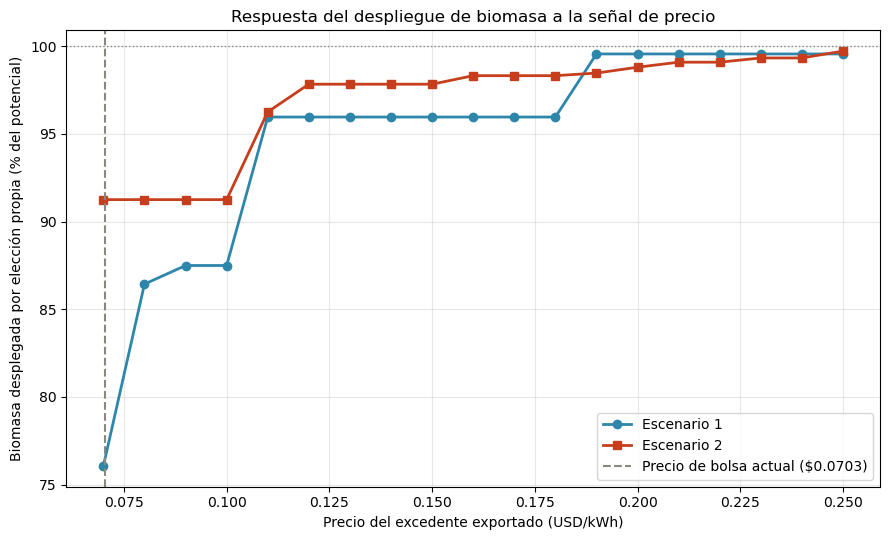

In [278]:
# ==========================================================
# Sección 22 (bis) - Tarifa preferencial, Escenario 2
# ==========================================================
df_fit2 = barrido_fit(2)
print("=== ESCENARIO 2 ===")
print(df_fit2.to_string(index=False))

eq2  = df_fit2[df_fit2['beneficio_despliegue_total_USD'] >= 0]
inc2 = df_fit2[df_fit2['pct_potencial_elegido'] >= 99.5]

print(f"\nPrecio actual de bolsa: ${_PRECIO_BOLSA_ORIG:.4f}/kWh")
print("(a) FiT de EQUILIBRIO: " +
      (f"${eq2['precio_excedente_USD_kWh'].min():.3f}/kWh" if len(eq2)
       else "no requiere — ya rentable al precio actual"))
print("(b) FiT COMPATIBLE (elige el 100%): " +
      (f"${inc2['precio_excedente_USD_kWh'].min():.3f}/kWh" if len(inc2)
       else "no alcanzado en el rango"))

df_fit2.to_csv('tarifa_preferencial_esc2.csv', index=False)

# --- Figura comparativa: respuesta del despliegue al precio ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(df_fit1['precio_excedente_USD_kWh'], df_fit1['pct_potencial_elegido'],
        'o-', color='#2E86AB', linewidth=2, label='Escenario 1')
ax.plot(df_fit2['precio_excedente_USD_kWh'], df_fit2['pct_potencial_elegido'],
        's-', color='#C73E1D', linewidth=2, label='Escenario 2')
ax.axvline(_PRECIO_BOLSA_ORIG, color='#888780', linestyle='--',
           label=f'Precio de bolsa actual (${_PRECIO_BOLSA_ORIG:.4f})')
ax.axhline(100, color='#888780', linestyle=':', linewidth=1)
ax.set_xlabel('Precio del excedente exportado (USD/kWh)')
ax.set_ylabel('Biomasa desplegada por elección propia (% del potencial)')
ax.set_title('Respuesta del despliegue de biomasa a la señal de precio')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('tarifa_preferencial_comparacion.png', dpi=150)
plt.show()

In [ ]:
df_fit1 = barrido_fit(escenario=1)
df_fit2 = barrido_fit(escenario=2)

# Validacion obligatoria: a precio=0.07, beneficio_despliegue_total debe dar
# ~1,901,235 (Esc.1) y un valor cercano a 6,296,553 (Esc.2)
print("Esc.1 @0.07:", round(df_fit1.loc[0,'beneficio_despliegue_total_USD']))
print("Esc.2 @0.07:", round(df_fit2.loc[0,'beneficio_despliegue_total_USD']))

df_fit1.to_csv('fit1_corregido.csv', index=False)
df_fit2.to_csv('fit2_corregido.csv', index=False)
print(df_fit1.to_string(index=False))
print(df_fit2.to_string(index=False))

## Sección 3- rentabilidad desagregada

In [273]:
# ============================================================
# SECCIÓN 23 — Análisis 1: rentabilidad desagregada por planta
# Reproduce la estructura del objetivo f1_economico (3 tramos CREG 174)
# planta por planta. Validado: la suma reproduce el agregado al peso.
# ============================================================
def beneficio_neto_por_planta(df_plantas, punto, capex_turbina_cat,
                              capex_fijo_dict, incluir_om_fijo=True):
    """Beneficio neto anual (USD) por planta en un punto del frente.
    Exacto en el punto de despliegue 100% (último punto), donde el factor
    de utilización de turbina = 1 y el costo de oportunidad entra completo.
    incluir_om_fijo=True -> convención del artículo (§19b)."""
    sub = df_plantas[df_plantas['punto'] == punto]
    filas = []
    for _, r in sub.iterrows():
        p, auto, exced = r['planta'], r['autoconsumo_kWh'], r['excedente_kWh']
        # Ingreso: 3 tramos, permuta topada al consumo (= autoconsumo)
        permuta = min(exced, auto)
        bolsa   = exced - permuta
        ingreso = (auto + permuta) * PRECIO_TRAMO_12_dict[p] + bolsa * PRECIO_BOLSA_PROMEDIO
        # CAPEX variable (turbina del catálogo + N módulos de biogás)
        capex_var = (capex_turbina_cat[int(round(r['cap_turbina_kW']))]
                     + round(r['cap_biogas_kW'] / TAMANO_UNIDAD_BIOGAS_KW) * CAPEX_UNIDAD_BIOGAS)
        oport    = costo_oport_dict[p]                      # factor_util = 1 al 100%
        fijo_ann = capex_fijo_dict[p] / PVAF
        om_fijo  = capex_fijo_dict[p] * PCT_OPERACION_ANUAL if incluir_om_fijo else 0.0
        beneficio = (ingreso - capex_var/PVAF - capex_var*PCT_OPERACION_ANUAL
                     - oport - fijo_ann - om_fijo)
        filas.append({'planta': p, 'beneficio_neto_USD': beneficio,
                      'rentable_sin_subsidio': beneficio > 0})
    return pd.DataFrame(filas)

rent_e1 = beneficio_neto_por_planta(df_pareto_plantas,    df_pareto_plantas['punto'].max(),
                                    CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict)
rent_e2 = beneficio_neto_por_planta(df_pareto_plantas_e2, df_pareto_plantas_e2['punto'].max(),
                                    CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict)

# Validación obligatoria (sentido físico): la suma debe reproducir el agregado
print("Esc.1 suma =", round(rent_e1['beneficio_neto_USD'].sum()), " esperado 1,964,312")
print("Esc.2 suma =", round(rent_e2['beneficio_neto_USD'].sum()), " esperado 6,334,963")

tabla_a1 = rent_e1.merge(rent_e2, on='planta', suffixes=('_e1','_e2'))
display(tabla_a1)

Esc.1 suma = 1964312  esperado 1,964,312
Esc.2 suma = 6334963  esperado 6,334,963


,planta,beneficio_neto_USD_e1,rentable_sin_subsidio_e1,beneficio_neto_USD_e2,rentable_sin_subsidio_e2
0,Planta A,5.642412e+04,True,7.000559e+05,True
1,Planta B,1.716944e+06,True,2.094999e+06,True
2,Planta C,1.868777e+06,True,2.260949e+06,True
3,Planta D,2.519982e+05,True,8.808643e+05,True
4,Planta E,-4.124597e+05,False,7.982965e+05,True
5,Planta F,-1.517372e+06,False,-4.002018e+05,False


## Sección 24 - Robustez contra precio de bolsa

Esc.1: agregado quiebra a bolsa = 0.0610  (actual 0.0703)
Esc.2: agregado quiebra a bolsa = 0.0208  (actual 0.0703)


,planta,beneficio_actual_e1,bolsa_quiebre_e1,beneficio_actual_e2,bolsa_quiebre_e2
0,Planta A,5.642412e+04,0.068859,7.000559e+05,0.038280
1,Planta B,1.716944e+06,0.039096,2.094999e+06,0.010176
2,Planta C,1.868777e+06,0.028828,2.260949e+06,0.000000
3,Planta D,2.519982e+05,0.063277,8.808643e+05,0.031768
4,Planta E,-4.124597e+05,0.087453,7.982965e+05,0.014247
5,Planta F,-1.517372e+06,0.207010,-4.002018e+05,0.130731


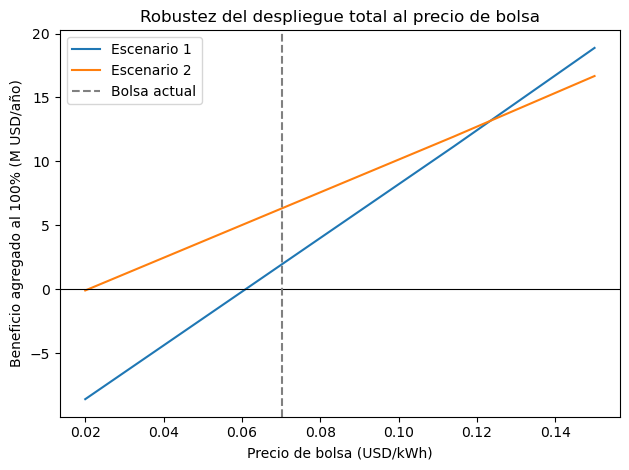

In [275]:
# ============================================================
# SECCIÓN 24 — Análisis 4: robustez del resultado al precio de bolsa
# Al fijar despliegue=100% las cantidades físicas son constantes;
# el beneficio es lineal en el precio de bolsa -> precio de quiebre exacto.
# ============================================================
def _beneficio_planta_bolsa(r, capex_turbina_cat, capex_fijo_dict, precio_bolsa):
    p, auto, exced = r['planta'], r['autoconsumo_kWh'], r['excedente_kWh']
    permuta = min(exced, auto); resto = exced - permuta
    rev_export = max(permuta*PRECIO_TRAMO_12_dict[p] + resto*precio_bolsa, exced*precio_bolsa)
    ingreso = auto*PRECIO_TRAMO_12_dict[p] + rev_export
    capex_var = (capex_turbina_cat[int(round(r['cap_turbina_kW']))]
                 + round(r['cap_biogas_kW']/TAMANO_UNIDAD_BIOGAS_KW)*CAPEX_UNIDAD_BIOGAS)
    return (ingreso - capex_var/PVAF - capex_var*PCT_OPERACION_ANUAL - costo_oport_dict[p]
            - capex_fijo_dict[p]/PVAF - capex_fijo_dict[p]*PCT_OPERACION_ANUAL)

def _precio_quiebre(f, lo=0.0, hi=0.30):
    if f(hi) < 0: return None          # ni a 0.30 es rentable
    if f(lo) > 0: return 0.0           # rentable aun con bolsa=0
    for _ in range(60):
        mid = (lo+hi)/2
        if f(mid) > 0: hi = mid
        else: lo = mid
    return (lo+hi)/2

def robustez_bolsa(df_plantas, capex_turbina_cat, capex_fijo_dict, nombre):
    sub = df_plantas[df_plantas['punto'] == df_plantas['punto'].max()]
    filas = []
    for _, r in sub.iterrows():
        f = lambda b, r=r: _beneficio_planta_bolsa(r, capex_turbina_cat, capex_fijo_dict, b)
        filas.append({'planta': r['planta'], 'beneficio_actual': f(PRECIO_BOLSA_PROMEDIO),
                      'bolsa_quiebre': _precio_quiebre(f)})
    agg = lambda b: sum(_beneficio_planta_bolsa(r, capex_turbina_cat, capex_fijo_dict, b)
                        for _, r in sub.iterrows())
    print(f"{nombre}: agregado quiebra a bolsa = {_precio_quiebre(agg):.4f}  (actual {PRECIO_BOLSA_PROMEDIO})")
    return pd.DataFrame(filas)

rob_e1 = robustez_bolsa(df_pareto_plantas,    CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict, "Esc.1")
rob_e2 = robustez_bolsa(df_pareto_plantas_e2, CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict, "Esc.2")
display(rob_e1.merge(rob_e2, on='planta', suffixes=('_e1','_e2')))

# --- Figura para el artículo: beneficio agregado vs precio de bolsa ---
import matplotlib.pyplot as plt
precios = np.arange(0.02, 0.151, 0.002)
for df_p, ct, fj, lab in [(df_pareto_plantas, CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict, 'Escenario 1'),
                          (df_pareto_plantas_e2, CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict, 'Escenario 2')]:
    sub = df_p[df_p['punto'] == df_p['punto'].max()]
    y = [sum(_beneficio_planta_bolsa(r, ct, fj, b) for _, r in sub.iterrows())/1e6 for b in precios]
    plt.plot(precios, y, label=lab)
plt.axhline(0, color='k', lw=0.8); plt.axvline(PRECIO_BOLSA_PROMEDIO, ls='--', color='gray', label='Bolsa actual')
plt.xlabel('Precio de bolsa (USD/kWh)'); plt.ylabel('Beneficio agregado al 100% (M USD/año)')
plt.title('Robustez del despliegue total al precio de bolsa'); plt.legend(); plt.tight_layout()
plt.savefig('robustez_bolsa.png', dpi=150); plt.show()